In [1]:
%load_ext autoreload
%autoreload 2

In [7]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, '/n/home12/binxuwang/Github/DiffusionAttnConsistency')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys, os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from circuit_toolkit.plot_utils import saveallforms
from core.fit_lib import fit_loglog, plot_loglog_fit

%matplotlib inline
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top']   = False
plt.rcParams['figure.dpi'] = 150

In [4]:
FIGDIR = "/n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/DiT_scaling_summary"
FIGDIR = "/n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_scaling_summary"

In [5]:
df = pd.read_pickle('/n/home12/binxuwang/Github/DiffusionAttnConsistency/outputs/parity_onset_table.pkl')
df = df.assign(model_str=df['model_arch'] + '-' + df['model_size'])
print(df.shape)
df.head(5)

(153, 30)


,exp_name,model_arch,model_size,G,N,D,n_layer,n_embd,n_head,lr,...,mem_onset_mem35,mem_onset_mem50,mem_onset_stat,stat_mem_thresh,innov_acc90_mem10,innov_acc90_mem20,innov_acc90_mem35,innov_acc90_mem50,innov_acc90_stat,model_str
0,DiT_B_parity_N4096_D36_G2_even,DiT,B,2,4096,36,12,768,12,0.0001,...,370336.0,444064.0,293536.0,0.115625,287644.0,317340.0,369564.0,443292.0,292764.0,DiT-B
1,DiT_B_parity_N4096_D36_G3_even,DiT,B,3,4096,36,12,768,12,0.0001,...,409248.0,492192.0,329376.0,0.100244,323864.0,352536.0,403736.0,486680.0,323864.0,DiT-B
2,DiT_B_parity_N4096_D36_G4_even,DiT,B,4,4096,36,12,768,12,0.0001,...,468640.0,629408.0,291488.0,0.100031,228688.0,282960.0,405840.0,566608.0,228688.0,DiT-B
3,DiT_B_parity_N4096_D36_G6_even,DiT,B,6,4096,36,12,768,12,0.0001,...,536224.0,706208.0,346784.0,0.100004,255312.0,331088.0,444752.0,614736.0,255312.0,DiT-B
4,DiT_B_parity_N4096_D36_G9_even,DiT,B,9,4096,36,12,768,12,0.0001,...,327328.0,430752.0,210592.0,0.100001,NaN,NaN,NaN,NaN,NaN,DiT-B


In [5]:
# let the rule onset time to be before the mem onset time
df["rule_onset_acc90_innov"] = df["rule_onset_acc90"]
for i in range(len(df)):
    if ~pd.isna(df.loc[i, "rule_onset_acc90"]) and ~pd.isna(df.loc[i, "mem_onset_stat"]):
        if df.loc[i, "rule_onset_acc90"] > df.loc[i, "mem_onset_stat"]:
            df.loc[i, "rule_onset_acc90_innov"] = pd.NA


In [7]:
# Quick summary: how many runs reached rule / mem onset
for (arch, size), sub in df.groupby(['model_arch', 'model_size']):
    r = sub['rule_onset_acc90'].notna().sum()
    m = sub['mem_onset_mem10'].notna().sum()
    print(f"{arch}-{size:4s}: {r}/{len(sub)} rule onset,  {m}/{len(sub)} mem onset")

DiT-B   : 4/8 rule onset,  8/8 mem onset
DiT-mini: 38/68 rule onset,  42/68 mem onset
DiT-nano: 3/8 rule onset,  1/8 mem onset
GPT-B   : 16/16 rule onset,  16/16 mem onset
GPT-mini: 39/45 rule onset,  43/45 mem onset
GPT-nano: 8/8 rule onset,  8/8 mem onset


### Scaling table

In [7]:
from core.fit_lib import fit_loglog, plot_loglog_fit
# sub = df.query("model_arch == 'DiT' and model_size == 'mini' and lr == 0.0001 and wd == 0.0")
# slope, intercept, r2, n, fn = fit_loglog(sub['N'],sub['mem_onset_stat'], )
# slope, intercept, r2, n = plot_loglog_fit(axes[1], sub['N'],sub['mem_onset_stat'], 
#     # x_min=1E3, x_max=1E4,   # optional: restrict fit range
#     label="DiT-mini", show_slope=True, show_r2=True,
#     color="gray", ls="--")
print("DiT-mini τ_mem vs N scaling")
for G in [2,3,4,6,9,12,18,36]:
    sub = df.query("model_arch == 'DiT' and model_size == 'mini' and lr == 0.0001 and wd == 0.0 and G == @G").copy()
    slope, intercept, r2, n, fn = fit_loglog(sub['N'],sub['mem_onset_stat'], )
    print(f"G={G}\t tau ~ {np.exp(intercept):.2g}N^{slope:.2f} R2={r2:.2f} n={n}")

DiT-mini τ_mem vs N scaling
G=2	 tau ~ 46N^1.08 R2=1.00 n=5
G=3	 tau ~ 36N^1.15 R2=0.99 n=4
G=4	 tau ~ 19N^1.25 R2=0.99 n=4
G=6	 tau ~ 19N^1.24 R2=0.98 n=5
G=9	 tau ~ 70N^1.05 R2=1.00 n=4
G=12	 tau ~ 24N^1.19 R2=0.99 n=4
G=18	 tau ~ 26N^1.17 R2=1.00 n=4
G=36	 tau ~ 19N^1.22 R2=1.00 n=4


In [13]:
df.query("model_arch == 'DiT' and model_size == 'B'")

,exp_name,model_arch,model_size,G,N,D,n_layer,n_embd,n_head,lr,...,mem_onset_mem50,mem_onset_stat,stat_mem_thresh,innov_acc90_mem10,innov_acc90_mem20,innov_acc90_mem35,innov_acc90_mem50,innov_acc90_stat,model_str,rule_onset_acc90_innov
0,DiT_B_parity_N4096_D36_G2_even,DiT,B,2,4096,36,12,768,12,0.0001,...,444064.0,293536.0,0.115625,287644.0,317340.0,369564.0,443292.0,292764.0,DiT-B,772.0
1,DiT_B_parity_N4096_D36_G3_even,DiT,B,3,4096,36,12,768,12,0.0001,...,492192.0,329376.0,0.100244,323864.0,352536.0,403736.0,486680.0,323864.0,DiT-B,5512.0
2,DiT_B_parity_N4096_D36_G4_even,DiT,B,4,4096,36,12,768,12,0.0001,...,629408.0,291488.0,0.100031,228688.0,282960.0,405840.0,566608.0,228688.0,DiT-B,62800.0
3,DiT_B_parity_N4096_D36_G6_even,DiT,B,6,4096,36,12,768,12,0.0001,...,706208.0,346784.0,0.100004,255312.0,331088.0,444752.0,614736.0,255312.0,DiT-B,91472.0
4,DiT_B_parity_N4096_D36_G9_even,DiT,B,9,4096,36,12,768,12,0.0001,...,430752.0,210592.0,0.100001,NaN,NaN,NaN,NaN,NaN,DiT-B,NaN
5,DiT_B_parity_N4096_D36_G12_even,DiT,B,12,4096,36,12,768,12,0.0001,...,574112.0,380576.0,0.100000,NaN,NaN,NaN,NaN,NaN,DiT-B,NaN
6,DiT_B_parity_N4096_D36_G18_even,DiT,B,18,4096,36,12,768,12,0.0001,...,412320.0,263840.0,0.100000,NaN,NaN,NaN,NaN,NaN,DiT-B,NaN
7,DiT_B_parity_N4096_D36_G36_even,DiT,B,36,4096,36,12,768,12,0.0001,...,413344.0,197280.0,0.100000,NaN,NaN,NaN,NaN,NaN,DiT-B,NaN


In [23]:
def print_scaling(sub_allG, name):
    print(f"{name} τ_mem vs N scaling")
    slope, intercept, r2, n, fn = fit_loglog(sub_allG['N'],sub_allG['mem_onset_stat'], )
    print(f"G=all\t tau ~ {np.exp(intercept):.2g} N^{slope:.2f} R2={r2:.2f} n={n}")
    for G in [2,3,4,6,9,12,18,36]:
        sub = sub_allG.query("G == @G").copy()
        slope, intercept, r2, n, fn = fit_loglog(sub['N'],sub['mem_onset_stat'], )
        print(f"G={G}\t tau ~ {np.exp(intercept):.2g} N^{slope:.2f} R2={r2:.2f} n={n}")

for arch in ['DiT', 'GPT']:
    for size in ['B', 'mini', 'nano']:
        wd = 0.01 if arch == 'GPT' else 0.00
        sub_allG = df.query(f"model_arch == '{arch}' and model_size == '{size}' and lr == 0.0001 and wd == @wd").copy()
        print_scaling(sub_allG, f"{arch}-{size}")


DiT-B τ_mem vs N scaling
G=all	 tau ~ 5.3e+02 N^0.75 R2=0.00 n=8
G=2	 tau ~ nan N^nan R2=nan n=1
G=3	 tau ~ nan N^nan R2=nan n=1
G=4	 tau ~ nan N^nan R2=nan n=1
G=6	 tau ~ nan N^nan R2=nan n=1
G=9	 tau ~ nan N^nan R2=nan n=1
G=12	 tau ~ nan N^nan R2=nan n=1
G=18	 tau ~ nan N^nan R2=nan n=1
G=36	 tau ~ nan N^nan R2=nan n=1
DiT-mini τ_mem vs N scaling
G=all	 tau ~ 35 N^1.14 R2=0.94 n=34
G=2	 tau ~ 46 N^1.08 R2=1.00 n=5
G=3	 tau ~ 36 N^1.15 R2=0.99 n=4
G=4	 tau ~ 19 N^1.25 R2=0.99 n=4
G=6	 tau ~ 19 N^1.24 R2=0.98 n=5
G=9	 tau ~ 70 N^1.05 R2=1.00 n=4
G=12	 tau ~ 24 N^1.19 R2=0.99 n=4
G=18	 tau ~ 26 N^1.17 R2=1.00 n=4
G=36	 tau ~ 19 N^1.22 R2=1.00 n=4
DiT-nano τ_mem vs N scaling
G=all	 tau ~ nan N^nan R2=nan n=1
G=2	 tau ~ nan N^nan R2=nan n=1
G=3	 tau ~ nan N^nan R2=nan n=0
G=4	 tau ~ nan N^nan R2=nan n=0
G=6	 tau ~ nan N^nan R2=nan n=0
G=9	 tau ~ nan N^nan R2=nan n=0
G=12	 tau ~ nan N^nan R2=nan n=0
G=18	 tau ~ nan N^nan R2=nan n=0
G=36	 tau ~ nan N^nan R2=nan n=0
GPT-B τ_mem vs N scaling

/n/home12/binxuwang/Github/DiffusionAttnConsistency/core/fit_lib.py:51: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(lx, ly, 1)
/n/home12/binxuwang/Github/DiffusionAttnConsistency/core/fit_lib.py:51: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(lx, ly, 1)


In [24]:
def print_scaling(sub_allG, name):
    print(f"{name} τ_mem vs N scaling")
    slope, intercept, r2, n, fn = fit_loglog(sub_allG['N'],sub_allG['mem_onset_stat'], )
    print(f"G=all\t tau ~ {np.exp(intercept):.2g} N^{slope:.2f} R2={r2:.2f} n={n}")
    for G in [2,3,4,6,9,12,18,36]:
        sub = sub_allG.query("G == @G").copy()
        slope, intercept, r2, n, fn = fit_loglog(sub['N'],sub['mem_onset_stat'], )
        print(f"G={G}\t tau ~ {np.exp(intercept):.2g} N^{slope:.2f} R2={r2:.2f} n={n}")

for arch, size in [
                    # ('DiT', 'B'), 
                   ('DiT', 'mini'), 
                #    ('DiT', 'nano'), 
                   ('GPT', 'B'), 
                   ('GPT', 'mini'), 
                #    ('GPT', 'nano')
                ]: 
        wd = 0.01 if arch == 'GPT' else 0.00
        sub_allG = df.query(f"model_arch == '{arch}' and model_size == '{size}' and lr == 0.0001 and wd == @wd").copy()
        print_scaling(sub_allG, f"{arch}-{size}")


DiT-mini τ_mem vs N scaling
G=all	 tau ~ 35 N^1.14 R2=0.94 n=34
G=2	 tau ~ 46 N^1.08 R2=1.00 n=5
G=3	 tau ~ 36 N^1.15 R2=0.99 n=4
G=4	 tau ~ 19 N^1.25 R2=0.99 n=4
G=6	 tau ~ 19 N^1.24 R2=0.98 n=5
G=9	 tau ~ 70 N^1.05 R2=1.00 n=4
G=12	 tau ~ 24 N^1.19 R2=0.99 n=4
G=18	 tau ~ 26 N^1.17 R2=1.00 n=4
G=36	 tau ~ 19 N^1.22 R2=1.00 n=4
GPT-B τ_mem vs N scaling
G=all	 tau ~ 0.53 N^1.06 R2=0.97 n=16
G=2	 tau ~ 0.093 N^1.27 R2=1.00 n=2
G=3	 tau ~ 0.37 N^1.10 R2=1.00 n=2
G=4	 tau ~ 0.61 N^1.04 R2=1.00 n=2
G=6	 tau ~ 0.11 N^1.25 R2=1.00 n=2
G=9	 tau ~ 0.86 N^1.00 R2=1.00 n=2
G=12	 tau ~ 1.7 N^0.93 R2=1.00 n=2
G=18	 tau ~ 1.4 N^0.94 R2=1.00 n=2
G=36	 tau ~ 1.4 N^0.96 R2=1.00 n=2
GPT-mini τ_mem vs N scaling
G=all	 tau ~ 2.1 N^0.97 R2=0.94 n=34
G=2	 tau ~ 0.63 N^1.10 R2=0.99 n=4
G=3	 tau ~ 1.1 N^1.02 R2=0.99 n=4
G=4	 tau ~ 2.2 N^0.96 R2=0.99 n=4
G=6	 tau ~ 11 N^0.81 R2=0.83 n=6
G=9	 tau ~ 1 N^1.05 R2=1.00 n=4
G=12	 tau ~ 0.7 N^1.09 R2=1.00 n=4
G=18	 tau ~ 1.4 N^1.01 R2=1.00 n=4
G=36	 tau ~ 2.2 N^0.97

In [22]:
print("GPT-B τ_mem vs N scaling")
sub_allG = df.query("model_arch == 'GPT' and model_size == 'B' and lr == 0.0001 and wd == 0.01").copy()
slope, intercept, r2, n, fn = fit_loglog(sub_allG['N'],sub_allG['mem_onset_stat'], )
print(f"G=all\t tau ~ {np.exp(intercept):.2g} N^{slope:.2f} R2={r2:.2f} n={n}")
for G in [2,3,4,6,9,12,18,36]:
    sub = sub_allG.query("G == @G").copy()
    slope, intercept, r2, n, fn = fit_loglog(sub['N'],sub['mem_onset_stat'], )
    print(f"G={G}\t tau ~ {np.exp(intercept):.2g} N^{slope:.2f} R2={r2:.2f} n={n}")

GPT-B τ_mem vs N scaling
G=all	 tau ~ 0.53 N^1.06 R2=0.97 n=16
G=2	 tau ~ 0.093 N^1.27 R2=1.00 n=2
G=3	 tau ~ 0.37 N^1.10 R2=1.00 n=2
G=4	 tau ~ 0.61 N^1.04 R2=1.00 n=2
G=6	 tau ~ 0.11 N^1.25 R2=1.00 n=2
G=9	 tau ~ 0.86 N^1.00 R2=1.00 n=2
G=12	 tau ~ 1.7 N^0.93 R2=1.00 n=2
G=18	 tau ~ 1.4 N^0.94 R2=1.00 n=2
G=36	 tau ~ 1.4 N^0.96 R2=1.00 n=2


In [21]:
print("DiT-mini τ_mem vs N scaling")
sub_allG = df.query("model_arch == 'GPT' and model_size == 'mini' and lr == 0.0001 and wd == 0.01").copy()
slope, intercept, r2, n, fn = fit_loglog(sub_allG['N'],sub_allG['mem_onset_stat'], )
print(f"G=all\t tau ~ {np.exp(intercept):.2g} N^{slope:.2f} R2={r2:.2f} n={n}")
for G in [2,3,4,6,9,12,18,36]:
    sub = sub_allG.query("G == @G").copy()
    slope, intercept, r2, n, fn = fit_loglog(sub['N'],sub['mem_onset_stat'], )
    print(f"G={G}\t tau ~ {np.exp(intercept):.2g} N^{slope:.2f} R2={r2:.2f} n={n}")

DiT-mini τ_mem vs N scaling
G=all	 tau ~ 2.1 N^0.97 R2=0.94 n=34
G=2	 tau ~ 0.63 N^1.10 R2=0.99 n=4
G=3	 tau ~ 1.1 N^1.02 R2=0.99 n=4
G=4	 tau ~ 2.2 N^0.96 R2=0.99 n=4
G=6	 tau ~ 11 N^0.81 R2=0.83 n=6
G=9	 tau ~ 1 N^1.05 R2=1.00 n=4
G=12	 tau ~ 0.7 N^1.09 R2=1.00 n=4
G=18	 tau ~ 1.4 N^1.01 R2=1.00 n=4
G=36	 tau ~ 2.2 N^0.97 R2=0.98 n=4


In [ ]:
print("DiT-mini τ_mem vs N scaling")
sub_allG = df.query("model_arch == 'GPT' and model_size == 'mini' and lr == 0.0001 and wd == 0.01").copy()
slope, intercept, r2, n, fn = fit_loglog(sub_allG['N'],sub_allG['mem_onset_stat'], )
print(f"G=all\t tau ~ {np.exp(intercept):.2g}N^{slope:.2f} R2={r2:.2f} n={n}")
for G in [2,3,4,6,9,12,18,36]:
    sub = sub_allG.query("G == @G").copy()
    slope, intercept, r2, n, fn = fit_loglog(sub['N'],sub['mem_onset_stat'], )
    print(f"G={G}\t tau ~ {np.exp(intercept):.2g}N^{slope:.2f} R2={r2:.2f} n={n}")

In [ ]:
print("DiT-B τ_mem vs N scaling")
for G in [2,3,4,6,9,12,18,36]:
    sub = df.query("model_arch == 'GPT' and model_size == 'B' and lr == 0.0001 and wd == 0.01 and G == @G").copy()
    slope, intercept, r2, n, fn = fit_loglog(sub['N'],sub['mem_onset_stat'], )
    print(f"G={G}\t tau ~ {np.exp(intercept):.2g}N^{slope:.2f} R2={r2:.2f} n={n}")

DiT-nano τ_mem vs N scaling
G=2	 tau ~ nanN^nan R2=nan n=1
G=3	 tau ~ nanN^nan R2=nan n=1
G=4	 tau ~ nanN^nan R2=nan n=1
G=6	 tau ~ nanN^nan R2=nan n=1
G=9	 tau ~ nanN^nan R2=nan n=1
G=12	 tau ~ nanN^nan R2=nan n=1
G=18	 tau ~ nanN^nan R2=nan n=1
G=36	 tau ~ nanN^nan R2=nan n=1


/tmp/ipykernel_1045128/2881926598.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=sub_allG, x='N', y='mem_onset_stat', style='G', ax=axes, palette="turbo", markers=True, alpha=0.5)
/tmp/ipykernel_1045128/2881926598.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=sub_allG, x='N', y='mem_onset_stat', style='G', ax=axes, palette="turbo", markers=True, alpha=0.5)
/tmp/ipykernel_1045128/2881926598.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=sub_allG, x='N', y='mem_onset_stat', style='G', ax=axes, palette="turbo", markers=True, alpha=0.5)


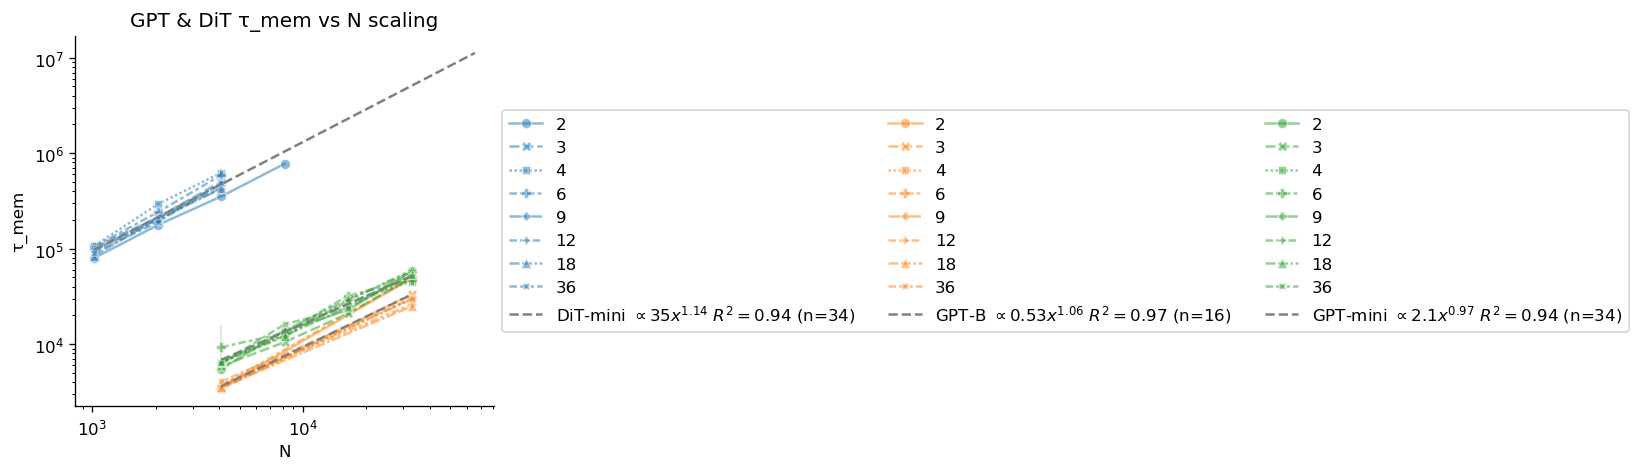

In [35]:
import seaborn as sns
fig, axes = plt.subplots(1, 1, figsize=(4.5, 4), dpi=120)
for arch, size in [
                   ('DiT', 'mini'), 
                   ('GPT', 'B'), 
                   ('GPT', 'mini'), 
                ]: 
        wd = 0.01 if arch == 'GPT' else 0.00
        sub_allG = df.query(f"model_arch == '{arch}' and model_size == '{size}' and lr == 0.0001 and wd == @wd").copy()
        sns.lineplot(data=sub_allG, x='N', y='mem_onset_stat', style='G', ax=axes, palette="turbo", markers=True, alpha=0.5)
        slope, intercept, r2, n = plot_loglog_fit(axes, sub_allG['N'],sub_allG['mem_onset_stat'], 
                    # x_min=1E3, x_max=1E4,   # optional: restrict fit range
                    label=f"{arch}-{size}", show_slope=True, show_r2=True,
                    color="gray", ls="--")
        plt.xscale('log')
        plt.yscale('log')
# plt.xticks(sorted(sub['N'].unique()))
plt.legend(ncol=3, loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel('N')
plt.ylabel('τ_mem')
plt.title(f'GPT & DiT τ_mem vs N scaling')
# plt.title(f'{arch}-{size} τ_mem vs N')
plt.show()

/tmp/ipykernel_1045128/1649929160.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=sub_allG, x='N', y='mem_onset_stat', style='G', ax=axes, palette="turbo", markers=True, alpha=0.5, legend=False)
/tmp/ipykernel_1045128/1649929160.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=sub_allG, x='N', y='mem_onset_stat', style='G', ax=axes, palette="turbo", markers=True, alpha=0.5, legend=False)
/tmp/ipykernel_1045128/1649929160.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=sub_allG, x='N', y='mem_onset_stat', style='G', ax=axes, palette="turbo", markers=True, alpha=0.5, legend=False)


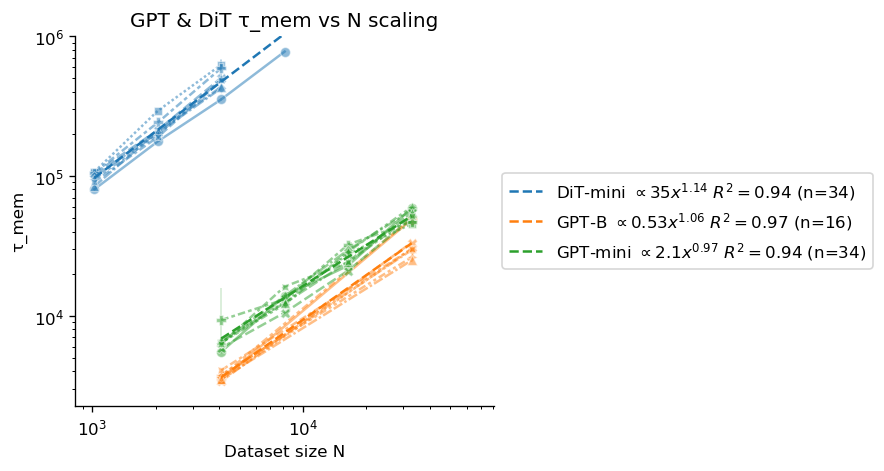

In [39]:
import seaborn as sns
fig, axes = plt.subplots(1, 1, figsize=(4.5, 4), dpi=120)
for arch, size, color in [
                   ('DiT', 'mini', 'tab:blue'), 
                   ('GPT', 'B', 'tab:orange'), 
                   ('GPT', 'mini', 'tab:green'), 
                ]: 
        wd = 0.01 if arch == 'GPT' else 0.00
        sub_allG = df.query(f"model_arch == '{arch}' and model_size == '{size}' and lr == 0.0001 and wd == @wd").copy()
        sns.lineplot(data=sub_allG, x='N', y='mem_onset_stat', style='G', ax=axes, palette="turbo", markers=True, alpha=0.5, legend=False)
        slope, intercept, r2, n = plot_loglog_fit(axes, sub_allG['N'],sub_allG['mem_onset_stat'], 
                    # x_min=1E3, x_max=1E4,   # optional: restrict fit range
                    label=f"{arch}-{size}", show_slope=True, show_r2=True,
                    color=color, ls="--")
        plt.xscale('log')
        plt.yscale('log')
# plt.xticks(sorted(sub['N'].unique()))
plt.ylim(None, 1E6)
plt.legend(ncol=1, loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Dataset size N')
plt.ylabel('τ_mem')
plt.title(f'GPT & DiT τ_mem vs N scaling')
# plt.title(f'{arch}-{size} τ_mem vs N')
saveallforms(FIGDIR, f"GPT_DiT_all_arch_size_tau_mem_vs_N_scaling", figh=fig)
plt.show()

### GPT scaling

In [10]:
!mkdir {FIGDIR}

/tmp/ipykernel_1846103/1889902085.py:79: UserWarning: 
The dashes list has fewer values (1) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


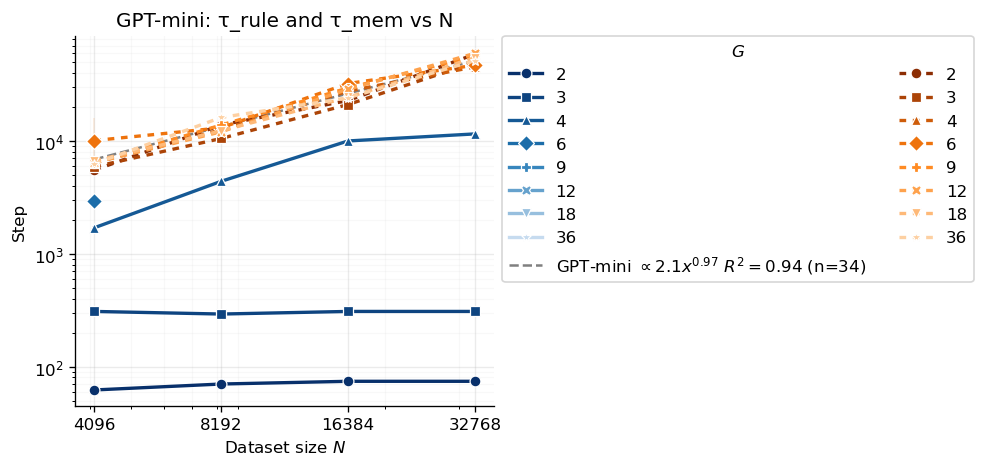

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from core.fit_lib import fit_loglog, plot_loglog_fit

# ── Tau rule / tau mem vs N, color family = clock, shade = G ──────────────

sub = df.query("lr == 0.0001").copy()
sub = sub.query("model_arch == 'GPT' and wd == 0.01 and model_size == 'mini'").copy()

# Optional main-figure simplification
# G_KEEP = [2, 3, 6, 12, 36]
# sub = sub.query("G in @G_KEEP").copy()

G_order = sorted(sub["G"].dropna().unique())
N_ticks = sorted(sub["N"].dropna().unique())

G_MARKERS = {
    2: "o",
    3: "s",
    4: "^",
    6: "D",
    9: "P",
    12: "X",
    18: "v",
    36: "*",
}

# Blue family for τ_rule, orange family for τ_mem.
# The first color is light, the last is darker.
# rule_palette = sns.light_palette("#1f77b4", n_colors=len(G_order) + 1, reverse=True)[:-1]
# mem_palette  = sns.light_palette("#ff7f0e", n_colors=len(G_order) + 1, reverse=True)[:-1]

# RULE_G_COLORS = dict(zip(G_order, rule_palette))
# MEM_G_COLORS  = dict(zip(G_order, mem_palette))
rule_palette = sns.blend_palette(
    ["#c6dbef", "#1f77b4", "#08306b"],  # light blue → panel-B blue → dark navy
    n_colors=len(G_order)
)

mem_palette = sns.blend_palette(
    ["#fdd0a2", "#ff7f0e", "#8c2d04"],  # light orange → panel-B orange → dark burnt orange
    n_colors=len(G_order)
)

RULE_G_COLORS = dict(zip(G_order, reversed(rule_palette)))
MEM_G_COLORS  = dict(zip(G_order, reversed(mem_palette)))

fig, ax = plt.subplots(1, 1, figsize=(4.5, 4), dpi=120)

# τ_rule: blue family, solid
sns.lineplot(
    data=sub,
    x="N",
    y="rule_onset_acc90_innov",
    hue="G",
    hue_order=G_order,
    style="G",
    style_order=G_order,
    palette=RULE_G_COLORS,
    markers=G_MARKERS,
    dashes=False,
    estimator="mean",
    errorbar=("ci", 95),
    err_style="band",
    err_kws={"alpha": 0.14},
    linewidth=2.0,
    markersize=6.5,
    ax=ax,
    legend=True,
)

slope, intercept, r2, n = plot_loglog_fit(ax, sub['N'],sub['mem_onset_stat'], 
    # x_min=1E3, x_max=1E4,   # optional: restrict fit range
    label="GPT-mini", show_slope=True, show_r2=True,
    color="gray", ls="--")
# τ_mem: orange family, dashed
sns.lineplot(
    data=sub,
    x="N",
    y="mem_onset_stat",
    hue="G",
    hue_order=G_order,
    style="G",
    style_order=G_order,
    palette=MEM_G_COLORS,
    markers=G_MARKERS,
    dashes=[(2,2),],
    estimator="mean",
    errorbar=("ci", 95),
    err_style="band",
    err_kws={"alpha": 0.14},
    linewidth=2.0,
    markersize=6.5,
    ax=ax,
    legend=True,
)

ax.set_yscale("log")
ax.set_xscale("log")

ax.set_xticks(N_ticks)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_xaxis().set_minor_formatter(mticker.NullFormatter())

ax.set_xlabel("Dataset size $N$")
ax.set_ylabel("Step")
ax.set_title(r"GPT-mini: τ_rule and τ_mem vs N")
# ax.set_ylim(550, 1050000)
ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", alpha=0.08)

# ── Legends ───────────────────────────────────────────────────────────────
# clock_handles = [
#     Line2D(
#         [0], [0],
#         color="#1f77b4",
#         linestyle="-",
#         marker="o",
#         linewidth=2.2,
#         markersize=6,
#         label=r"$\tau_{\mathrm{rule}}$",
#     ),
#     Line2D(
#         [0], [0],
#         color="#ff7f0e",
#         linestyle="--",
#         marker="o",
#         linewidth=2.2,
#         markersize=6,
#         label=r"$\tau_{\mathrm{mem}}$",
#     ),
# ]

# # Use neutral markers for G legend if you want shape-only legend:
# g_handles = [
#     Line2D(
#         [0], [0],
#         color="0.25",
#         linestyle="None",
#         marker=G_MARKERS[g],
#         markersize=7,
#         label=f"{g}",
#     )
#     for g in G_order
# ]

# leg1 = ax.legend(
#     handles=clock_handles,
#     title="Clock",
#     loc="upper left",
#     frameon=True,
# )
# ax.add_artist(leg1)
ax.set_ylim(45, 85000)

ax.legend(
    # handles=g_handles,
    title="$G$",
    ncol=2,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0.,
    frameon=True,
)
saveallforms(FIGDIR, "GPT_tau_rule_mem_vs_N_mini_sep_color_hue_lineplots", figh=fig)
# plt.tight_layout()
plt.show()

/tmp/ipykernel_1846103/1038909914.py:42: UserWarning: The dashes list has more values (5) than needed (3), which may not be intended.
  sns.lineplot(


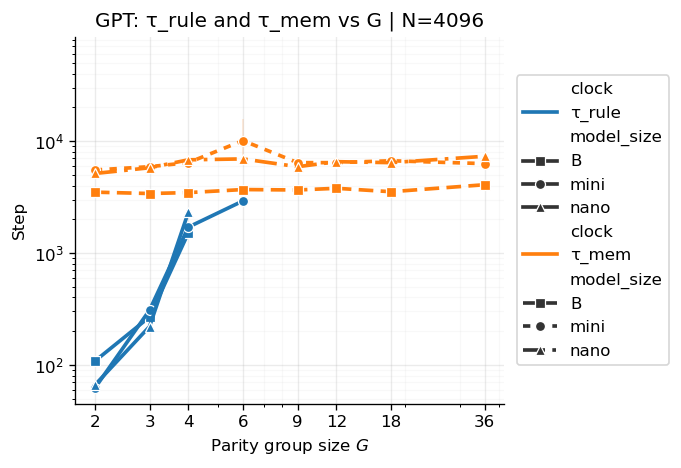

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Rule/mem onset vs G, by model size ────────────────────────────────────

CLOCK_COLORS = {
    "τ_rule": "#1f77b4",   # matches Panel B rule acc blue
    "τ_mem":  "#ff7f0e",   # matches Panel B mem ratio orange
    # alternative softer orange: "#E76F51"
}

MARKERS = {
    "nano": "^",
    "mini": "o",
    "B": "s",
}
dashes = [(4, 2), (2, 2), (6, 2, 1, 2), (3, 1, 1, 1), (5, 3, 1, 3)][:]

sub = df.query("model_arch == 'GPT' and wd == 0.01 and N == 4096 and lr == 0.0001").copy()

fig, ax = plt.subplots(1, 1, figsize=(4.4, 4), dpi=120)

# τ_rule: solid blue
sub_rule = sub.copy()
sub_rule["clock"] = "τ_rule"

sns.lineplot(
    data=sub_rule,
    x="G", y="rule_onset_acc90_innov", hue="clock", style="model_size",
    palette=CLOCK_COLORS, markers=MARKERS, dashes=False,
    estimator="mean", errorbar=("ci", 95), err_style="band", err_kws={"alpha": 0.18},
    linewidth=2.2,
    ax=ax,
    legend=True,
)

# τ_mem: dashed orange
sub_mem = sub.copy()
sub_mem["clock"] = "τ_mem"

sns.lineplot(
    data=sub_mem,
    x="G", y="mem_onset_stat", hue="clock", style="model_size",
    palette=CLOCK_COLORS, markers=MARKERS, dashes=dashes,
    estimator="mean", errorbar=("ci", 95), err_style="band", err_kws={"alpha": 0.18},
    linewidth=2.2,
    ax=ax,
    legend=True,
)

ax.set_yscale("log")
ax.set_xscale("log")

ax.set_xticks(sorted(sub["G"].unique()))
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_xaxis().set_minor_formatter(mticker.NullFormatter())

ax.set_xlabel("Parity group size $G$")
ax.set_ylabel("Step")
ax.set_title("GPT: τ_rule and τ_mem vs G | N=4096")
ax.set_ylim(45, 85000)
ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", alpha=0.08)

plt.tight_layout()
# Move the legend right outside the plot area
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=True)
saveallforms(FIGDIR, "GPT_tau_rule_mem_vs_G_4096_sep_color_lineplots", figh=fig)
plt.show()

In [17]:
ax.get_ylim()

(np.float64(46.98484650721281), np.float64(20965.397851172736))

In [15]:
FIGDIR = "/n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/DiT_scaling_summary"
# FIGDIR = "/n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_scaling_summary"
df = pd.read_pickle('/n/home12/binxuwang/Github/DiffusionAttnConsistency/outputs/parity_onset_table_v2.pkl')
df = df.assign(model_str=df['model_arch'] + '-' + df['model_size'])
print(df.shape)
df.head(5)

(161, 33)


,exp_name,model_arch,model_size,G,N,D,n_layer,n_embd,n_head,lr,...,stat_mem_thresh,innov_acc90_mem10,innov_acc90_mem20,innov_acc90_mem35,innov_acc90_mem50,innov_acc90_stat,novel_onset_01,novel_onset_05,novel_onset_09,model_str
0,DiT_B_parity_N4096_D36_G2_even,DiT,B,2,4096,36,12,768,12,0.0001,...,0.115625,287644.0,317340.0,369564.0,443292.0,292764.0,308.0,372.0,996.0,DiT-B
1,DiT_B_parity_N4096_D36_G3_even,DiT,B,3,4096,36,12,768,12,0.0001,...,0.100244,323864.0,352536.0,403736.0,486680.0,323864.0,5384.0,5384.0,5512.0,DiT-B
2,DiT_B_parity_N4096_D36_G4_even,DiT,B,4,4096,36,12,768,12,0.0001,...,0.100031,228688.0,282960.0,405840.0,566608.0,228688.0,62288.0,62800.0,62800.0,DiT-B
3,DiT_B_parity_N4096_D36_G6_even,DiT,B,6,4096,36,12,768,12,0.0001,...,0.100004,255312.0,331088.0,444752.0,614736.0,255312.0,91472.0,91472.0,91472.0,DiT-B
4,DiT_B_parity_N4096_D36_G9_even,DiT,B,9,4096,36,12,768,12,0.0001,...,0.100001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DiT-B


In [17]:
sub.query("N==32768")

,exp_name,model_arch,model_size,G,N,D,n_layer,n_embd,n_head,lr,...,innov_acc90_mem10,innov_acc90_mem20,innov_acc90_mem35,innov_acc90_mem50,innov_acc90_stat,novel_onset_01,novel_onset_05,novel_onset_09,model_str,rule_onset_acc90_innov
28,DiT_mini_parity_N32768_D36_G4_even_rep2,DiT,mini,4,32768,36,6,384,6,0.0001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DiT-mini,NaN
29,DiT_mini_parity_N32768_D36_G4_even_rep3,DiT,mini,4,32768,36,6,384,6,0.0001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DiT-mini,NaN
51,DiT_mini_parity_N32768_D36_G6_even_rep2,DiT,mini,6,32768,36,6,384,6,0.0001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DiT-mini,NaN
52,DiT_mini_parity_N32768_D36_G6_even_rep3,DiT,mini,6,32768,36,6,384,6,0.0001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DiT-mini,NaN


In [16]:
# let the rule onset time to be before the mem onset time
df["rule_onset_acc90_innov"] = df["rule_onset_acc90"]
for i in range(len(df)):
    if ~pd.isna(df.loc[i, "rule_onset_acc90"]) and ~pd.isna(df.loc[i, "mem_onset_stat"]):
        if df.loc[i, "rule_onset_acc90"] > df.loc[i, "mem_onset_stat"]:
            df.loc[i, "rule_onset_acc90_innov"] = pd.NA


/tmp/ipykernel_3632976/838672320.py:78: UserWarning: 
The dashes list has fewer values (1) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


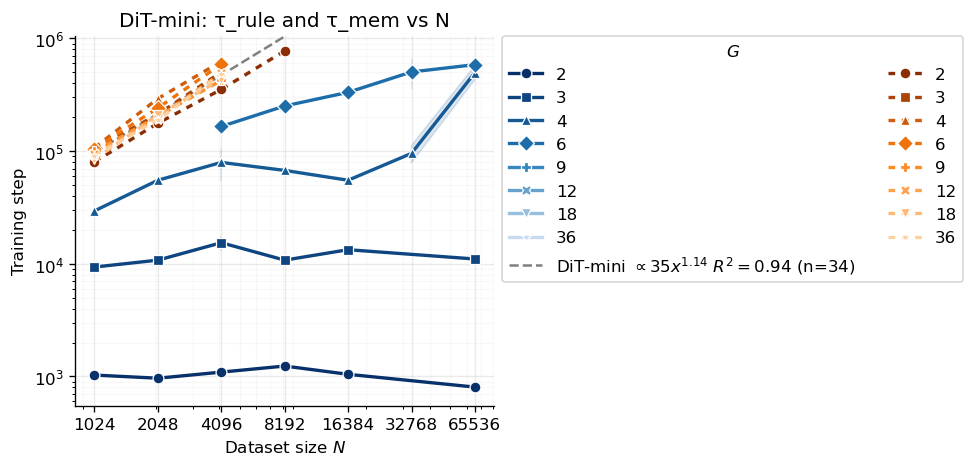

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

# ── Tau rule / tau mem vs N, color family = clock, shade = G ──────────────

sub = df.query("lr == 0.0001").copy()
sub = sub.query("model_arch == 'DiT' and wd == 0.00 and model_size == 'mini'").copy()

# Optional main-figure simplification
# G_KEEP = [2, 3, 6, 12, 36]
# sub = sub.query("G in @G_KEEP").copy()

G_order = sorted(sub["G"].dropna().unique())
N_ticks = sorted(sub["N"].dropna().unique())

G_MARKERS = {
    2: "o",
    3: "s",
    4: "^",
    6: "D",
    9: "P",
    12: "X",
    18: "v",
    36: "*",
}

# Blue family for τ_rule, orange family for τ_mem.
# The first color is light, the last is darker.
# rule_palette = sns.light_palette("#1f77b4", n_colors=len(G_order) + 1, reverse=True)[:-1]
# mem_palette  = sns.light_palette("#ff7f0e", n_colors=len(G_order) + 1, reverse=True)[:-1]

# RULE_G_COLORS = dict(zip(G_order, rule_palette))
# MEM_G_COLORS  = dict(zip(G_order, mem_palette))
rule_palette = sns.blend_palette(
    ["#c6dbef", "#1f77b4", "#08306b"],  # light blue → panel-B blue → dark navy
    n_colors=len(G_order)
)

mem_palette = sns.blend_palette(
    ["#fdd0a2", "#ff7f0e", "#8c2d04"],  # light orange → panel-B orange → dark burnt orange
    n_colors=len(G_order)
)

RULE_G_COLORS = dict(zip(G_order, reversed(rule_palette)))
MEM_G_COLORS  = dict(zip(G_order, reversed(mem_palette)))

fig, ax = plt.subplots(1, 1, figsize=(4.5, 4), dpi=120)

# τ_rule: blue family, solid
sns.lineplot(
    data=sub,
    x="N",
    y="rule_onset_acc90_innov",
    hue="G",
    hue_order=G_order,
    style="G",
    style_order=G_order,
    palette=RULE_G_COLORS,
    markers=G_MARKERS,
    dashes=False,
    estimator="mean",
    errorbar=("ci", 95),
    err_style="band",
    err_kws={"alpha": 0.14},
    linewidth=2.0,
    markersize=6.5,
    ax=ax,
    legend=True,
)

slope, intercept, r2, n = plot_loglog_fit(ax, sub['N'],sub['mem_onset_stat'], 
    # x_min=1E3, x_max=1E4,   # optional: restrict fit range
    label="DiT-mini", show_slope=True, show_r2=True,
    color="gray", ls="--")
# τ_mem: orange family, dashed
sns.lineplot(
    data=sub,
    x="N",
    y="mem_onset_stat",
    hue="G",
    hue_order=G_order,
    style="G",
    style_order=G_order,
    palette=MEM_G_COLORS,
    markers=G_MARKERS,
    dashes=[(2,2),],
    estimator="mean",
    errorbar=("ci", 95),
    err_style="band",
    err_kws={"alpha": 0.14},
    linewidth=2.0,
    markersize=6.5,
    ax=ax,
    legend=True,
)


# slope, intercept, r2, n = plot_loglog_fit(axes[1], sub['N'],sub['mem_onset_stat'], 
#     # x_min=1E3, x_max=1E4,   # optional: restrict fit range
#     label="DiT-mini", show_slope=True, show_r2=True,
#     color="gray", ls="--")
# plt.legend()

ax.set_yscale("log")
ax.set_xscale("log")

ax.set_xticks(N_ticks)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_xaxis().set_minor_formatter(mticker.NullFormatter())

ax.set_xlabel("Dataset size $N$")
ax.set_ylabel("Training step")
ax.set_title(r"DiT-mini: τ_rule and τ_mem vs N")
ax.set_ylim(550, 1050000)
ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", alpha=0.08)

# ── Legends ───────────────────────────────────────────────────────────────
# clock_handles = [
#     Line2D(
#         [0], [0],
#         color="#1f77b4",
#         linestyle="-",
#         marker="o",
#         linewidth=2.2,
#         markersize=6,
#         label=r"$\tau_{\mathrm{rule}}$",
#     ),
#     Line2D(
#         [0], [0],
#         color="#ff7f0e",
#         linestyle="--",
#         marker="o",
#         linewidth=2.2,
#         markersize=6,
#         label=r"$\tau_{\mathrm{mem}}$",
#     ),
# ]

# # Use neutral markers for G legend if you want shape-only legend:
# g_handles = [
#     Line2D(
#         [0], [0],
#         color="0.25",
#         linestyle="None",
#         marker=G_MARKERS[g],
#         markersize=7,
#         label=f"{g}",
#     )
#     for g in G_order
# ]

# leg1 = ax.legend(
#     handles=clock_handles,
#     title="Clock",
#     loc="upper left",
#     frameon=True,
# )
# ax.add_artist(leg1)

ax.legend(
    # handles=g_handles,
    title="$G$",
    ncol=2,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0.,
    frameon=True,
)
saveallforms(FIGDIR, "DiT_tau_rule_mem_vs_N_mini_sep_color_hue_lineplots_v2update", figh=fig)
# plt.tight_layout()
plt.show()

In [14]:

from core.onset_lib import load_eval_timeseries, load_eval_dataframe
SAVEROOT = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"

expname = "DiT_mini_parity_N32768_D36_G4_even_rep2"
eval_traj_df = load_eval_dataframe(expname, SAVEROOT)

# Compute EMA for each plotted column for smoother trends
# ema_span = 5  # adjust for smoothness (larger=more smoothing)
dfa = eval_traj_df.copy()
for col in ["valid_acc", "mem_ratio", "nan_ratio_1e1"]:
    dfa[f"{col}_ema"] = dfa[col].ewm(alpha=0.1, adjust=False).mean() # span=ema_span

fig, ax = plt.subplots(1, 1, figsize=(4.8, 4), dpi=130, sharey=True)

# --- Original traces: thin, low alpha ---
sns.lineplot(data=eval_traj_df, x="step", y="valid_acc",   ax=ax, label="valid_acc",   color="C0", alpha=0.30, lw=1, zorder=1)
sns.lineplot(data=eval_traj_df, x="step", y="mem_ratio",   ax=ax, label="mem_ratio",   color="C1", alpha=0.30, lw=1, linestyle='--', zorder=1)
sns.lineplot(data=eval_traj_df, x="step", y="nan_ratio_1e1", ax=ax, label="nan_ratio", color="C2", alpha=0.30, lw=1, zorder=1)
# --- EMA traces: thicker, more opaque ---
sns.lineplot(data=dfa, x="step", y="valid_acc_ema",   ax=ax, label="valid_acc (EMA)",   color="C0", lw=2., zorder=2)
sns.lineplot(data=dfa, x="step", y="mem_ratio_ema",   ax=ax, label="mem_ratio (EMA)",   color="C1", lw=2., linestyle='--', zorder=2)
sns.lineplot(data=dfa, x="step", y="nan_ratio_1e1_ema", ax=ax, label="nan_ratio (EMA)", color="C2", lw=2., zorder=2)
# optionally add bitgroup_mem as another trace, following the above style
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=9, title_fontsize=10, frameon=True)
plt.axhline(y=0.1, color='black', linestyle='-.', alpha=0.3)
plt.axhline(y=0.9, color='black', linestyle='--', alpha=0.3)
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Step')
ax.set_ylabel('Valid accuracy')
ax.set_title(f'{expname}\nDiT-mini valid accuracy\n(raw: faded/thin, EMA: solid/thick)')
# saveallforms(FIGDIR, f"{expname}_valid_mem_eval_curve_logscale", figh=fig)
plt.show()

AttributeError: 'NoneType' object has no attribute 'copy'

### Effect on Group size G

/tmp/ipykernel_793871/3482993367.py:32: UserWarning: The dashes list has more values (5) than needed (3), which may not be intended.
  sns.lineplot(


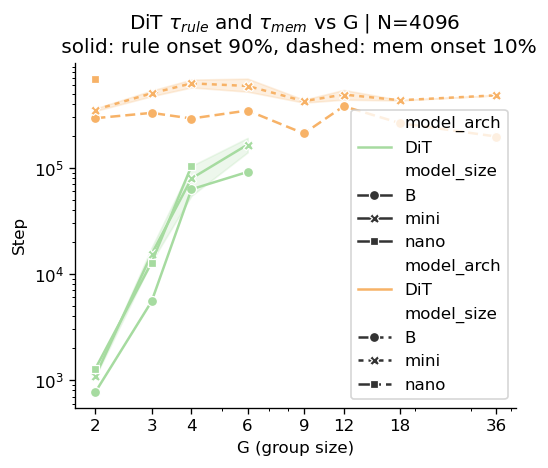

In [40]:
import seaborn as sns
# ── Rule onset vs G, by arch/size ─────────────────────────────────────────
RULE_COLORS = {
    ('DiT', 'nano'): '#5aae61',
    ('DiT', 'mini'): '#1b7837',
    ('DiT', 'B'):    '#a6dba0',
    ('GPT', 'nano'): '#c2a5cf',
    ('GPT', 'mini'): '#762a83',
    ('GPT', 'B'):    '#40004b',
}
MEM_COLORS = {
    ('DiT', 'nano'): '#de6e4b',
    ('DiT', 'mini'): '#e9c46a',
    ('DiT', 'B'):    '#f7b267',
    ('GPT', 'nano'): '#8e9aaf',
    ('GPT', 'mini'): '#4a4e69',
    ('GPT', 'B'):    '#22223b',
}
dashes = [(4, 2), (2, 2), (6, 2, 1, 2), (3, 1, 1, 1), (5, 3, 1, 3)][:]
sub = df.query("N == 4096 and lr == 0.0001").copy()
sub = pd.concat([sub.query("model_arch == 'DiT' and wd == 0.00")], ignore_index=True)
fig, axes = plt.subplots(1, 1, figsize=(4.5, 4), dpi=120)
# Rule onset (solid line)
sns.lineplot(
    data=sub, 
    x='G', y='rule_onset_acc90', 
    hue='model_arch', style='model_size', 
    markers=True, dashes=False, ax=axes,
    palette={arch: RULE_COLORS.get((arch, size), 'gray') for (arch, size) in RULE_COLORS}
)
# Memorization onset (dashed line, distinct palette)
sns.lineplot(
    data=sub, 
    x='G', y='mem_onset_stat', 
    hue='model_arch', style='model_size', 
    markers=True, dashes=dashes, ax=axes,
    palette={arch: MEM_COLORS.get((arch, size), 'gray') for (arch, size) in MEM_COLORS}
)
axes.set_yscale('log')
axes.set_xscale('log')
# also add xticks for exact values
axes.set_xticks(sorted(sub['G'].unique()))
axes.get_xaxis().set_major_formatter(plt.ScalarFormatter())
axes.set_xlabel('G (group size)')
axes.set_ylabel('Step')
axes.set_title('DiT $\\tau_{rule}$ and $\\tau_{mem}$ vs G | N=4096 \n solid: rule onset 90%, dashed: mem onset 10%')
plt.tight_layout()
plt.show()

/tmp/ipykernel_837681/416961237.py:32: UserWarning: The dashes list has more values (5) than needed (3), which may not be intended.
  sns.lineplot(


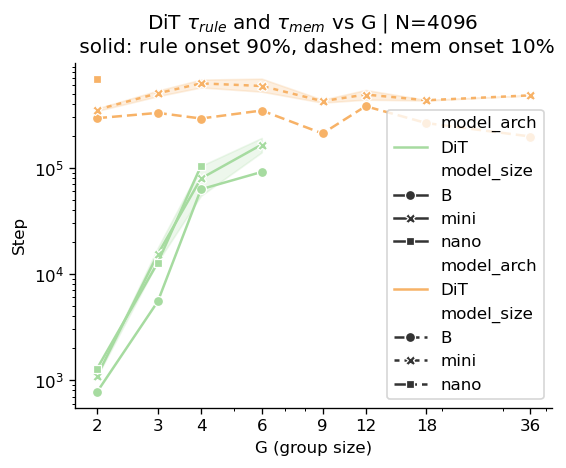

In [206]:
import seaborn as sns
# ── Rule onset vs G, by arch/size ─────────────────────────────────────────
RULE_COLORS = {
    ('DiT', 'nano'): '#5aae61',
    ('DiT', 'mini'): '#1b7837',
    ('DiT', 'B'):    '#a6dba0',
    ('GPT', 'nano'): '#c2a5cf',
    ('GPT', 'mini'): '#762a83',
    ('GPT', 'B'):    '#40004b',
}
MEM_COLORS = {
    ('DiT', 'nano'): '#de6e4b',
    ('DiT', 'mini'): '#e9c46a',
    ('DiT', 'B'):    '#f7b267',
    ('GPT', 'nano'): '#8e9aaf',
    ('GPT', 'mini'): '#4a4e69',
    ('GPT', 'B'):    '#22223b',
}
dashes = [(4, 2), (2, 2), (6, 2, 1, 2), (3, 1, 1, 1), (5, 3, 1, 3)][:]
sub = df.query("N == 4096 and lr == 0.0001").copy()
sub = pd.concat([sub.query("model_arch == 'DiT' and wd == 0.00")], ignore_index=True)
fig, axes = plt.subplots(1, 1, figsize=(4.8, 4), dpi=120)
# Rule onset (solid line)
sns.lineplot(
    data=sub, 
    x='G', y='rule_onset_acc90', 
    hue='model_arch', style='model_size', # 
    markers=True, dashes=False, ax=axes,
    palette={arch: RULE_COLORS.get((arch, size), 'gray') for (arch, size) in RULE_COLORS}
)
# Memorization onset (dashed line, distinct palette)
sns.lineplot(
    data=sub, 
    x='G', y='mem_onset_stat', 
    hue='model_arch', style='model_size', #
    markers=True, dashes=dashes, ax=axes,
    palette={arch: MEM_COLORS.get((arch, size), 'gray') for (arch, size) in MEM_COLORS}
)
axes.set_yscale('log')
axes.set_xscale('log')
# also add xticks for exact values
axes.set_xticks(sorted(sub['G'].unique()))
axes.get_xaxis().set_major_formatter(plt.ScalarFormatter())
axes.set_xlabel('G (group size)')
axes.set_ylabel('Step')
axes.set_title('DiT $\\tau_{rule}$ and $\\tau_{mem}$ vs G | N=4096 \n solid: rule onset 90%, dashed: mem onset 10%')
plt.tight_layout()
saveallforms(FIGDIR, f"DiT_tau_rule_mem_vs_G_4096_synopsis_sep_color", figh=fig)
plt.show()

### Final export version G vs tau_mem tau rule

/tmp/ipykernel_837681/3765148073.py:42: UserWarning: The dashes list has more values (5) than needed (3), which may not be intended.
  sns.lineplot(


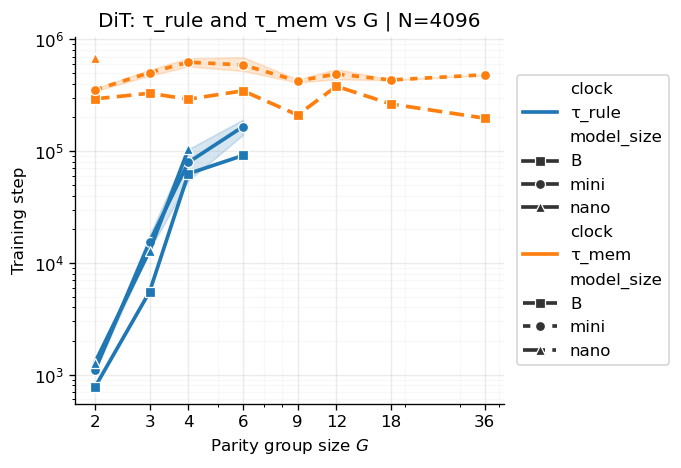

In [221]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Rule/mem onset vs G, by model size ────────────────────────────────────

CLOCK_COLORS = {
    "τ_rule": "#1f77b4",   # matches Panel B rule acc blue
    "τ_mem":  "#ff7f0e",   # matches Panel B mem ratio orange
    # alternative softer orange: "#E76F51"
}

MARKERS = {
    "nano": "^",
    "mini": "o",
    "B": "s",
}
dashes = [(4, 2), (2, 2), (6, 2, 1, 2), (3, 1, 1, 1), (5, 3, 1, 3)][:]

sub = df.query("model_arch == 'DiT' and wd == 0.00 and N == 4096 and lr == 0.0001").copy()

fig, ax = plt.subplots(1, 1, figsize=(4.4, 4), dpi=120)

# τ_rule: solid blue
sub_rule = sub.copy()
sub_rule["clock"] = "τ_rule"

sns.lineplot(
    data=sub_rule,
    x="G", y="rule_onset_acc90", hue="clock", style="model_size",
    palette=CLOCK_COLORS, markers=MARKERS, dashes=False,
    estimator="mean", errorbar=("ci", 95), err_style="band", err_kws={"alpha": 0.18},
    linewidth=2.2,
    ax=ax,
    legend=True,
)

# τ_mem: dashed orange
sub_mem = sub.copy()
sub_mem["clock"] = "τ_mem"

sns.lineplot(
    data=sub_mem,
    x="G", y="mem_onset_stat", hue="clock", style="model_size",
    palette=CLOCK_COLORS, markers=MARKERS, dashes=dashes,
    estimator="mean", errorbar=("ci", 95), err_style="band", err_kws={"alpha": 0.18},
    linewidth=2.2,
    ax=ax,
    legend=True,
)

ax.set_yscale("log")
ax.set_xscale("log")

ax.set_xticks(sorted(sub["G"].unique()))
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_xaxis().set_minor_formatter(mticker.NullFormatter())

ax.set_xlabel("Parity group size $G$")
ax.set_ylabel("Training step")
ax.set_title("DiT: τ_rule and τ_mem vs G | N=4096")
ax.set_ylim(550, 1050000)
ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", alpha=0.08)

plt.tight_layout()
# Move the legend right outside the plot area
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=True)
saveallforms(FIGDIR, "DiT_tau_rule_mem_vs_G_4096_sep_color_lineplots", figh=fig)
plt.show()

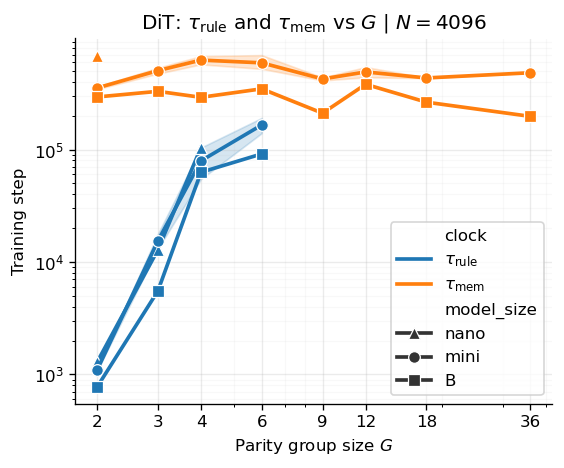

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

# ── Panel C: tau_rule and tau_mem vs G, with seaborn CI ───────────────────

# Coordinate with Panel B:
# rule acc blue, mem ratio orange
TAU_COLORS = {
    r"$\tau_{\mathrm{rule}}$": "#1f77b4",  # Matplotlib default blue
    r"$\tau_{\mathrm{mem}}$":  "#ff7f0e",  # Matplotlib default orange, matches Panel B
}

SIZE_MARKERS = {
    "nano": "^",
    "mini": "o",
    "B": "s",
}

SIZE_DASHES = {
    "nano": "",
    "mini": "",
    "B": "",
}

SIZE_ORDER = ["nano", "mini", "B"]

sub = df.query("N == 4096 and lr == 0.0001").copy()
sub = sub.query("model_arch == 'DiT' and wd == 0.00").copy()

# Reshape wide -> long so seaborn can compute CI for each clock/model size/G group
plot_df = sub.melt(
    id_vars=["G", "model_arch", "model_size"],
    value_vars=["rule_onset_acc90", "mem_onset_stat"],
    var_name="clock_raw",
    value_name="step",
)

plot_df["clock"] = plot_df["clock_raw"].map({
    "rule_onset_acc90": r"$\tau_{\mathrm{rule}}$",
    "mem_onset_stat": r"$\tau_{\mathrm{mem}}$",
})

plot_df = plot_df.dropna(subset=["step", "clock", "model_size", "G"])

fig, ax = plt.subplots(1, 1, figsize=(4.8, 4), dpi=120)

sns.lineplot(
    data=plot_df,
    x="G",
    y="step",
    hue="clock",
    style="model_size",
    hue_order=[r"$\tau_{\mathrm{rule}}$", r"$\tau_{\mathrm{mem}}$"],
    style_order=SIZE_ORDER,
    palette=TAU_COLORS,
    markers=SIZE_MARKERS,
    dashes=False,          # marker shape carries model size
    errorbar=("ci", 95),   # seaborn >= 0.12
    estimator="mean",
    err_style="band",
    err_kws={"alpha": 0.18},
    linewidth=2.2,
    markersize=7,
    ax=ax,
)

# Make τ_mem dashed after seaborn draws lines.
# This preserves seaborn's CI computation while giving clock-specific line styles.
for line in ax.lines:
    label = line.get_label()
    if r"\tau_{\mathrm{mem}}" in label:
        line.set_linestyle("--")
    elif r"\tau_{\mathrm{rule}}" in label:
        line.set_linestyle("-")

ax.set_yscale("log")
ax.set_xscale("log")
G_ticks = sorted(plot_df["G"].dropna().unique())
ax.set_xticks(G_ticks)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_xaxis().set_minor_formatter(mticker.NullFormatter())
ax.set_xlabel("Parity group size G")
ax.set_ylabel("Training step")
ax.set_title(r"DiT: τ_rule and τ_mem vs G | N=4096")
ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", alpha=0.08)

plt.tight_layout()
# saveallforms(FIGDIR, "DiT_tau_rule_mem_vs_G_4096_sns_clock_color_CI", figh=fig)
plt.show()

### Final export version N vs tau_mem tau rule

In [ ]:
from core.fit_lib import fit_loglog, plot_loglog_fit
sub = df.query("model_arch == 'DiT' and model_size == 'mini' and lr == 0.0001 and wd == 0.0")
slope, intercept, r2, n, fn = fit_loglog(sub['N'],sub['mem_onset_stat'], )
# slope, intercept, r2, n = plot_loglog_fit(axes[1], sub['N'],sub['mem_onset_stat'], 
#     # x_min=1E3, x_max=1E4,   # optional: restrict fit range
#     label="DiT-mini", show_slope=True, show_r2=True,
#     color="gray", ls="--")

In [20]:
print("DiT-mini τ_mem vs N scaling")
for G in [2,3,4,6,9,12,18,36]:
    sub = df.query("model_arch == 'DiT' and model_size == 'mini' and lr == 0.0001 and wd == 0.0 and G == @G").copy()
    slope, intercept, r2, n, fn = fit_loglog(sub['N'],sub['mem_onset_stat'], )
    print(f"G={G}\t tau ~ {np.exp(intercept):.2g}N^{slope:.2f} R2={r2:.2f} n={n}")

DiT-mini τ_mem vs N scaling
G=2	 tau ~ 46N^1.08 R2=1.00 n=5
G=3	 tau ~ 36N^1.15 R2=0.99 n=4
G=4	 tau ~ 19N^1.25 R2=0.99 n=4
G=6	 tau ~ 19N^1.24 R2=0.98 n=5
G=9	 tau ~ 70N^1.05 R2=1.00 n=4
G=12	 tau ~ 24N^1.19 R2=0.99 n=4
G=18	 tau ~ 26N^1.17 R2=1.00 n=4
G=36	 tau ~ 19N^1.22 R2=1.00 n=4


/tmp/ipykernel_837681/2653428437.py:58: UserWarning: 
The dashes list has fewer values (5) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


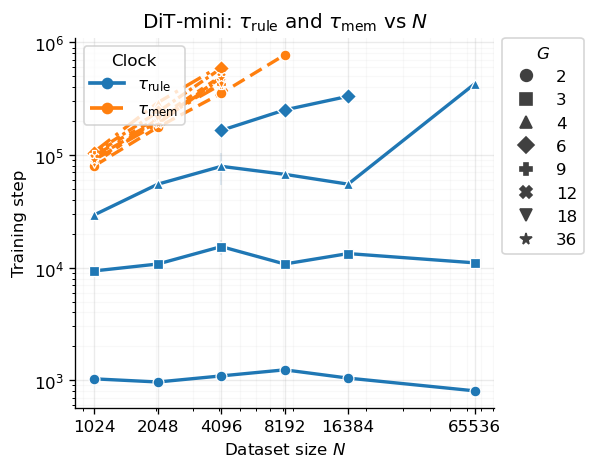

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

# ── Tau rule / tau mem vs N, marker = G ───────────────────────────────────

CLOCK_COLORS = {
    "rule": "#1f77b4",   # match Panel B rule acc blue
    "mem":  "#ff7f0e",   # match Panel B mem ratio orange
    # alternative softer orange: "#E76F51"
}

G_MARKERS = {
    2: "o",
    3: "s",
    4: "^",
    6: "D",
    9: "P",
    12: "X",
    18: "v",
    36: "*",
}
dashes = [(4, 2), (2, 2), (6, 2, 1, 2), (3, 1, 1, 1), (5, 3, 1, 3)][:]

sub = df.query("model_arch == 'DiT' and wd == 0.00 and model_size == 'mini' and lr == 0.0001").copy()

G_order = sorted(sub["G"].dropna().unique())
N_ticks = sorted(sub["N"].dropna().unique())

fig, ax = plt.subplots(1, 1, figsize=(4.5, 4), dpi=120)

# τ_rule: blue, solid
sub_rule = sub.copy()
sub_rule["clock"] = "rule"

sns.lineplot(
    data=sub_rule,
    x="N", y="rule_onset_acc90_innov", hue="clock", style="G",
    style_order=G_order, palette=CLOCK_COLORS, markers=G_MARKERS,
    dashes=False,
    estimator="mean", errorbar=("ci", 95), err_style="band", err_kws={"alpha": 0.16},
    linewidth=2.0,
    markersize=6.5,
    ax=ax,
    legend=False,
)

# τ_mem: orange, dashed
sub_mem = sub.copy()
sub_mem["clock"] = "mem"

sns.lineplot(
    data=sub_mem,
    x="N", y="mem_onset_stat", hue="clock", style="G",
    style_order=G_order, palette=CLOCK_COLORS, markers=G_MARKERS,
    dashes=dashes,  # draw solid first, then force all mem lines dashed below
    estimator="mean", errorbar=("ci", 95), err_style="band", err_kws={"alpha": 0.16},
    linewidth=2.0,
    markersize=6.5,
    ax=ax,
    legend=False,
)


ax.set_yscale("log")
ax.set_xscale("log")
ax.set_ylim(550, 1050000)

ax.set_xticks(N_ticks)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_xaxis().set_minor_formatter(mticker.NullFormatter())

ax.set_xlabel("Dataset size $N$")
ax.set_ylabel("Training step")
ax.set_title("DiT: τ_rule and τ_mem vs N | DiT-mini")

ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", alpha=0.08)

# ── Manual legends: clock color/line + G marker ───────────────────────────

clock_handles = [
    Line2D(
        [0], [0],
        color=CLOCK_COLORS["rule"],
        linestyle="-",
        marker="o",
        linewidth=2.2,
        markersize=6,
        label=r"$\tau_{\mathrm{rule}}$",
    ),
    Line2D(
        [0], [0],
        color=CLOCK_COLORS["mem"],
        linestyle="--",
        marker="o",
        linewidth=2.2,
        markersize=6,
        label=r"$\tau_{\mathrm{mem}}$",
    ),
]

g_handles = [
    Line2D(
        [0], [0],
        color="0.25",
        linestyle="None",
        marker=G_MARKERS[g],
        markersize=7,
        label=f"{g}",
    )
    for g in G_order
]

leg1 = ax.legend(
    handles=clock_handles,
    title="Clock",
    loc="upper left",
    frameon=True,
)
ax.add_artist(leg1)

ax.legend(
    handles=g_handles,
    title="$G$",
    ncol=1,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0.,
    frameon=True,
)

# plt.tight_layout()
plt.show()

/tmp/ipykernel_837681/2517898281.py:78: UserWarning: 
The dashes list has fewer values (1) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


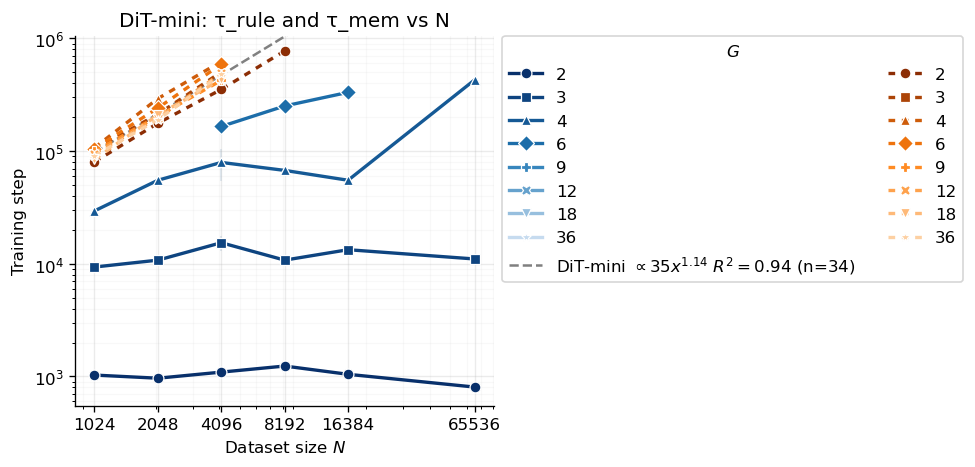

In [237]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

# ── Tau rule / tau mem vs N, color family = clock, shade = G ──────────────

sub = df.query("lr == 0.0001").copy()
sub = sub.query("model_arch == 'DiT' and wd == 0.00 and model_size == 'mini'").copy()

# Optional main-figure simplification
# G_KEEP = [2, 3, 6, 12, 36]
# sub = sub.query("G in @G_KEEP").copy()

G_order = sorted(sub["G"].dropna().unique())
N_ticks = sorted(sub["N"].dropna().unique())

G_MARKERS = {
    2: "o",
    3: "s",
    4: "^",
    6: "D",
    9: "P",
    12: "X",
    18: "v",
    36: "*",
}

# Blue family for τ_rule, orange family for τ_mem.
# The first color is light, the last is darker.
# rule_palette = sns.light_palette("#1f77b4", n_colors=len(G_order) + 1, reverse=True)[:-1]
# mem_palette  = sns.light_palette("#ff7f0e", n_colors=len(G_order) + 1, reverse=True)[:-1]

# RULE_G_COLORS = dict(zip(G_order, rule_palette))
# MEM_G_COLORS  = dict(zip(G_order, mem_palette))
rule_palette = sns.blend_palette(
    ["#c6dbef", "#1f77b4", "#08306b"],  # light blue → panel-B blue → dark navy
    n_colors=len(G_order)
)

mem_palette = sns.blend_palette(
    ["#fdd0a2", "#ff7f0e", "#8c2d04"],  # light orange → panel-B orange → dark burnt orange
    n_colors=len(G_order)
)

RULE_G_COLORS = dict(zip(G_order, reversed(rule_palette)))
MEM_G_COLORS  = dict(zip(G_order, reversed(mem_palette)))

fig, ax = plt.subplots(1, 1, figsize=(4.5, 4), dpi=120)

# τ_rule: blue family, solid
sns.lineplot(
    data=sub,
    x="N",
    y="rule_onset_acc90_innov",
    hue="G",
    hue_order=G_order,
    style="G",
    style_order=G_order,
    palette=RULE_G_COLORS,
    markers=G_MARKERS,
    dashes=False,
    estimator="mean",
    errorbar=("ci", 95),
    err_style="band",
    err_kws={"alpha": 0.14},
    linewidth=2.0,
    markersize=6.5,
    ax=ax,
    legend=True,
)

slope, intercept, r2, n = plot_loglog_fit(ax, sub['N'],sub['mem_onset_stat'], 
    # x_min=1E3, x_max=1E4,   # optional: restrict fit range
    label="DiT-mini", show_slope=True, show_r2=True,
    color="gray", ls="--")
# τ_mem: orange family, dashed
sns.lineplot(
    data=sub,
    x="N",
    y="mem_onset_stat",
    hue="G",
    hue_order=G_order,
    style="G",
    style_order=G_order,
    palette=MEM_G_COLORS,
    markers=G_MARKERS,
    dashes=[(2,2),],
    estimator="mean",
    errorbar=("ci", 95),
    err_style="band",
    err_kws={"alpha": 0.14},
    linewidth=2.0,
    markersize=6.5,
    ax=ax,
    legend=True,
)


# slope, intercept, r2, n = plot_loglog_fit(axes[1], sub['N'],sub['mem_onset_stat'], 
#     # x_min=1E3, x_max=1E4,   # optional: restrict fit range
#     label="DiT-mini", show_slope=True, show_r2=True,
#     color="gray", ls="--")
# plt.legend()

ax.set_yscale("log")
ax.set_xscale("log")

ax.set_xticks(N_ticks)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_xaxis().set_minor_formatter(mticker.NullFormatter())

ax.set_xlabel("Dataset size $N$")
ax.set_ylabel("Training step")
ax.set_title(r"DiT-mini: τ_rule and τ_mem vs N")
ax.set_ylim(550, 1050000)
ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", alpha=0.08)

# ── Legends ───────────────────────────────────────────────────────────────
# clock_handles = [
#     Line2D(
#         [0], [0],
#         color="#1f77b4",
#         linestyle="-",
#         marker="o",
#         linewidth=2.2,
#         markersize=6,
#         label=r"$\tau_{\mathrm{rule}}$",
#     ),
#     Line2D(
#         [0], [0],
#         color="#ff7f0e",
#         linestyle="--",
#         marker="o",
#         linewidth=2.2,
#         markersize=6,
#         label=r"$\tau_{\mathrm{mem}}$",
#     ),
# ]

# # Use neutral markers for G legend if you want shape-only legend:
# g_handles = [
#     Line2D(
#         [0], [0],
#         color="0.25",
#         linestyle="None",
#         marker=G_MARKERS[g],
#         markersize=7,
#         label=f"{g}",
#     )
#     for g in G_order
# ]

# leg1 = ax.legend(
#     handles=clock_handles,
#     title="Clock",
#     loc="upper left",
#     frameon=True,
# )
# ax.add_artist(leg1)

ax.legend(
    # handles=g_handles,
    title="$G$",
    ncol=2,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0.,
    frameon=True,
)
saveallforms(FIGDIR, "DiT_tau_rule_mem_vs_N_mini_sep_color_hue_lineplots", figh=fig)
# plt.tight_layout()
plt.show()

/tmp/ipykernel_837681/652345050.py:78: UserWarning: 
The dashes list has fewer values (1) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


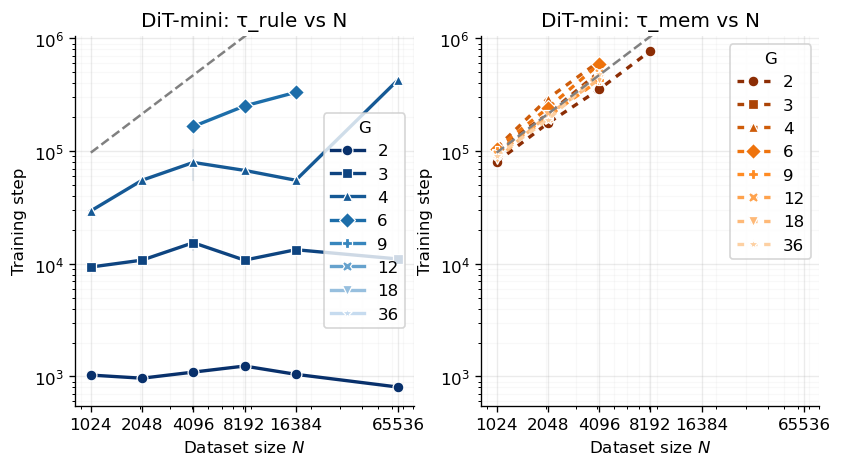

In [240]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

# ── Tau rule / tau mem vs N, color family = clock, shade = G ──────────────

sub = df.query("lr == 0.0001").copy()
sub = sub.query("model_arch == 'DiT' and wd == 0.00 and model_size == 'mini'").copy()

# Optional main-figure simplification
# G_KEEP = [2, 3, 6, 12, 36]
# sub = sub.query("G in @G_KEEP").copy()

G_order = sorted(sub["G"].dropna().unique())
N_ticks = sorted(sub["N"].dropna().unique())

G_MARKERS = {
    2: "o",
    3: "s",
    4: "^",
    6: "D",
    9: "P",
    12: "X",
    18: "v",
    36: "*",
}

# Blue family for τ_rule, orange family for τ_mem.
# The first color is light, the last is darker.
# rule_palette = sns.light_palette("#1f77b4", n_colors=len(G_order) + 1, reverse=True)[:-1]
# mem_palette  = sns.light_palette("#ff7f0e", n_colors=len(G_order) + 1, reverse=True)[:-1]

# RULE_G_COLORS = dict(zip(G_order, rule_palette))
# MEM_G_COLORS  = dict(zip(G_order, mem_palette))
rule_palette = sns.blend_palette(
    ["#c6dbef", "#1f77b4", "#08306b"],  # light blue → panel-B blue → dark navy
    n_colors=len(G_order)
)

mem_palette = sns.blend_palette(
    ["#fdd0a2", "#ff7f0e", "#8c2d04"],  # light orange → panel-B orange → dark burnt orange
    n_colors=len(G_order)
)

RULE_G_COLORS = dict(zip(G_order, reversed(rule_palette)))
MEM_G_COLORS  = dict(zip(G_order, reversed(mem_palette)))

fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=120)

# τ_rule: blue family, solid
sns.lineplot(
    data=sub,
    x="N",
    y="rule_onset_acc90_innov",
    hue="G",
    hue_order=G_order,
    style="G",
    style_order=G_order,
    palette=RULE_G_COLORS,
    markers=G_MARKERS,
    dashes=False,
    estimator="mean",
    errorbar=("ci", 95),
    err_style="band",
    err_kws={"alpha": 0.14},
    linewidth=2.0,
    markersize=6.5,
    ax=axs[0],
    legend=True,
)

slope, intercept, r2, n = plot_loglog_fit(axs[0], sub['N'],sub['mem_onset_stat'], 
    # x_min=1E3, x_max=1E4,   # optional: restrict fit range
    label="DiT-mini", show_slope=True, show_r2=True,
    color="gray", ls="--")
# τ_mem: orange family, dashed
sns.lineplot(
    data=sub,
    x="N",
    y="mem_onset_stat",
    hue="G",
    hue_order=G_order,
    style="G",
    style_order=G_order,
    palette=MEM_G_COLORS,
    markers=G_MARKERS,
    dashes=[(2,2),],
    estimator="mean",
    errorbar=("ci", 95),
    err_style="band",
    err_kws={"alpha": 0.14},
    linewidth=2.0,
    markersize=6.5,
    ax=axs[1],
    legend=True,
)
slope, intercept, r2, n = plot_loglog_fit(axs[1], sub['N'],sub['mem_onset_stat'], 
    # x_min=1E3, x_max=1E4,   # optional: restrict fit range
    label="DiT-mini", show_slope=True, show_r2=True,
    color="gray", ls="--")


# slope, intercept, r2, n = plot_loglog_fit(axes[1], sub['N'],sub['mem_onset_stat'], 
#     # x_min=1E3, x_max=1E4,   # optional: restrict fit range
#     label="DiT-mini", show_slope=True, show_r2=True,
#     color="gray", ls="--")
# plt.legend()

axs[0].set_title(r"DiT-mini: τ_rule vs N")
axs[1].set_title(r"DiT-mini: τ_mem vs N")
for ax in axs:
    ax.set_yscale("log")
    ax.set_xscale("log")

    ax.set_xticks(N_ticks)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.get_xaxis().set_minor_formatter(mticker.NullFormatter())

    ax.set_xlabel("Dataset size $N$")
    ax.set_ylabel("Training step")
    ax.set_ylim(550, 1050000)
    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", alpha=0.08)

# ── Legends ───────────────────────────────────────────────────────────────
# clock_handles = [
#     Line2D(
#         [0], [0],
#         color="#1f77b4",
#         linestyle="-",
#         marker="o",
#         linewidth=2.2,
#         markersize=6,
#         label=r"$\tau_{\mathrm{rule}}$",
#     ),
#     Line2D(
#         [0], [0],
#         color="#ff7f0e",
#         linestyle="--",
#         marker="o",
#         linewidth=2.2,
#         markersize=6,
#         label=r"$\tau_{\mathrm{mem}}$",
#     ),
# ]

# # Use neutral markers for G legend if you want shape-only legend:
# g_handles = [
#     Line2D(
#         [0], [0],
#         color="0.25",
#         linestyle="None",
#         marker=G_MARKERS[g],
#         markersize=7,
#         label=f"{g}",
#     )
#     for g in G_order
# ]

# leg1 = ax.legend(
#     handles=clock_handles,
#     title="Clock",
#     loc="upper left",
#     frameon=True,
# )
# ax.add_artist(leg1)

# axs[1].legend(
#     # handles=g_handles,
#     title="$G$",
#     ncol=2,
#     bbox_to_anchor=(1.02, 1),
#     loc="upper left",
#     borderaxespad=0.,
#     frameon=True,
# )
saveallforms(FIGDIR, "DiT_tau_rule_mem_vs_N_mini_sep_color_hue_lineplots_sep", figh=fig)
# plt.tight_layout()
plt.show()

### Effect of N on rule and mem onset

/tmp/ipykernel_793871/1565406062.py:32: UserWarning: The dashes list has more values (5) than needed (1), which may not be intended.
  sns.lineplot(


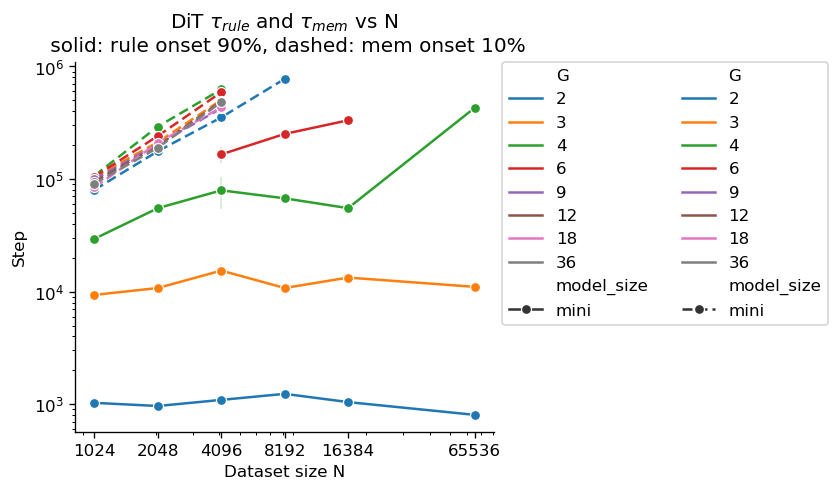

In [56]:
import seaborn as sns
# ── Rule onset vs G, by arch/size ─────────────────────────────────────────
RULE_COLORS = {
    ('DiT', 'nano'): '#5aae61',
    ('DiT', 'mini'): '#1b7837',
    ('DiT', 'B'):    '#a6dba0',
    ('GPT', 'nano'): '#c2a5cf',
    ('GPT', 'mini'): '#762a83',
    ('GPT', 'B'):    '#40004b',
}
MEM_COLORS = {
    ('DiT', 'nano'): '#de6e4b',
    ('DiT', 'mini'): '#e9c46a',
    ('DiT', 'B'):    '#f7b267',
    ('GPT', 'nano'): '#8e9aaf',
    ('GPT', 'mini'): '#4a4e69',
    ('GPT', 'B'):    '#22223b',
}
dashes = [(4, 2), (2, 2), (6, 2, 1, 2), (3, 1, 1, 1), (5, 3, 1, 3)][:]
sub = df.query("lr == 0.0001").copy()
sub = pd.concat([sub.query("model_arch == 'DiT' and wd == 0.00 and model_size == 'mini'")], ignore_index=True)
fig, axes = plt.subplots(1, 1, figsize=(4.5, 4), dpi=120)
# Rule onset (solid line)
sns.lineplot(
    data=sub, 
    x='N', y='rule_onset_acc90_innov', 
    hue='G', style='model_size', 
    markers=True, dashes=False, ax=axes, palette="tab10"
    # palette={arch: RULE_COLORS.get((arch, size), 'gray') for (arch, size) in RULE_COLORS}
)
# Memorization onset (dashed line, distinct palette)
sns.lineplot(
    data=sub, 
    x='N', y='mem_onset_stat', 
    hue='G', style='model_size', 
    markers=True, dashes=dashes, ax=axes, palette="tab10"
    # palette={arch: MEM_COLORS.get((arch, size), 'gray') for (arch, size) in MEM_COLORS}
)
axes.set_yscale('log')
axes.set_xscale('log')
# also add xticks for exact values
axes.set_xticks(sorted(sub['N'].unique()))
axes.get_xaxis().set_major_formatter(plt.ScalarFormatter())
axes.set_xlabel('Dataset size N')
axes.set_ylabel('Step')
axes.set_title('DiT $\\tau_{rule}$ and $\\tau_{mem}$ vs N \n solid: rule onset 90%, dashed: mem onset 10%')
handles, labels = axes.get_legend_handles_labels()
axes.legend(handles, labels, ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
# plt.tight_layout()
plt.show()

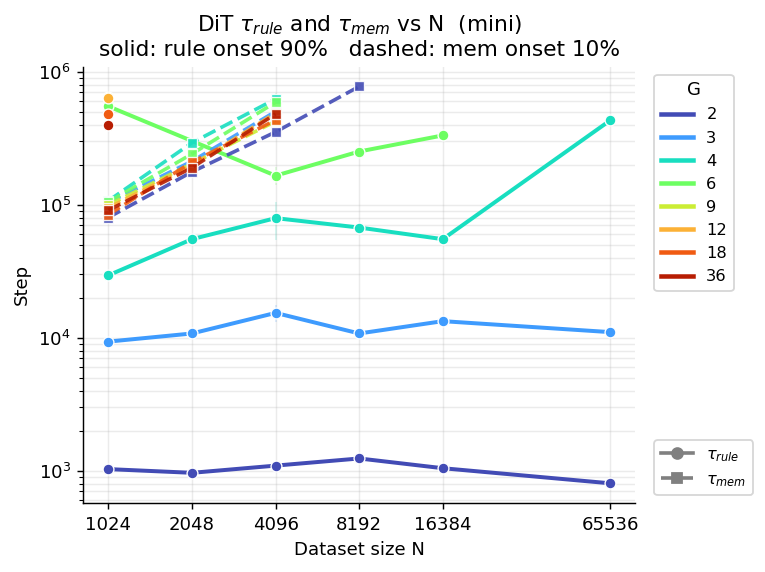

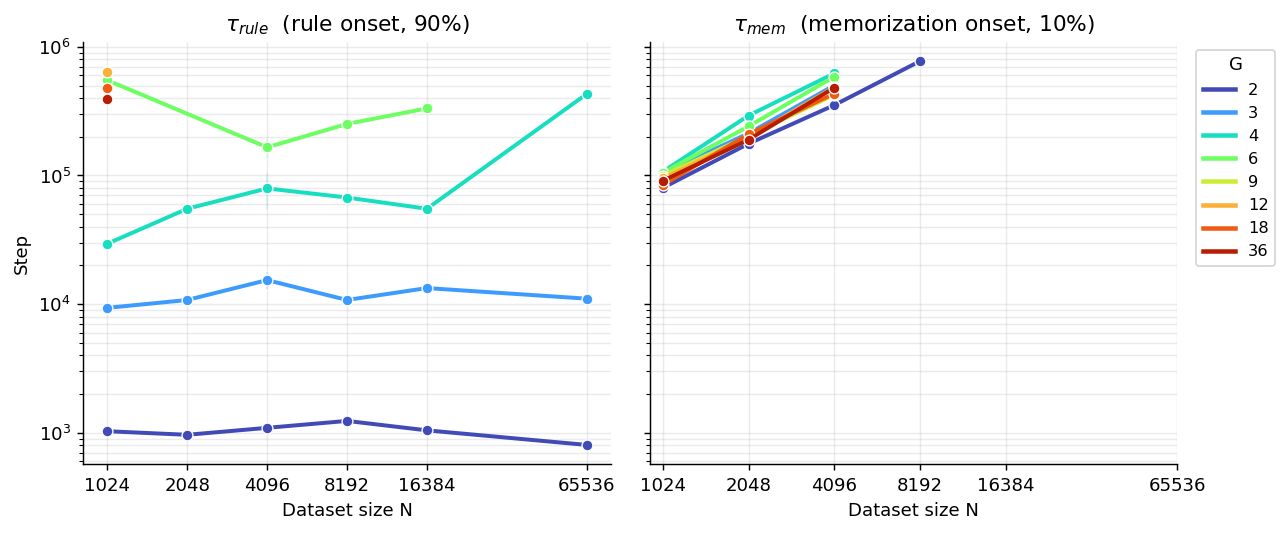

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker

def style_axes(ax, x_ticks):
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xticks(x_ticks)                                  # ticks only at data values
    ax.xaxis.set_minor_locator(mticker.NullLocator())       # kill the 10^k minor ticks on x
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.grid(False)
    ax.grid(True, axis='x', which='major', alpha=0.3)       # x-grid only at data values
    ax.grid(True, axis='y', which='major', alpha=0.3)       # y-grid at decades
    ax.grid(True, axis='y', which='minor', alpha=0.12)      # faint y minor — drop if you want pure decades
    
sub = df.query("lr == 0.0001 and model_arch == 'DiT' and wd == 0.00 and model_size == 'mini'").copy()
G_vals = sorted(sub['G'].unique())

# Turbo, sampled away from the very-dark and very-light extremes
cmap = plt.get_cmap("turbo")
xs = np.linspace(0.08, 0.92, len(G_vals))
turbo_pal = {g: cmap(x) for g, x in zip(G_vals, xs)}

# ===== Option A: single panel, solid=rule / dashed=mem =====
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5), dpi=130)
sns.lineplot(data=sub, x='N', y='rule_onset_acc90',
             hue='G', hue_order=G_vals, palette=turbo_pal,
             marker='o', markersize=6, linewidth=2.2, ax=ax, legend=False)
sns.lineplot(data=sub, x='N', y='mem_onset_stat',
             hue='G', hue_order=G_vals, palette=turbo_pal,
             marker='s', markersize=5, linewidth=2.0, linestyle='--',
             ax=ax, legend=False, alpha=0.9)
style_axes(ax, sorted(sub['N'].unique()))
# ax.set_yscale('log'); ax.set_xscale('log')
# ax.set_xticks(sorted(sub['N'].unique()))
# ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel('Dataset size N'); ax.set_ylabel('Step')
ax.set_title('DiT $\\tau_{rule}$ and $\\tau_{mem}$ vs N  (mini)\n'
             'solid: rule onset 90%   dashed: mem onset 10%')
ax.grid(True, which='both', alpha=0.25)
handles_G = [Line2D([0],[0], color=turbo_pal[g], lw=2.5, label=f'{g}') for g in G_vals]
handles_style = [Line2D([0],[0], color='gray', lw=2, marker='o', linestyle='-',  label=r'$\tau_{rule}$'),
                 Line2D([0],[0], color='gray', lw=2, marker='s', linestyle='--', label=r'$\tau_{mem}$')]
leg1 = ax.legend(handles=handles_G, title='G', loc='upper left',
                 bbox_to_anchor=(1.02, 1.0), fontsize=9, title_fontsize=10)
ax.add_artist(leg1)
ax.legend(handles=handles_style, loc='lower left', bbox_to_anchor=(1.02, 0.0), fontsize=9)
plt.tight_layout(); plt.show()

# ===== Option B: two panels (rule | mem) =====
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), dpi=130, sharey=True)
for ax, ycol, ttl in zip(axes,
        ['rule_onset_acc90', 'mem_onset_stat'],
        [r'$\tau_{rule}$  (rule onset, 90%)', r'$\tau_{mem}$  (memorization onset, 10%)']):
    sns.lineplot(data=sub, x='N', y=ycol,
                 hue='G', hue_order=G_vals, palette=turbo_pal,
                 marker='o', markersize=6, linewidth=2.2, ax=ax, legend=False)
    # ax.set_yscale('log'); ax.set_xscale('log')
    # ax.set_xticks(sorted(sub['N'].unique()))
    # ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    style_axes(ax, sorted(sub['N'].unique()))
    ax.set_xlabel('Dataset size N'); ax.set_title(ttl)
    ax.grid(True, which='both', alpha=0.25)
axes[0].set_ylabel('Step')
handles_G = [Line2D([0],[0], color=turbo_pal[g], lw=2.5, label=f'{g}') for g in G_vals]
axes[1].legend(handles=handles_G, title='G', loc='upper left',
               bbox_to_anchor=(1.02, 1.0), fontsize=9, title_fontsize=10)
plt.tight_layout(); plt.show()

### Systematic plot for export

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.lines import Line2D


def plot_onset_vs_x(
    data,
    x,
    y_solid,
    y_dashed=None,
    hue='G',
    *,
    palette='turbo',
    palette_range=(0.08, 0.92),
    solid_label=r'$\tau_{rule}$',
    dashed_label=r'$\tau_{mem}$',
    hue_title=None,
    title=None,
    xlabel=None,
    ylabel='Step',
    figsize=(6, 4.5),
    dpi=130,
    ax=None,
    log_x=True,
    log_y=True,
    y_minor_grid=True,
    marker_solid='o',
    marker_dashed='s',
):
    """
    Plot one or two onset-step curves vs an x variable, with `hue` levels
    color-mapped through a sequential colormap. X-axis ticks/grid are placed
    only at the actual data values (no 10^k minor ticks).

    Parameters
    ----------
    data : DataFrame
    x, y_solid : str
        Columns for x-axis and the solid-line metric.
    y_dashed : str or None
        Optional second metric, drawn as dashed lines on the same axis.
    hue : str
        Categorical/ordered column mapped to color (e.g. 'G').
    palette : str
        Any matplotlib colormap name. 'turbo' / 'viridis' / 'plasma' work well
        for ordered hue.
    palette_range : (float, float)
        Sub-range of the colormap to sample from, to avoid muddy endpoints.
    solid_label, dashed_label : str
        Legend labels for the line-style legend.
    hue_title : str or None
        Title above the hue legend. Defaults to `hue`.
    title, xlabel, ylabel : str
        Axis decorations. xlabel defaults to `x`.
    ax : matplotlib Axes or None
        If None, a new figure+axes is created.
    log_x, log_y : bool
        Whether to set the corresponding axis to log scale.
    y_minor_grid : bool
        Faint gridlines between y-axis decades.
    marker_solid, marker_dashed : str
        Marker shapes for the two metrics (redundant with line style).

    Returns
    -------
    ax : matplotlib Axes
    """
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)

    hue_vals = sorted(data[hue].unique())
    cmap = plt.get_cmap(palette)
    samples = np.linspace(palette_range[0], palette_range[1], len(hue_vals))
    hue_palette = {h: cmap(s) for h, s in zip(hue_vals, samples)}

    # Solid lines
    if y_solid is not None:
        sns.lineplot(
            data=data, x=x, y=y_solid,
            hue=hue, hue_order=hue_vals, palette=hue_palette,
            marker=marker_solid, markersize=6, linewidth=2.2,
            ax=ax, legend=False,
        )
    # Dashed lines (optional)
    if y_dashed is not None:
        sns.lineplot(
            data=data, x=x, y=y_dashed,
            hue=hue, hue_order=hue_vals, palette=hue_palette,
            marker=marker_dashed, markersize=5, linewidth=2.0,
            linestyle='--', alpha=0.9,
            ax=ax, legend=False,
        )

    # Scales + ticks: ticks only at actual x-data values, no 10^k minor ticks
    if log_x:
        ax.set_xscale('log')
    if log_y:
        ax.set_yscale('log')
    x_ticks = sorted(data[x].unique())
    ax.set_xticks(x_ticks)
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())

    # Grid: x at data values; y at decades (+ optional faint minor)
    ax.grid(False)
    ax.grid(True, axis='x', which='major', alpha=0.3)
    ax.grid(True, axis='y', which='major', alpha=0.3)
    if log_y and y_minor_grid:
        ax.grid(True, axis='y', which='minor', alpha=0.12)

    ax.set_xlabel(xlabel if xlabel is not None else x)
    ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title)

    # Custom legends: one for hue colors, one for line style (only if dashed shown)
    handles_hue = [Line2D([0], [0], color=hue_palette[h], lw=2.5, label=str(h))
                   for h in hue_vals]
    leg_hue = ax.legend(
        handles=handles_hue, title=hue_title if hue_title is not None else hue,
        loc='upper left', bbox_to_anchor=(1.02, 1.0),
        fontsize=9, title_fontsize=10, frameon=True,
    )
    ax.add_artist(leg_hue)

    if y_dashed is not None:
        handles_style = [
            Line2D([0], [0], color='gray', lw=2, marker=marker_solid,
                   linestyle='-', label=solid_label),
            Line2D([0], [0], color='gray', lw=2, marker=marker_dashed,
                   linestyle='--', label=dashed_label),
        ]
        ax.legend(
            handles=handles_style, loc='lower left',
            bbox_to_anchor=(1.02, 0.0), fontsize=9, frameon=True,
        )

    return ax

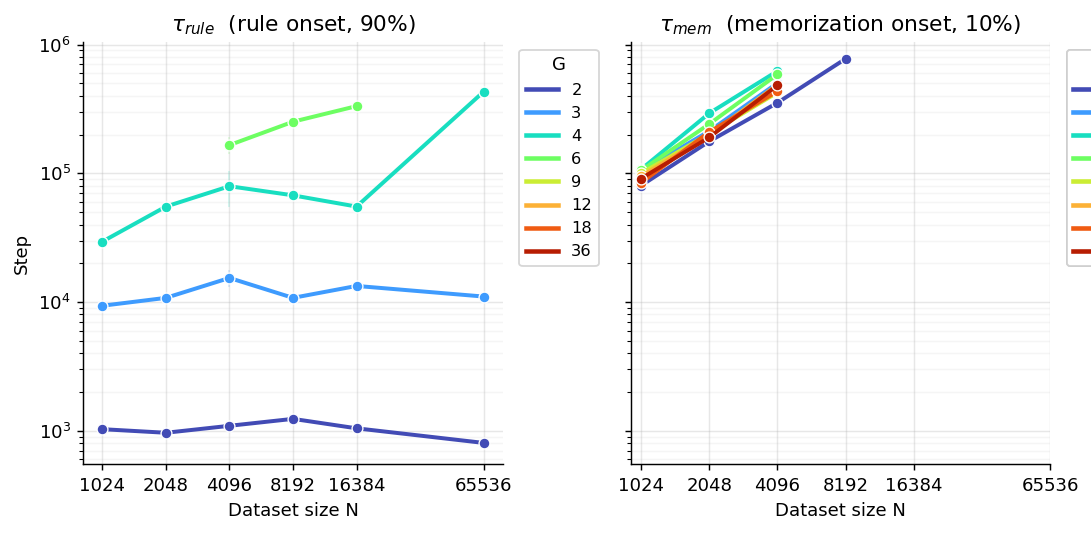

In [63]:
sub = df.query("model_arch == 'DiT' and model_size == 'mini' and lr == 0.0001 and wd == 0.0")
fig, axes = plt.subplots(1, 2, figsize=(8.5, 4.2), dpi=130, sharey=True)
plot_onset_vs_x(sub, x='N', y_solid='rule_onset_acc90_innov', hue='G',
                xlabel='Dataset size N', ylabel='Step',
                title=r'$\tau_{rule}$  (rule onset, 90%)', ax=axes[0])
plot_onset_vs_x(sub, x='N', y_solid='mem_onset_stat', hue='G',
                xlabel='Dataset size N', ylabel='',
                title=r'$\tau_{mem}$  (memorization onset, 10%)', ax=axes[1])

# remove the duplicate hue legend on the left panel
axes[0].get_legend().remove()
plt.tight_layout(); 
axes[0].set_ylim(550, 1050000)
axes[1].set_ylim(550, 1050000)
plt.tight_layout(); 
saveallforms(FIGDIR, f"DiT_tau_rule_mem_vs_N_mini_synopsis_separate", figh=fig)
plt.show()

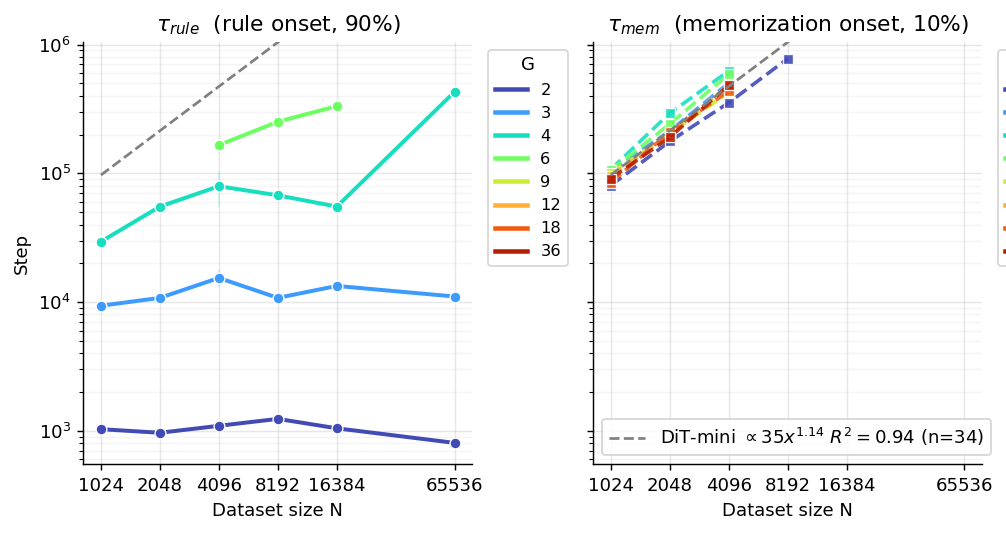

In [201]:
from core.fit_lib import fit_loglog, plot_loglog_fit
sub = df.query("model_arch == 'DiT' and model_size == 'mini' and lr == 0.0001 and wd == 0.0")
fig, axes = plt.subplots(1, 2, figsize=(8.0, 4.2), dpi=130, sharey=True)
plot_onset_vs_x(sub, x='N', y_solid='rule_onset_acc90_innov', hue='G',
                xlabel='Dataset size N', ylabel='Step',
                title=r'$\tau_{rule}$  (rule onset, 90%)', ax=axes[0])
plot_onset_vs_x(sub, x='N', y_solid=None, y_dashed='mem_onset_stat', hue='G',
                xlabel='Dataset size N', ylabel='', 
                title=r'$\tau_{mem}$  (memorization onset, 10%)', ax=axes[1])

slope, intercept, r2, n = plot_loglog_fit(axes[1], sub['N'],sub['mem_onset_stat'], 
    # x_min=1E3, x_max=1E4,   # optional: restrict fit range
    label="DiT-mini", show_slope=True, show_r2=True,
    color="gray", ls="--")
plt.legend()
slope, intercept, r2, n = plot_loglog_fit(axes[0], sub['N'],sub['mem_onset_stat'], 
    # x_min=1E3, x_max=1E4,   # optional: restrict fit range
    label="DiT-mini", show_slope=True, show_r2=True,
    color="gray", ls="--")
# remove the duplicate hue legend on the left panel
axes[0].get_legend().remove()
axes[0].set_ylim(550, 1050000)
axes[1].set_ylim(550, 1050000)
plt.tight_layout(); 
saveallforms(FIGDIR, f"DiT_tau_rule_mem_vs_N_mini_synopsis_separate_with_fit", figh=fig)
plt.show()

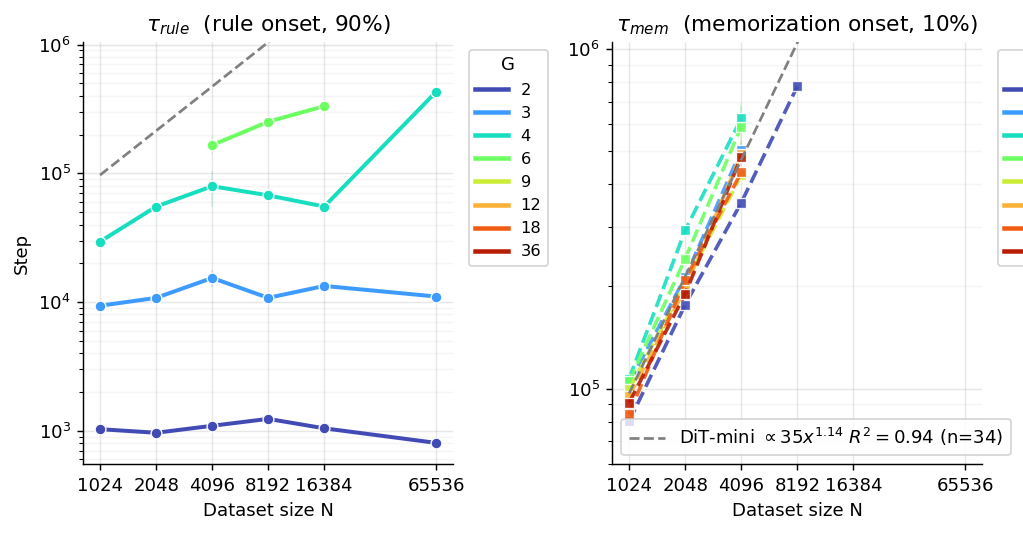

In [202]:
from core.fit_lib import fit_loglog, plot_loglog_fit
sub = df.query("model_arch == 'DiT' and model_size == 'mini' and lr == 0.0001 and wd == 0.0")
fig, axes = plt.subplots(1, 2, figsize=(8.0, 4.2), dpi=130, sharey=False)
plot_onset_vs_x(sub, x='N', y_solid='rule_onset_acc90_innov', hue='G',
                xlabel='Dataset size N', ylabel='Step',
                title=r'$\tau_{rule}$  (rule onset, 90%)', ax=axes[0])
plot_onset_vs_x(sub, x='N', y_solid=None, y_dashed='mem_onset_stat', hue='G',
                xlabel='Dataset size N', ylabel='',
                title=r'$\tau_{mem}$  (memorization onset, 10%)', ax=axes[1])


# remove the duplicate hue legend on the left panel
axes[0].get_legend().remove()
slope, intercept, r2, n = plot_loglog_fit(axes[1], sub['N'],sub['mem_onset_stat'], 
    # x_min=1E3, x_max=1E4,   # optional: restrict fit range
    label="DiT-mini", show_slope=True, show_r2=True,
    color="gray", ls="--")
plt.legend()
slope, intercept, r2, n = plot_loglog_fit(axes[0], sub['N'],sub['mem_onset_stat'], 
    # x_min=1E3, x_max=1E4,   # optional: restrict fit range
    label="DiT-mini", show_slope=True, show_r2=True,
    color="gray", ls="--")
axes[0].set_ylim(550, 1050000)
axes[1].set_ylim(6E4, 1050000)
plt.tight_layout(); 
saveallforms(FIGDIR, f"DiT_tau_rule_mem_vs_N_mini_synopsis_separate_with_fit_alter_ylim", figh=fig)
plt.show()

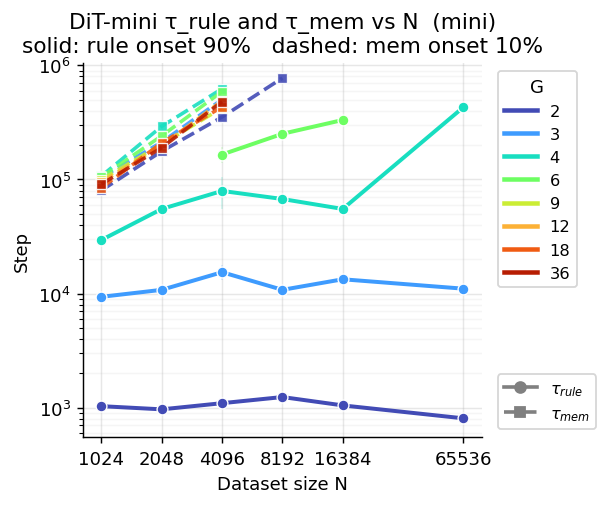

In [64]:
sub = df.query("model_arch == 'DiT' and model_size == 'mini' and lr == 0.0001 and wd == 0.0")
fig, ax = plt.subplots(1, 1, figsize=(4.8, 4), dpi=130, sharey=True)
ax = plot_onset_vs_x(
    sub,
    x='N', y_solid='rule_onset_acc90_innov', y_dashed='mem_onset_stat',
    hue='G',
    xlabel='Dataset size N',
    title='DiT-mini τ_rule and τ_mem vs N  (mini)\n'
          'solid: rule onset 90%   dashed: mem onset 10%',
    ax=ax,
)
ax.set_ylim(550, 1050000)
plt.tight_layout(); 
saveallforms(FIGDIR, f"DiT_tau_rule_mem_vs_N_mini_synopsis", figh=fig)
plt.show()

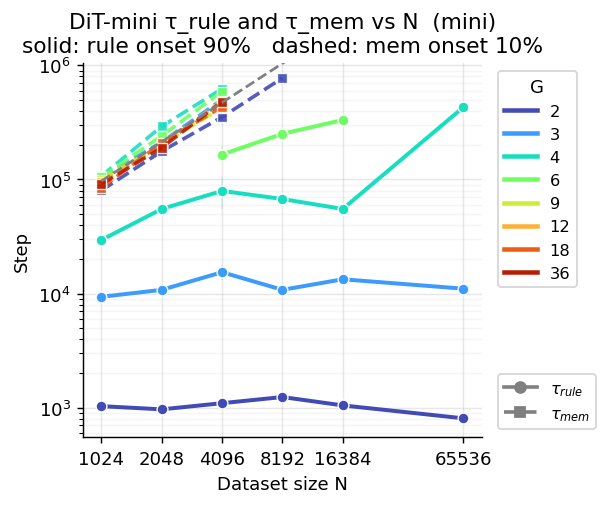

In [83]:
from core.fit_lib import fit_loglog, plot_loglog_fit
sub = df.query("model_arch == 'DiT' and model_size == 'mini' and lr == 0.0001 and wd == 0.0")
fig, ax = plt.subplots(1, 1, figsize=(4.8, 4), dpi=130, sharey=True)
ax = plot_onset_vs_x(
    sub,
    x='N', y_solid='rule_onset_acc90_innov', y_dashed='mem_onset_stat',
    hue='G',
    xlabel='Dataset size N',
    title='DiT-mini τ_rule and τ_mem vs N  (mini)\n'
          'solid: rule onset 90%   dashed: mem onset 10%',
    ax=ax,
)
# fit + plot overlay in one call
slope, intercept, r2, n = plot_loglog_fit(ax, sub['N'],sub['mem_onset_stat'], 
    # x_min=1E3, x_max=1E4,   # optional: restrict fit range
    label="DiT-mini", show_slope=True, show_r2=True,
    color="gray", ls="--")
ax.set_ylim(550, 1050000)
plt.tight_layout(); 
saveallforms(FIGDIR, f"DiT_tau_rule_mem_vs_N_mini_synopsis_with_fit", figh=fig)
plt.show()

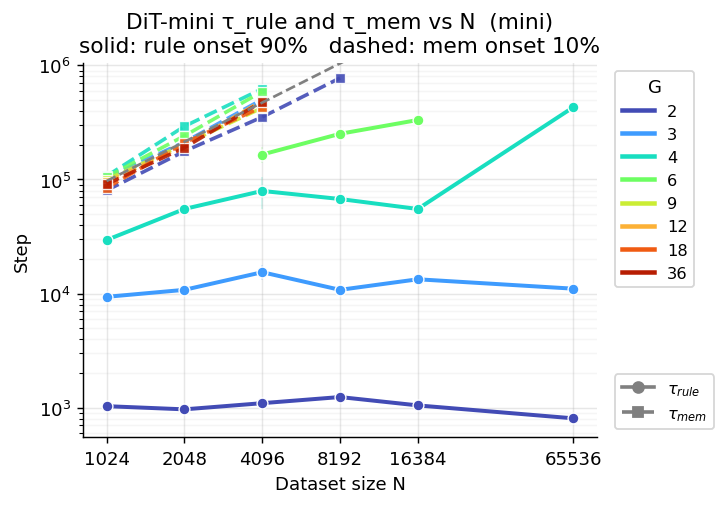

In [86]:
from core.fit_lib import fit_loglog, plot_loglog_fit
sub = df.query("model_arch == 'DiT' and model_size == 'mini' and lr == 0.0001 and wd == 0.0")
fig, ax = plt.subplots(1, 1, figsize=(5.7, 4), dpi=130, sharey=True)
ax = plot_onset_vs_x(
    sub,
    x='N', y_solid='rule_onset_acc90_innov', y_dashed='mem_onset_stat',
    hue='G',
    xlabel='Dataset size N',
    title='DiT-mini τ_rule and τ_mem vs N  (mini)\n'
          'solid: rule onset 90%   dashed: mem onset 10%',
    ax=ax,
)
# fit + plot overlay in one call
slope, intercept, r2, n = plot_loglog_fit(ax, sub['N'],sub['mem_onset_stat'], 
    # x_min=1E3, x_max=1E4,   # optional: restrict fit range
    label="DiT-mini", show_slope=True, show_r2=True,
    color="gray", ls="--")
ax.set_ylim(550, 1050000)
plt.tight_layout(); 
saveallforms(FIGDIR, f"DiT_tau_rule_mem_vs_N_mini_synopsis_with_fit_rectwider", figh=fig)
plt.show()

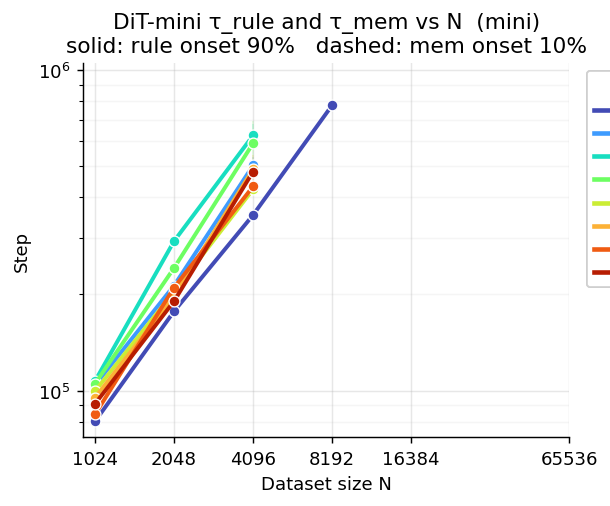

In [69]:
sub = df.query("model_arch == 'DiT' and model_size == 'mini' and lr == 0.0001 and wd == 0.0")
fig, ax = plt.subplots(1, 1, figsize=(4.8, 4), dpi=130, sharey=True)
ax = plot_onset_vs_x(
    sub,
    x='N', y_solid='mem_onset_stat', 
    hue='G',
    xlabel='Dataset size N',
    title='DiT-mini τ_rule and τ_mem vs N  (mini)\n'
          'solid: rule onset 90%   dashed: mem onset 10%',
    ax=ax,
)
ax.set_ylim(None, 1050000)
plt.tight_layout(); 
saveallforms(FIGDIR, f"DiT_tau_mem_vs_N_mini_synopsis", figh=fig)
plt.show()

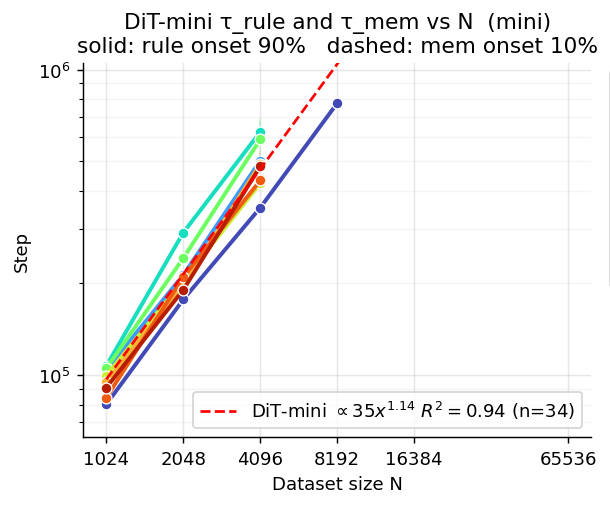

In [79]:

from core.fit_lib import fit_loglog, plot_loglog_fit
sub = df.query("model_arch == 'DiT' and model_size == 'mini' and lr == 0.0001 and wd == 0.0")
fig, ax = plt.subplots(1, 1, figsize=(4.8, 4), dpi=130, sharey=True)
ax = plot_onset_vs_x(
    sub,
    x='N', y_solid='mem_onset_stat', 
    hue='G',
    xlabel='Dataset size N',
    title='DiT-mini τ_rule and τ_mem vs N  (mini)\n'
          'solid: rule onset 90%   dashed: mem onset 10%',
    ax=ax,
)
# fit + plot overlay in one call
slope, intercept, r2, n = plot_loglog_fit(ax, sub['N'],sub['mem_onset_stat'], 
    # x_min=1E3, x_max=1E4,   # optional: restrict fit range
    label="DiT-mini", show_slope=True, show_r2=True,
    color="red", ls="--")

ax.set_ylim(None, 1050000)
plt.legend()
plt.tight_layout(); 
saveallforms(FIGDIR, f"DiT_tau_mem_vs_N_mini_synopsis_with_fit", figh=fig)
plt.show()

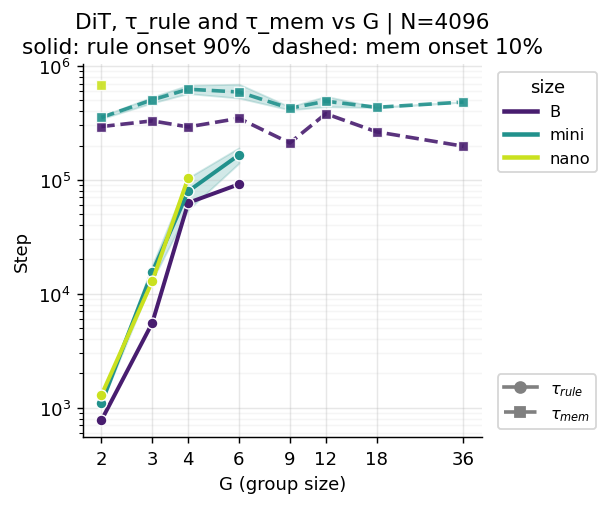

In [65]:
sub2 = df.query("model_arch == 'DiT' and N == 4096 and lr == 0.0001 and wd == 0.0")
fig, ax = plt.subplots(1, 1, figsize=(4.8, 4), dpi=130, sharey=True)
ax = plot_onset_vs_x(
    sub2,
    x='G', y_solid='rule_onset_acc90', y_dashed='mem_onset_stat',
    hue='model_size',          # color by size instead of G
    palette='viridis',
    xlabel='G (group size)',
    hue_title='size',
    title='DiT, τ_rule and τ_mem vs G | N=4096\n'
          'solid: rule onset 90%   dashed: mem onset 10%',
    ax=ax,
)
ax.set_ylim(550, 1050000)
plt.tight_layout(); 
saveallforms(FIGDIR, f"DiT_tau_rule_mem_vs_G_N4096_synopsis", figh=fig)
plt.show()

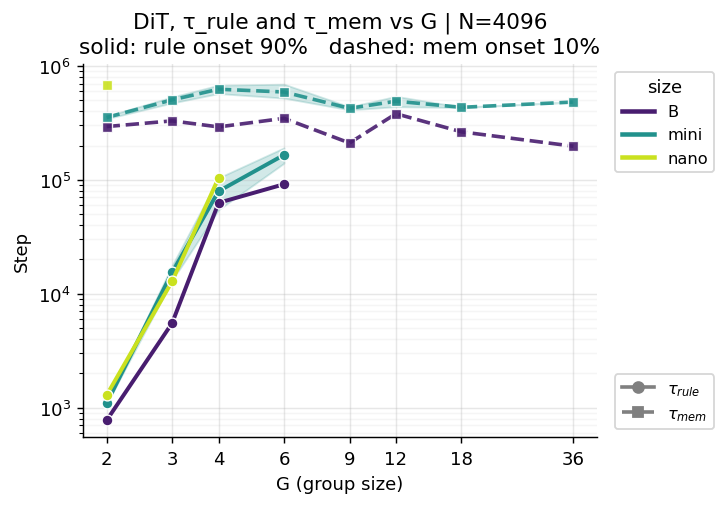

In [87]:
sub2 = df.query("model_arch == 'DiT' and N == 4096 and lr == 0.0001 and wd == 0.0")
fig, ax = plt.subplots(1, 1, figsize=(5.7, 4), dpi=130, sharey=True)
ax = plot_onset_vs_x(
    sub2,
    x='G', y_solid='rule_onset_acc90', y_dashed='mem_onset_stat',
    hue='model_size',          # color by size instead of G
    palette='viridis',
    xlabel='G (group size)',
    hue_title='size',
    title='DiT, τ_rule and τ_mem vs G | N=4096\n'
          'solid: rule onset 90%   dashed: mem onset 10%',
    ax=ax,
)
ax.set_ylim(550, 1050000)
plt.tight_layout(); 
saveallforms(FIGDIR, f"DiT_tau_rule_mem_vs_G_N4096_synopsis_rectwider", figh=fig)
plt.show()

### Exemplar traces 

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
sys.path.insert(0, "/n/home12/binxuwang/Github/DiffusionAttnConsistency")
import seaborn as sns
import numpy as np
from core.onset_lib import load_eval_timeseries, load_eval_dataframe

SAVEROOT = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"

ts = load_eval_timeseries("DiT_mini_parity_N4096_D36_G6_even", SAVEROOT)

# ts keys: eval_steps, valid_acc, mem_ratio, pergroup_acc, nan_ratio, bitgroup_mem
steps        = ts["eval_steps"]
valid_acc    = ts["valid_acc"]
mem_ratio    = ts["mem_ratio"]
pergroup_acc = ts["pergroup_acc"]   # NaN if not logged (CSV/GPT runs)
nan_ratio    = ts["nan_ratio_1e1"]      # NaN if not logged
bitgroup_mem = ts["bitgroup_mem"]   # NaN if not logged

print(f"Steps: {steps[0]} → {steps[-1]}  ({len(steps)} eval points)")
print(f"Final valid_acc:    {valid_acc[-1]:.3f}")
print(f"Final mem_ratio:    {mem_ratio[-1]:.3f}")
print(f"pergroup_acc avail: {not np.all(np.isnan(pergroup_acc))}")

Steps: 1 → 1000000  (1472 eval points)
Final valid_acc:    0.433
Final mem_ratio:    0.388
pergroup_acc avail: True


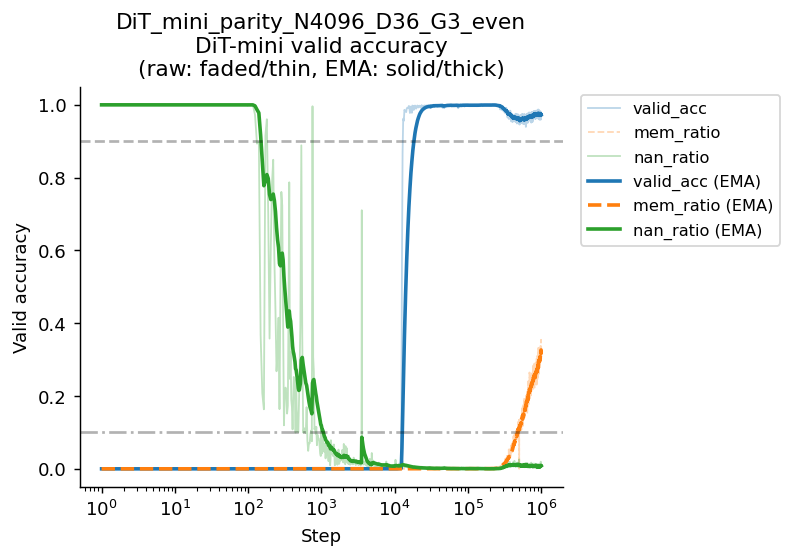

In [ ]:
expname = "DiT_mini_parity_N4096_D36_G3_even"
eval_traj_df = load_eval_dataframe(expname, SAVEROOT)

# Compute EMA for each plotted column for smoother trends
# ema_span = 5  # adjust for smoothness (larger=more smoothing)
dfa = eval_traj_df.copy()
for col in ["valid_acc", "mem_ratio", "nan_ratio_1e1"]:
    dfa[f"{col}_ema"] = dfa[col].ewm(alpha=0.1, adjust=False).mean() # span=ema_span

fig, ax = plt.subplots(1, 1, figsize=(4.8, 4), dpi=130, sharey=True)

# --- Original traces: thin, low alpha ---
sns.lineplot(data=eval_traj_df, x="step", y="valid_acc",   ax=ax, label="valid_acc",   color="C0", alpha=0.30, lw=1, zorder=1)
sns.lineplot(data=eval_traj_df, x="step", y="mem_ratio",   ax=ax, label="mem_ratio",   color="C1", alpha=0.30, lw=1, linestyle='--', zorder=1)
sns.lineplot(data=eval_traj_df, x="step", y="nan_ratio_1e1", ax=ax, label="nan_ratio", color="C2", alpha=0.30, lw=1, zorder=1)
# --- EMA traces: thicker, more opaque ---
sns.lineplot(data=dfa, x="step", y="valid_acc_ema",   ax=ax, label="valid_acc (EMA)",   color="C0", lw=2., zorder=2)
sns.lineplot(data=dfa, x="step", y="mem_ratio_ema",   ax=ax, label="mem_ratio (EMA)",   color="C1", lw=2., linestyle='--', zorder=2)
sns.lineplot(data=dfa, x="step", y="nan_ratio_1e1_ema", ax=ax, label="nan_ratio (EMA)", color="C2", lw=2., zorder=2)
# optionally add bitgroup_mem as another trace, following the above style
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=9, title_fontsize=10, frameon=True)
plt.axhline(y=0.1, color='black', linestyle='-.', alpha=0.3)
plt.axhline(y=0.9, color='black', linestyle='--', alpha=0.3)
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Step')
ax.set_ylabel('Valid accuracy')
ax.set_title(f'{expname}\nDiT-mini valid accuracy\n(raw: faded/thin, EMA: solid/thick)')
saveallforms(FIGDIR, f"{expname}_valid_mem_eval_curve_logscale", figh=fig)
plt.show()

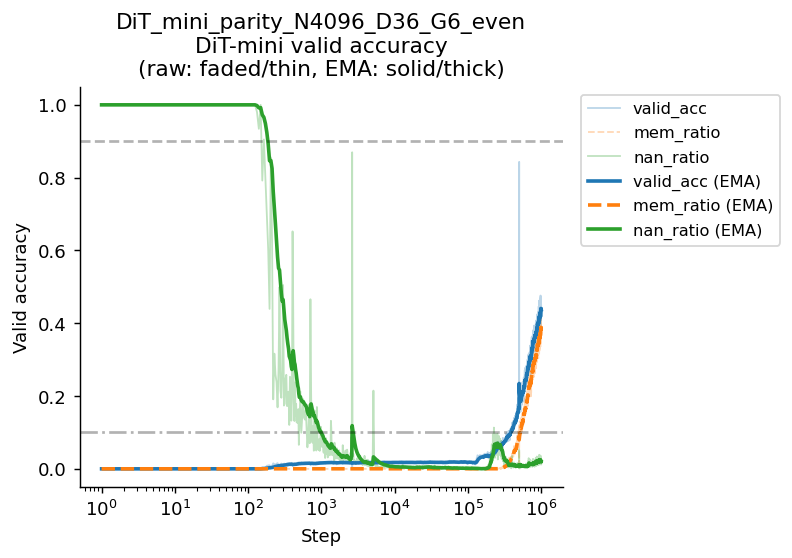

In [132]:
expname = "DiT_mini_parity_N4096_D36_G6_even"
eval_traj_df = load_eval_dataframe(expname, SAVEROOT)

# Compute EMA for each plotted column for smoother trends
# ema_span = 5  # adjust for smoothness (larger=more smoothing)
dfa = eval_traj_df.copy()
for col in ["valid_acc", "mem_ratio", "nan_ratio_1e1"]:
    dfa[f"{col}_ema"] = dfa[col].ewm(alpha=0.1, adjust=False).mean() # span=ema_span

fig, ax = plt.subplots(1, 1, figsize=(4.8, 4), dpi=130, sharey=True)

# --- Original traces: thin, low alpha ---
sns.lineplot(data=eval_traj_df, x="step", y="valid_acc",   ax=ax, label="valid_acc",   color="C0", alpha=0.30, lw=1, zorder=1)
sns.lineplot(data=eval_traj_df, x="step", y="mem_ratio",   ax=ax, label="mem_ratio",   color="C1", alpha=0.30, lw=1, linestyle='--', zorder=1)
sns.lineplot(data=eval_traj_df, x="step", y="nan_ratio_1e1", ax=ax, label="nan_ratio", color="C2", alpha=0.30, lw=1, zorder=1)
# --- EMA traces: thicker, more opaque ---
sns.lineplot(data=dfa, x="step", y="valid_acc_ema",   ax=ax, label="valid_acc (EMA)",   color="C0", lw=2., zorder=2)
sns.lineplot(data=dfa, x="step", y="mem_ratio_ema",   ax=ax, label="mem_ratio (EMA)",   color="C1", lw=2., linestyle='--', zorder=2)
sns.lineplot(data=dfa, x="step", y="nan_ratio_1e1_ema", ax=ax, label="nan_ratio (EMA)", color="C2", lw=2., zorder=2)
# optionally add bitgroup_mem as another trace, following the above style
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=9, title_fontsize=10, frameon=True)
plt.axhline(y=0.1, color='black', linestyle='-.', alpha=0.3)
plt.axhline(y=0.9, color='black', linestyle='--', alpha=0.3)
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Step')
ax.set_ylabel('Valid accuracy')
ax.set_title(f'{expname}\nDiT-mini valid accuracy\n(raw: faded/thin, EMA: solid/thick)')
saveallforms(FIGDIR, f"{expname}_valid_mem_eval_curve_logscale", figh=fig)
plt.show()

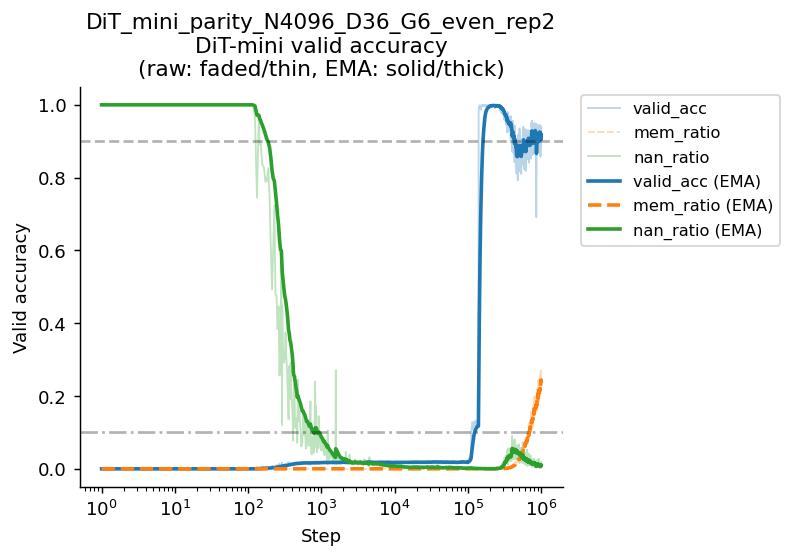

In [134]:
expname = "DiT_mini_parity_N4096_D36_G6_even_rep2"
eval_traj_df = load_eval_dataframe(expname, SAVEROOT)

# Compute EMA for each plotted column for smoother trends
# ema_span = 5  # adjust for smoothness (larger=more smoothing)
dfa = eval_traj_df.copy()
for col in ["valid_acc", "mem_ratio", "nan_ratio_1e1"]:
    dfa[f"{col}_ema"] = dfa[col].ewm(alpha=0.1, adjust=False).mean() # span=ema_span

fig, ax = plt.subplots(1, 1, figsize=(4.8, 4), dpi=130, sharey=True)

# --- Original traces: thin, low alpha ---
sns.lineplot(data=eval_traj_df, x="step", y="valid_acc",   ax=ax, label="valid_acc",   color="C0", alpha=0.30, lw=1, zorder=1)
sns.lineplot(data=eval_traj_df, x="step", y="mem_ratio",   ax=ax, label="mem_ratio",   color="C1", alpha=0.30, lw=1, linestyle='--', zorder=1)
sns.lineplot(data=eval_traj_df, x="step", y="nan_ratio_1e1", ax=ax, label="nan_ratio", color="C2", alpha=0.30, lw=1, zorder=1)
# --- EMA traces: thicker, more opaque ---
sns.lineplot(data=dfa, x="step", y="valid_acc_ema",   ax=ax, label="valid_acc (EMA)",   color="C0", lw=2., zorder=2)
sns.lineplot(data=dfa, x="step", y="mem_ratio_ema",   ax=ax, label="mem_ratio (EMA)",   color="C1", lw=2., linestyle='--', zorder=2)
sns.lineplot(data=dfa, x="step", y="nan_ratio_1e1_ema", ax=ax, label="nan_ratio (EMA)", color="C2", lw=2., zorder=2)
# optionally add bitgroup_mem as another trace, following the above style
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=9, title_fontsize=10, frameon=True)
plt.axhline(y=0.1, color='black', linestyle='-.', alpha=0.3)
plt.axhline(y=0.9, color='black', linestyle='--', alpha=0.3)
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Step')
ax.set_ylabel('Valid accuracy')
ax.set_title(f'{expname}\nDiT-mini valid accuracy\n(raw: faded/thin, EMA: solid/thick)')
saveallforms(FIGDIR, f"{expname}_valid_mem_eval_curve_logscale", figh=fig)
plt.show()

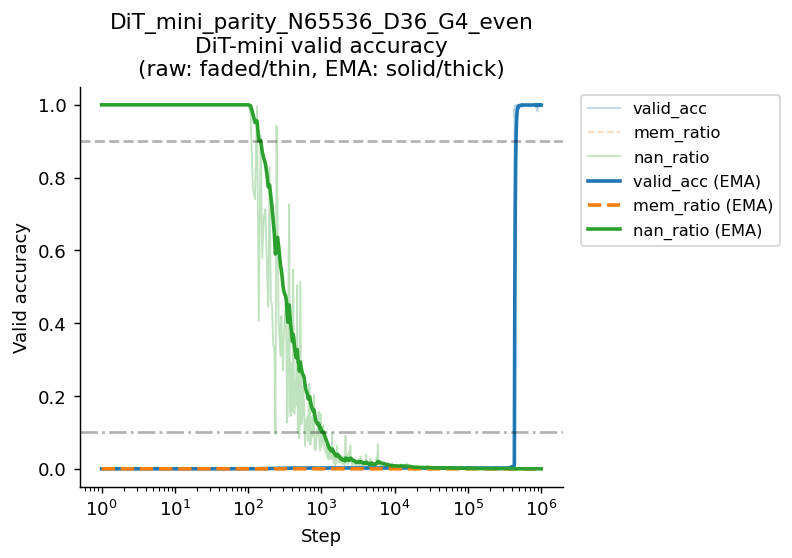

In [57]:
expname = "DiT_mini_parity_N65536_D36_G4_even"
eval_traj_df = load_eval_dataframe(expname, SAVEROOT)
# Compute EMA for each plotted column for smoother trends
# ema_span = 5  # adjust for smoothness (larger=more smoothing)
dfa = eval_traj_df.copy()
for col in ["valid_acc", "mem_ratio", "nan_ratio_1e1"]:
    dfa[f"{col}_ema"] = dfa[col].ewm(alpha=0.1, adjust=False).mean() # span=ema_span

fig, ax = plt.subplots(1, 1, figsize=(4.8, 4), dpi=130, sharey=True)

# --- Original traces: thin, low alpha ---
sns.lineplot(data=eval_traj_df, x="step", y="valid_acc",   ax=ax, label="valid_acc",   color="C0", alpha=0.30, lw=1, zorder=1)
sns.lineplot(data=eval_traj_df, x="step", y="mem_ratio",   ax=ax, label="mem_ratio",   color="C1", alpha=0.30, lw=1, linestyle='--', zorder=1)
sns.lineplot(data=eval_traj_df, x="step", y="nan_ratio_1e1", ax=ax, label="nan_ratio", color="C2", alpha=0.30, lw=1, zorder=1)
# --- EMA traces: thicker, more opaque ---
sns.lineplot(data=dfa, x="step", y="valid_acc_ema",   ax=ax, label="valid_acc (EMA)",   color="C0", lw=2., zorder=2)
sns.lineplot(data=dfa, x="step", y="mem_ratio_ema",   ax=ax, label="mem_ratio (EMA)",   color="C1", lw=2., linestyle='--', zorder=2)
sns.lineplot(data=dfa, x="step", y="nan_ratio_1e1_ema", ax=ax, label="nan_ratio (EMA)", color="C2", lw=2., zorder=2)
# optionally add bitgroup_mem as another trace, following the above style
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=9, title_fontsize=10, frameon=True)
plt.axhline(y=0.1, color='black', linestyle='-.', alpha=0.3)
plt.axhline(y=0.9, color='black', linestyle='--', alpha=0.3)
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Step')
ax.set_ylabel('Valid accuracy')
ax.set_title(f'{expname}\nDiT-mini valid accuracy\n(raw: faded/thin, EMA: solid/thick)')
saveallforms(FIGDIR, f"{expname}_valid_mem_eval_curve_logscale", figh=fig)
# plt.tight_layout(); 
plt.show()

### Exemplar trace collection

### G vs mem and rule learning 

In [89]:
df.query("model_arch == 'DiT' and model_size == 'mini' and lr == 0.0001 and wd == 0.0 and N==4096")

,exp_name,model_arch,model_size,G,N,D,n_layer,n_embd,n_head,lr,...,mem_onset_mem50,mem_onset_stat,stat_mem_thresh,innov_acc90_mem10,innov_acc90_mem20,innov_acc90_mem35,innov_acc90_mem50,innov_acc90_stat,model_str,rule_onset_acc90_innov
10,DiT_mini_parity_N4096_D36_G2_even,DiT,mini,2,4096,36,6,384,6,0.0001,...,677536.0,343712.0,0.115625,338540.0,404076.0,508524.0,676460.0,342636.0,DiT-mini,1076.0
11,DiT_mini_parity_N4096_D36_G2_even_rep2,DiT,mini,2,4096,36,6,384,6,0.0001,...,684704.0,362144.0,0.115625,355916.0,416332.0,526924.0,683596.0,361036.0,DiT-mini,1108.0
17,DiT_mini_parity_N4096_D36_G3_even,DiT,mini,3,4096,36,6,384,6,0.0001,...,NaN,472736.0,0.100244,459664.0,647056.0,NaN,NaN,459664.0,DiT-mini,13072.0
18,DiT_mini_parity_N4096_D36_G3_even_rep2,DiT,mini,3,4096,36,6,384,6,0.0001,...,NaN,534176.0,0.100244,516496.0,660880.0,867728.0,NaN,516496.0,DiT-mini,17680.0
24,DiT_mini_parity_N4096_D36_G4_even,DiT,mini,4,4096,36,6,384,6,0.0001,...,NaN,572064.0,0.100031,517456.0,688464.0,NaN,NaN,517456.0,DiT-mini,54608.0
25,DiT_mini_parity_N4096_D36_G4_even_rep2,DiT,mini,4,4096,36,6,384,6,0.0001,...,NaN,677536.0,0.100031,573440.0,734208.0,NaN,NaN,573440.0,DiT-mini,104096.0
33,DiT_mini_parity_N4096_D36_G6_even,DiT,mini,6,4096,36,6,384,6,0.0001,...,NaN,521888.0,0.100004,NaN,NaN,NaN,NaN,NaN,DiT-mini,NaN
34,DiT_mini_parity_N4096_D36_G6_even_lr1e4,DiT,mini,6,4096,36,6,384,6,0.0001,...,NaN,557728.0,0.100004,366592.0,539648.0,NaN,NaN,366592.0,DiT-mini,191136.0
35,DiT_mini_parity_N4096_D36_G6_even_rep2,DiT,mini,6,4096,36,6,384,6,0.0001,...,NaN,691872.0,0.100004,551936.0,765952.0,NaN,NaN,551936.0,DiT-mini,139936.0
50,DiT_mini_parity_N4096_D36_G9_even,DiT,mini,9,4096,36,6,384,6,0.0001,...,NaN,411296.0,0.100001,NaN,NaN,NaN,NaN,NaN,DiT-mini,NaN


In [135]:
import matplotlib.ticker as mticker
class SparseLogFormatter(mticker.LogFormatterSciNotation):
    def __call__(self, x, pos=None):
        exp = int(round(np.log10(x))) if x > 0 else None
        if exp is None or exp % 2 == 0:   # blank even exponents
            return ''
        return super().__call__(x, pos)


def beautify_log_xticks(ax):
    # Major ticks at every decade, labeled as 10^k
    ax.xaxis.set_major_locator(
        mticker.LogLocator(base=10, numticks=20)   # numticks high so none get culled
    )
    ax.xaxis.set_major_formatter(SparseLogFormatter(base=10))
    # ax.xaxis.set_major_formatter(mticker.LogFormatterSciNotation(base=10))
    # Minor ticks at 2,3,...,9 within each decade, no labels
    ax.xaxis.set_minor_locator(
        mticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=100)
    )
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    # Visible tick marks (matplotlib hides minor ticks by default on some styles)
    ax.tick_params(axis='x', which='major', length=5, width=1.0)
    ax.tick_params(axis='x', which='minor', length=3, width=0.6)

    # # Optional: faint minor gridlines
    # ax.grid(True, axis='x', which='major', alpha=0.3)
    # ax.grid(True, axis='x', which='minor', alpha=0.12)

In [ ]:
# Create hue values for different group sizes G
hue_vals = sorted(df["G"].unique())
cmap = plt.get_cmap("turbo")
samples = np.linspace(0.08, 0.92, len(hue_vals))
hue_palette = {h: cmap(s) for h, s in zip(hue_vals, samples)}

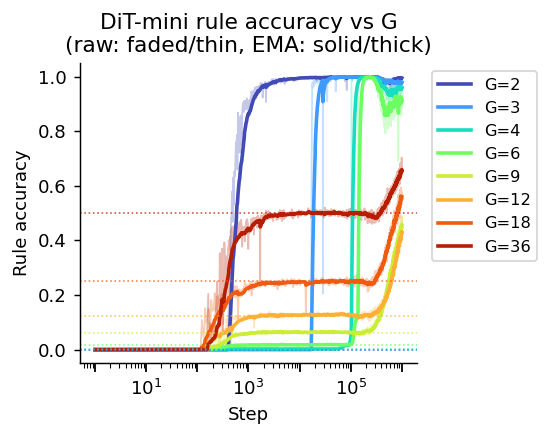

In [174]:
fig, ax = plt.subplots(1, 1, figsize=(3.35, 3), dpi=130, sharey=True)
for G in [2,3,4,6,9,12,18,36]:
    expname = f"DiT_mini_parity_N4096_D36_G{G}_even_rep2"
    eval_traj_df = load_eval_dataframe(expname, SAVEROOT)
    for col in ["valid_acc", ]: #  "mem_ratio","nan_ratio_1e1"
        eval_traj_df[f"{col}_ema"] = eval_traj_df[col].ewm(alpha=0.1, adjust=False).mean() # span=ema_span
    # --- Original traces: thin, low alpha ---
    sns.lineplot(data=eval_traj_df, x="step", y="valid_acc",   ax=ax, color=hue_palette[G], alpha=0.30, lw=1, zorder=1)#label=f"G={G}",   
    # sns.lineplot(data=eval_traj_df, x="step", y="mem_ratio",   ax=ax, label="mem_ratio",   color="C1", alpha=0.30, lw=1, linestyle='--', zorder=1)
    # sns.lineplot(data=eval_traj_df, x="step", y="nan_ratio_1e1", ax=ax, label="nan_ratio", color="C2", alpha=0.30, lw=1, zorder=1)
    # --- EMA traces: thicker, more opaque ---
    sns.lineplot(data=eval_traj_df, x="step", y="valid_acc_ema",   ax=ax, label=f"G={G}",   color=hue_palette[G], lw=2., zorder=2)
    # sns.lineplot(data=dfa, x="step", y="mem_ratio_ema",   ax=ax, label="mem_ratio (EMA)",   color="C1", lw=2., linestyle='--', zorder=2)
    # sns.lineplot(data=dfa, x="step", y="nan_ratio_1e1_ema", ax=ax, label="nan_ratio (EMA)", color="C2", lw=2., zorder=2)
for G in [2,3,4,6,9,12,18,36]:
    plt.axhline(y=(1/2)**(36//G), color=hue_palette[G], linestyle=':', alpha=0.75, lw=0.9)
# optionally add bitgroup_mem as another trace, following the above style
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=9, title_fontsize=10, frameon=True)
# plt.axhline(y=0.1, color='black', linestyle='-.', alpha=0.3)
# plt.axhline(y=0.9, color='black', linestyle='--', alpha=0.3)
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Step')
ax.set_ylabel('Rule accuracy')
ax.set_title(f'DiT-mini rule accuracy vs G\n(raw: faded/thin, EMA: solid/thick)')
ax.set_ylim([-0.05,1.05])
beautify_log_xticks(ax)
saveallforms(FIGDIR, f"DiT-mini_valid_acc_vs_G_sweep_rep2", figh=fig)
# plt.tight_layout(); 
plt.show()

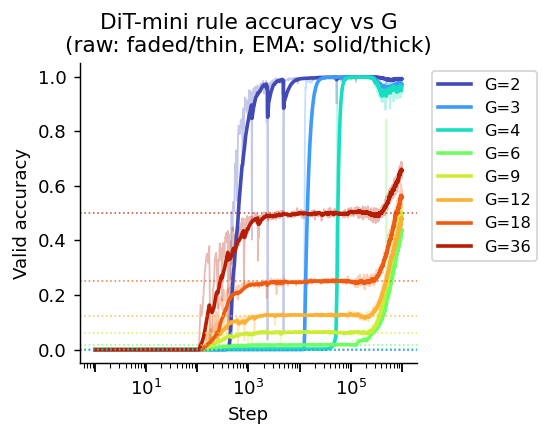

In [175]:

fig, ax = plt.subplots(1, 1, figsize=(3.35, 3), dpi=130, sharey=True)
for G in [2,3,4,6,9,12,18,36]:
    expname = f"DiT_mini_parity_N4096_D36_G{G}_even"
    eval_traj_df = load_eval_dataframe(expname, SAVEROOT)
    for col in ["valid_acc", ]: #  "mem_ratio","nan_ratio_1e1"
        eval_traj_df[f"{col}_ema"] = eval_traj_df[col].ewm(alpha=0.1, adjust=False).mean() # span=ema_span
    # --- Original traces: thin, low alpha ---
    sns.lineplot(data=eval_traj_df, x="step", y="valid_acc",   ax=ax, color=hue_palette[G], alpha=0.30, lw=1, zorder=1)# label=f"G={G}",   
    # sns.lineplot(data=eval_traj_df, x="step", y="mem_ratio",   ax=ax, label="mem_ratio",   color="C1", alpha=0.30, lw=1, linestyle='--', zorder=1)
    # sns.lineplot(data=eval_traj_df, x="step", y="nan_ratio_1e1", ax=ax, label="nan_ratio", color="C2", alpha=0.30, lw=1, zorder=1)
    # --- EMA traces: thicker, more opaque ---
    sns.lineplot(data=eval_traj_df, x="step", y="valid_acc_ema",   ax=ax, label=f"G={G}",   color=hue_palette[G], lw=2., zorder=2)
    # sns.lineplot(data=dfa, x="step", y="mem_ratio_ema",   ax=ax, label="mem_ratio (EMA)",   color="C1", lw=2., linestyle='--', zorder=2)
    # sns.lineplot(data=dfa, x="step", y="nan_ratio_1e1_ema", ax=ax, label="nan_ratio (EMA)", color="C2", lw=2., zorder=2)
for G in [2,3,4,6,9,12,18,36]:
    plt.axhline(y=(1/2)**(36//G), color=hue_palette[G], linestyle=':', alpha=0.75, lw=0.9)
# optionally add bitgroup_mem as another trace, following the above style
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=9, title_fontsize=10, frameon=True)
# plt.axhline(y=0.1, color='black', linestyle='-.', alpha=0.3)
# plt.axhline(y=0.9, color='black', linestyle='--', alpha=0.3)
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Step')
ax.set_ylabel('Valid accuracy')
ax.set_title(f'DiT-mini rule accuracy vs G\n(raw: faded/thin, EMA: solid/thick)')
ax.set_ylim([-0.05,1.05])
beautify_log_xticks(ax)
saveallforms(FIGDIR, f"DiT-mini_valid_acc_vs_G_sweep", figh=fig)
# plt.tight_layout(); 
plt.show()

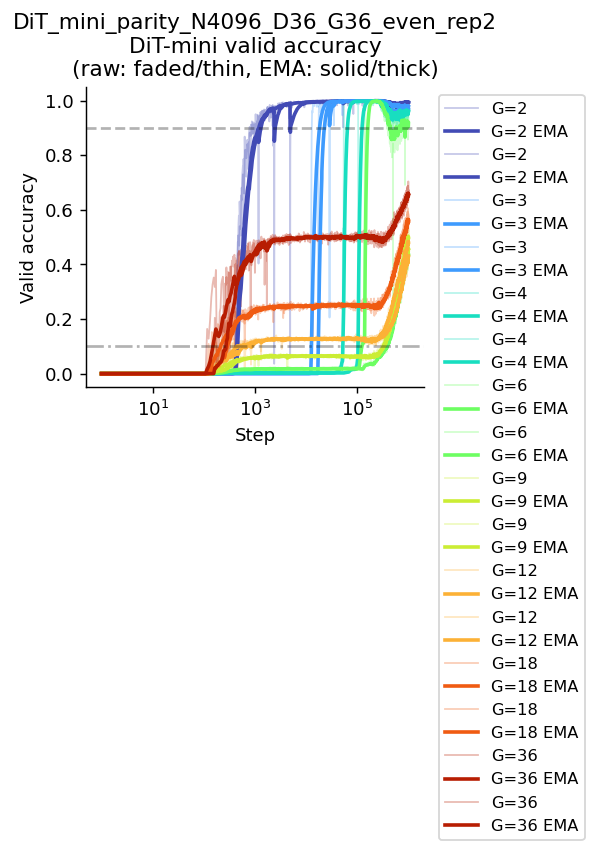

In [138]:

fig, ax = plt.subplots(1, 1, figsize=(3.35, 3), dpi=130, sharey=True)
for G in [2,3,4,6,9,12,18,36]:
    for suffix in ["", "_rep2"]:
        expname = f"DiT_mini_parity_N4096_D36_G{G}_even{suffix}"
        eval_traj_df = load_eval_dataframe(expname, SAVEROOT)
        for col in ["valid_acc", ]: #  "mem_ratio", "nan_ratio_1e1"
            eval_traj_df[f"{col}_ema"] = eval_traj_df[col].ewm(alpha=0.1, adjust=False).mean() # span=ema_span
        # --- Original traces: thin, low alpha ---
        sns.lineplot(data=eval_traj_df, x="step", y="valid_acc",   ax=ax, label=f"G={G}",   color=hue_palette[G], alpha=0.30, lw=1, zorder=1)
        # sns.lineplot(data=eval_traj_df, x="step", y="mem_ratio",   ax=ax, label="mem_ratio",   color="C1", alpha=0.30, lw=1, linestyle='--', zorder=1)
        # sns.lineplot(data=eval_traj_df, x="step", y="nan_ratio_1e1", ax=ax, label="nan_ratio", color="C2", alpha=0.30, lw=1, zorder=1)
        # --- EMA traces: thicker, more opaque ---
        sns.lineplot(data=eval_traj_df, x="step", y="valid_acc_ema",   ax=ax, label=f"G={G} EMA",   color=hue_palette[G], lw=2., zorder=2)
        # sns.lineplot(data=dfa, x="step", y="mem_ratio_ema",   ax=ax, label="mem_ratio (EMA)",   color="C1", lw=2., linestyle='--', zorder=2)
        # sns.lineplot(data=dfa, x="step", y="nan_ratio_1e1_ema", ax=ax, label="nan_ratio (EMA)", color="C2", lw=2., zorder=2)
# optionally add bitgroup_mem as another trace, following the above style
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=9, title_fontsize=10, frameon=True)
plt.axhline(y=0.1, color='black', linestyle='-.', alpha=0.3)
plt.axhline(y=0.9, color='black', linestyle='--', alpha=0.3)
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Step')
ax.set_ylabel('Valid accuracy')
ax.set_title(f'{expname}\nDiT-mini valid accuracy\n(raw: faded/thin, EMA: solid/thick)')
# saveallforms(FIGDIR, f"{expname}_valid_mem_eval_curve_logscale", figh=fig)
# plt.tight_layout(); 
plt.show()

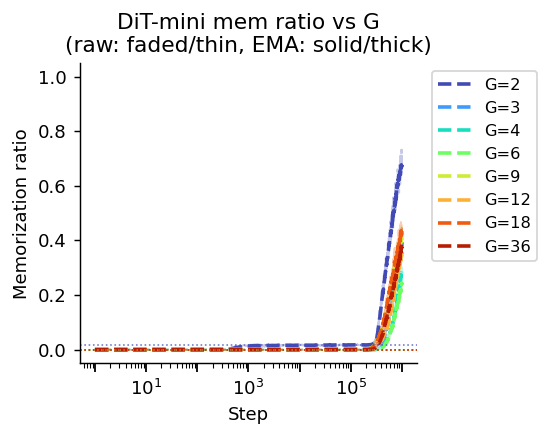

In [ ]:
N = 4096
fig, ax = plt.subplots(1, 1, figsize=(3.35, 3), dpi=130, sharey=True)
for G in [2,3,4,6,9,12,18,36]:
    expname = f"DiT_mini_parity_N{N}_D36_G{G}_even_rep2"
    eval_traj_df = load_eval_dataframe(expname, SAVEROOT)
    for col in ["mem_ratio",]: # "valid_acc", "nan_ratio_1e1"
        eval_traj_df[f"{col}_ema"] = eval_traj_df[col].ewm(alpha=0.1, adjust=False).mean() # span=ema_span
    # --- Original traces: thin, low alpha ---
    # sns.lineplot(data=eval_traj_df, x="step", y="valid_acc",   ax=ax, label=f"G={G}",   color=hue_palette[G], alpha=0.30, lw=1, zorder=1)
    sns.lineplot(data=eval_traj_df, x="step", y="mem_ratio",   ax=ax, color=hue_palette[G], alpha=0.30, lw=1, linestyle='--', zorder=1) # label=f"G={G}",   
    # sns.lineplot(data=eval_traj_df, x="step", y="nan_ratio_1e1", ax=ax, label="nan_ratio", color="C2", alpha=0.30, lw=1, zorder=1)
    # --- EMA traces: thicker, more opaque ---
    # sns.lineplot(data=eval_traj_df, x="step", y="valid_acc_ema",   ax=ax, label=f"G={G} EMA",   color=hue_palette[G], lw=2., zorder=2)
    sns.lineplot(data=eval_traj_df, x="step", y="mem_ratio_ema",   ax=ax, label=f"G={G}",   color=hue_palette[G], lw=2., linestyle='--', zorder=2)
    # sns.lineplot(data=eval_traj_df, x="step", y="nan_ratio_1e1_ema", ax=ax, label="nan_ratio (EMA)", color="C2", lw=2., zorder=2)
for G in [2,3,4,6,9,12,18,36]:
    plt.axhline(y=N / (2**(G-1))**(36//G), color=hue_palette[G], linestyle=':', alpha=0.75, lw=0.9)
# optionally add bitgroup_mem as another trace, following the above style
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=9, title_fontsize=10, frameon=True)
# plt.axhline(y=0.1, color='black', linestyle='-.', alpha=0.3)
# plt.axhline(y=0.9, color='black', linestyle='--', alpha=0.3)
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Step')
ax.set_ylabel('Memorization ratio')
ax.set_title(f'DiT-mini mem ratio vs G\n(raw: faded/thin, EMA: solid/thick)')
ax.set_ylim([-0.05,1.05])
beautify_log_xticks(ax)
saveallforms(FIGDIR, f"DiT-mini_mem_ratio_vs_G_sweep_rep2", figh=fig)
# saveallforms(FIGDIR, f"{expname}_valid_mem_eval_curve_logscale", figh=fig)
# plt.tight_layout(); 
plt.show()

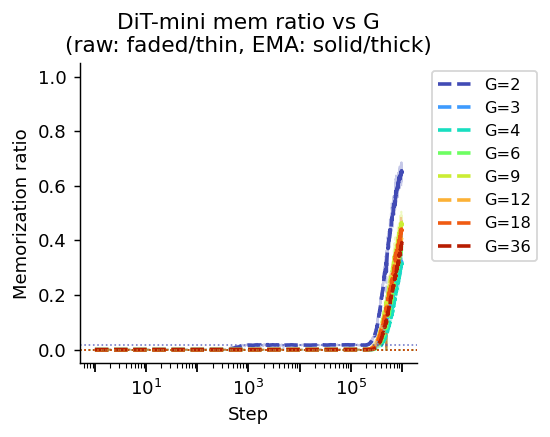

In [178]:
N = 4096
fig, ax = plt.subplots(1, 1, figsize=(3.35, 3), dpi=130, sharey=True)
for G in [2,3,4,6,9,12,18,36]:
    expname = f"DiT_mini_parity_N{N}_D36_G{G}_even"
    eval_traj_df = load_eval_dataframe(expname, SAVEROOT)
    for col in ["mem_ratio",]: #  "valid_acc","nan_ratio_1e1"
        eval_traj_df[f"{col}_ema"] = eval_traj_df[col].ewm(alpha=0.1, adjust=False).mean() # span=ema_span
    # --- Original traces: thin, low alpha ---
    # sns.lineplot(data=eval_traj_df, x="step", y="valid_acc",   ax=ax, label=f"G={G}",   color=hue_palette[G], alpha=0.30, lw=1, zorder=1)
    sns.lineplot(data=eval_traj_df, x="step", y="mem_ratio",   ax=ax, color=hue_palette[G], alpha=0.30, lw=1, linestyle='--', zorder=1) # label=f"G={G}",   
    # sns.lineplot(data=eval_traj_df, x="step", y="nan_ratio_1e1", ax=ax, label="nan_ratio", color="C2", alpha=0.30, lw=1, zorder=1)
    # --- EMA traces: thicker, more opaque ---
    # sns.lineplot(data=eval_traj_df, x="step", y="valid_acc_ema",   ax=ax, label=f"G={G} EMA",   color=hue_palette[G], lw=2., zorder=2)
    sns.lineplot(data=eval_traj_df, x="step", y="mem_ratio_ema",   ax=ax, label=f"G={G}",   color=hue_palette[G], lw=2., linestyle='--', zorder=2)
    # sns.lineplot(data=eval_traj_df, x="step", y="nan_ratio_1e1_ema", ax=ax, label="nan_ratio (EMA)", color="C2", lw=2., zorder=2)
for G in [2,3,4,6,9,12,18,36]:
    plt.axhline(y=N / (2**(G-1))**(36//G), color=hue_palette[G], linestyle=':', alpha=0.75, lw=0.9)
# optionally add bitgroup_mem as another trace, following the above style
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=9, title_fontsize=10, frameon=True)
# plt.axhline(y=0.1, color='black', linestyle='-.', alpha=0.3)
# plt.axhline(y=0.9, color='black', linestyle='--', alpha=0.3)
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Step')
ax.set_ylabel('Memorization ratio')
ax.set_title(f'DiT-mini mem ratio vs G\n(raw: faded/thin, EMA: solid/thick)')
ax.set_ylim([-0.05,1.05])
beautify_log_xticks(ax)
saveallforms(FIGDIR, f"DiT-mini_mem_ratio_vs_G_sweep", figh=fig)
# saveallforms(FIGDIR, f"{expname}_valid_mem_eval_curve_logscale", figh=fig)
# plt.tight_layout(); 
plt.show()

### rule learning vs N sweep



In [118]:
df.query("model_arch == 'DiT'  and lr == 0.0001 and wd == 0.0 and G == 3")

,exp_name,model_arch,model_size,G,N,D,n_layer,n_embd,n_head,lr,...,mem_onset_mem50,mem_onset_stat,stat_mem_thresh,innov_acc90_mem10,innov_acc90_mem20,innov_acc90_mem35,innov_acc90_mem50,innov_acc90_stat,model_str,rule_onset_acc90_innov
1,DiT_B_parity_N4096_D36_G3_even,DiT,B,3,4096,36,12,768,12,0.0001,...,492192.0,329376.0,0.100244,323864.0,352536.0,403736.0,486680.0,323864.0,DiT-B,5512.0
15,DiT_mini_parity_N1024_D36_G3_even,DiT,mini,3,1024,36,6,384,6,0.0001,...,289440.0,104096.0,0.100061,94744.0,113176.0,165400.0,280088.0,94744.0,DiT-mini,9352.0
16,DiT_mini_parity_N2048_D36_G3_even,DiT,mini,3,2048,36,6,384,6,0.0001,...,571040.0,212640.0,0.100122,196752.0,257168.0,370832.0,560272.0,201872.0,DiT-mini,10768.0
17,DiT_mini_parity_N4096_D36_G3_even,DiT,mini,3,4096,36,6,384,6,0.0001,...,NaN,472736.0,0.100244,459664.0,647056.0,NaN,NaN,459664.0,DiT-mini,13072.0
18,DiT_mini_parity_N4096_D36_G3_even_rep2,DiT,mini,3,4096,36,6,384,6,0.0001,...,NaN,534176.0,0.100244,516496.0,660880.0,867728.0,NaN,516496.0,DiT-mini,17680.0
19,DiT_mini_parity_N8192_D36_G3_even,DiT,mini,3,8192,36,6,384,6,0.0001,...,NaN,NaN,0.100488,NaN,NaN,NaN,NaN,NaN,DiT-mini,10768.0
20,DiT_mini_parity_N16384_D36_G3_even,DiT,mini,3,16384,36,6,384,6,0.0001,...,NaN,NaN,0.100977,NaN,NaN,NaN,NaN,NaN,DiT-mini,13328.0
21,DiT_mini_parity_N65536_D36_G3_even,DiT,mini,3,65536,36,6,384,6,0.0001,...,NaN,NaN,0.103906,NaN,NaN,NaN,NaN,NaN,DiT-mini,11024.0
77,DiT_nano_parity_N4096_D36_G3_even,DiT,nano,3,4096,36,3,384,6,0.0001,...,NaN,NaN,0.100244,NaN,NaN,NaN,NaN,NaN,DiT-nano,12816.0


In [119]:
df.query("model_arch == 'DiT'  and lr == 0.0001 and wd == 0.0 and G == 3").N.unique()

array([ 4096,  1024,  2048,  8192, 16384, 65536])

In [160]:
# Create hue values for different group sizes G
hue_vals = sorted(df.query("model_arch == 'DiT'  and lr == 0.0001 and wd == 0.0 and G == 3").N.unique())
cmap = plt.get_cmap("magma") # magma
samples = np.linspace(0.08, 0.92, len(hue_vals))
hue_N_palette = {h: cmap(s) for h, s in zip(hue_vals, samples)}

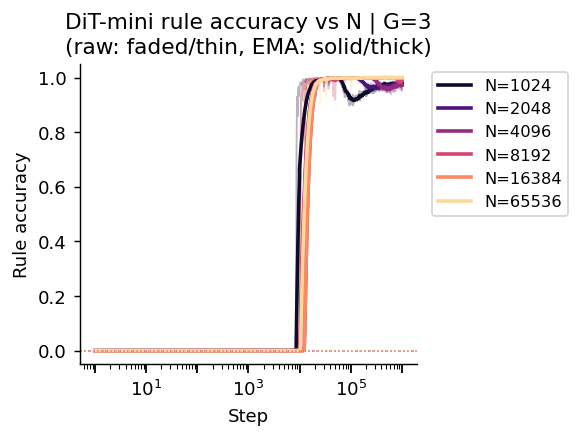

In [183]:
G = 3
fig, ax = plt.subplots(1, 1, figsize=(3.35, 3), dpi=130, sharey=True)
for N in [1024,  2048,  4096,  8192, 16384, 65536]:
    expname = f"DiT_mini_parity_N{N}_D36_G{G}_even"
    eval_traj_df = load_eval_dataframe(expname, SAVEROOT)
    for col in ["valid_acc", ]: #  "mem_ratio","nan_ratio_1e1"
        eval_traj_df[f"{col}_ema"] = eval_traj_df[col].ewm(alpha=0.1, adjust=False).mean() # span=ema_span
    # --- Original traces: thin, low alpha ---
    sns.lineplot(data=eval_traj_df, x="step", y="valid_acc",   ax=ax, color=hue_N_palette[N], alpha=0.30, lw=1, zorder=1)#label=f"G={G}",   
    # sns.lineplot(data=eval_traj_df, x="step", y="mem_ratio",   ax=ax, label="mem_ratio",   color="C1", alpha=0.30, lw=1, linestyle='--', zorder=1)
    # sns.lineplot(data=eval_traj_df, x="step", y="nan_ratio_1e1", ax=ax, label="nan_ratio", color="C2", alpha=0.30, lw=1, zorder=1)
    # --- EMA traces: thicker, more opaque ---
    sns.lineplot(data=eval_traj_df, x="step", y="valid_acc_ema",   ax=ax, label=f"N={N}",   color=hue_N_palette[N], lw=2., zorder=2)
    # sns.lineplot(data=dfa, x="step", y="mem_ratio_ema",   ax=ax, label="mem_ratio (EMA)",   color="C1", lw=2., linestyle='--', zorder=2)
    # sns.lineplot(data=dfa, x="step", y="nan_ratio_1e1_ema", ax=ax, label="nan_ratio (EMA)", color="C2", lw=2., zorder=2)
for N in [1024,  2048,  4096,  8192, 16384, 65536]:
    plt.axhline(y=(1/2)**(36//G), color=hue_N_palette[N], linestyle=':', alpha=0.75, lw=0.9)
# optionally add bitgroup_mem as another trace, following the above style
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=9, title_fontsize=10, frameon=True)
# plt.axhline(y=0.1, color='black', linestyle='-.', alpha=0.3)
# plt.axhline(y=0.9, color='black', linestyle='--', alpha=0.3)
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Step')
ax.set_ylabel('Rule accuracy')
ax.set_title(f'DiT-mini rule accuracy vs N | G={G}\n(raw: faded/thin, EMA: solid/thick)')
ax.set_ylim([-0.05,1.05])
beautify_log_xticks(ax)
saveallforms(FIGDIR, f"DiT-mini_valid_acc_vs_N_sweep_G{G}", figh=fig)
# plt.tight_layout(); 
plt.show()

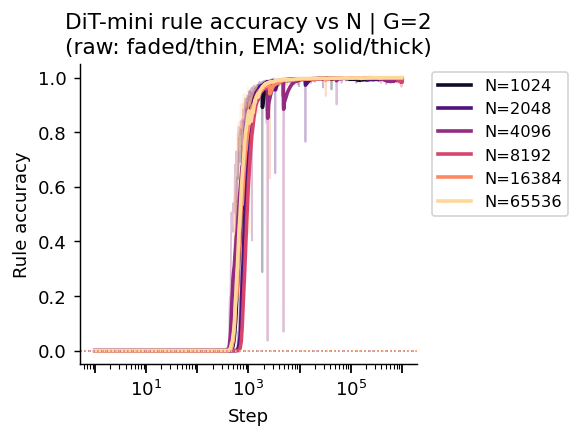

In [187]:
G = 2
fig, ax = plt.subplots(1, 1, figsize=(3.35, 3), dpi=130, sharey=True)
for N in [1024,  2048,  4096,  8192, 16384, 65536]:
    expname = f"DiT_mini_parity_N{N}_D36_G{G}_even"
    eval_traj_df = load_eval_dataframe(expname, SAVEROOT)
    for col in ["valid_acc", ]: #  "mem_ratio","nan_ratio_1e1"
        eval_traj_df[f"{col}_ema"] = eval_traj_df[col].ewm(alpha=0.1, adjust=False).mean() # span=ema_span
    # --- Original traces: thin, low alpha ---
    sns.lineplot(data=eval_traj_df, x="step", y="valid_acc",   ax=ax, color=hue_N_palette[N], alpha=0.30, lw=1, zorder=1)#label=f"G={G}",   
    # sns.lineplot(data=eval_traj_df, x="step", y="mem_ratio",   ax=ax, label="mem_ratio",   color="C1", alpha=0.30, lw=1, linestyle='--', zorder=1)
    # sns.lineplot(data=eval_traj_df, x="step", y="nan_ratio_1e1", ax=ax, label="nan_ratio", color="C2", alpha=0.30, lw=1, zorder=1)
    # --- EMA traces: thicker, more opaque ---
    sns.lineplot(data=eval_traj_df, x="step", y="valid_acc_ema",   ax=ax, label=f"N={N}",   color=hue_N_palette[N], lw=2., zorder=2)
    # sns.lineplot(data=dfa, x="step", y="mem_ratio_ema",   ax=ax, label="mem_ratio (EMA)",   color="C1", lw=2., linestyle='--', zorder=2)
    # sns.lineplot(data=dfa, x="step", y="nan_ratio_1e1_ema", ax=ax, label="nan_ratio (EMA)", color="C2", lw=2., zorder=2)
for N in [1024,  2048,  4096,  8192, 16384, 65536]:
    plt.axhline(y=(1/2)**(36//G), color=hue_N_palette[N], linestyle=':', alpha=0.75, lw=0.9)
# optionally add bitgroup_mem as another trace, following the above style
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=9, title_fontsize=10, frameon=True)
# plt.axhline(y=0.1, color='black', linestyle='-.', alpha=0.3)
# plt.axhline(y=0.9, color='black', linestyle='--', alpha=0.3)
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Step')
ax.set_ylabel('Rule accuracy')
ax.set_title(f'DiT-mini rule accuracy vs N | G={G}\n(raw: faded/thin, EMA: solid/thick)')
ax.set_ylim([-0.05,1.05])
beautify_log_xticks(ax)
saveallforms(FIGDIR, f"DiT-mini_valid_acc_vs_N_sweep_G{G}", figh=fig)
# plt.tight_layout(); 
plt.show()

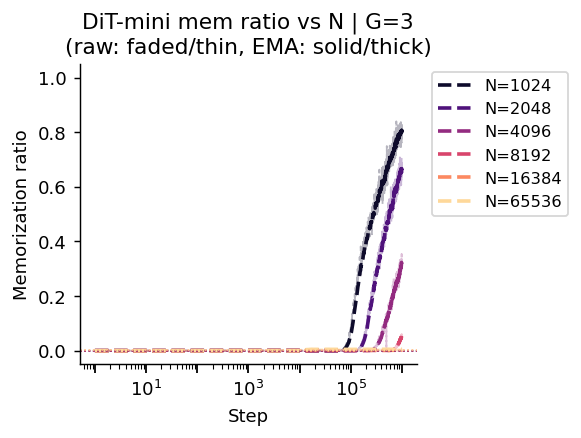

In [184]:
G = 3
fig, ax = plt.subplots(1, 1, figsize=(3.35, 3), dpi=130, sharey=True)
for N in [1024,  2048,  4096,  8192, 16384, 65536]:
    expname = f"DiT_mini_parity_N{N}_D36_G{G}_even"
    eval_traj_df = load_eval_dataframe(expname, SAVEROOT)
    for col in ["mem_ratio", ]: #  "nan_ratio_1e1"
        eval_traj_df[f"{col}_ema"] = eval_traj_df[col].ewm(alpha=0.1, adjust=False).mean() # span=ema_span
    # --- Original traces: thin, low alpha ---
    # sns.lineplot(data=eval_traj_df, x="step", y="valid_acc",   ax=ax, color=hue_N_palette[N], alpha=0.30, lw=1, zorder=1)#label=f"G={G}",   
    sns.lineplot(data=eval_traj_df, x="step", y="mem_ratio",   ax=ax, color=hue_N_palette[N], alpha=0.30, lw=1, linestyle='--', zorder=1)# label="mem_ratio",   
    # sns.lineplot(data=eval_traj_df, x="step", y="nan_ratio_1e1", ax=ax, label="nan_ratio", color="C2", alpha=0.30, lw=1, zorder=1)
    # --- EMA traces: thicker, more opaque ---
    # sns.lineplot(data=eval_traj_df, x="step", y="valid_acc_ema",   ax=ax, label=f"N={N}",   color=hue_N_palette[N], lw=2., zorder=2)
    sns.lineplot(data=eval_traj_df, x="step", y="mem_ratio_ema",   ax=ax, label=f"N={N}",   color=hue_N_palette[N], lw=2., linestyle='--', zorder=2)
    # sns.lineplot(data=dfa, x="step", y="nan_ratio_1e1_ema", ax=ax, label="nan_ratio (EMA)", color="C2", lw=2., zorder=2)
for N in [1024,  2048,  4096,  8192, 16384, 65536]:
    plt.axhline(y=N / (2**(G-1))**(36//G), color=hue_N_palette[N], linestyle=':', alpha=0.75, lw=0.9)
# optionally add bitgroup_mem as another trace, following the above style
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=9, title_fontsize=10, frameon=True)
# plt.axhline(y=0.1, color='black', linestyle='-.', alpha=0.3)
# plt.axhline(y=0.9, color='black', linestyle='--', alpha=0.3)
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Step')
ax.set_ylabel('Memorization ratio')
ax.set_title(f'DiT-mini mem ratio vs N | G={G}\n(raw: faded/thin, EMA: solid/thick)')
ax.set_ylim([-0.05,1.05])
beautify_log_xticks(ax)
saveallforms(FIGDIR, f"DiT-mini_mem_ratio_vs_N_sweep_G{G}", figh=fig)
# plt.tight_layout(); 
plt.show()

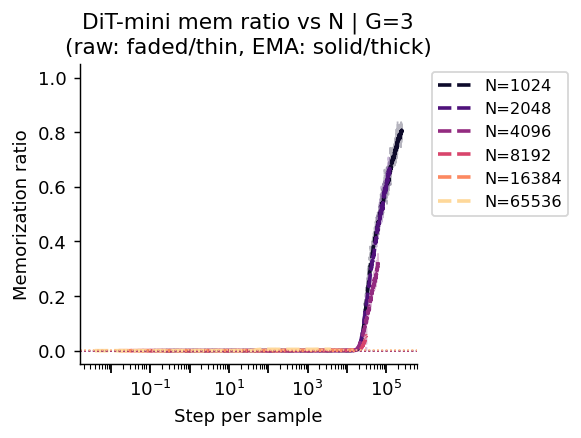

In [185]:
G = 3
batch_size = 256
fig, ax = plt.subplots(1, 1, figsize=(3.35, 3), dpi=130, sharey=True)
for N in [1024,  2048,  4096,  8192, 16384, 65536]:
    expname = f"DiT_mini_parity_N{N}_D36_G{G}_even"
    eval_traj_df = load_eval_dataframe(expname, SAVEROOT)
    for col in ["mem_ratio", ]: #  "nan_ratio_1e1"
        eval_traj_df[f"{col}_ema"] = eval_traj_df[col].ewm(alpha=0.1, adjust=False).mean() # span=ema_span
    eval_traj_df["step_per_sample"] = eval_traj_df["step"] * batch_size / N 
    # --- Original traces: thin, low alpha ---
    # sns.lineplot(data=eval_traj_df, x="step", y="valid_acc",   ax=ax, color=hue_N_palette[N], alpha=0.30, lw=1, zorder=1)#label=f"G={G}",   
    sns.lineplot(data=eval_traj_df, x="step_per_sample", y="mem_ratio",   ax=ax, color=hue_N_palette[N], alpha=0.30, lw=1, linestyle='--', zorder=1)# label="mem_ratio",   
    # sns.lineplot(data=eval_traj_df, x="step", y="nan_ratio_1e1", ax=ax, label="nan_ratio", color="C2", alpha=0.30, lw=1, zorder=1)
    # --- EMA traces: thicker, more opaque ---
    # sns.lineplot(data=eval_traj_df, x="step", y="valid_acc_ema",   ax=ax, label=f"N={N}",   color=hue_N_palette[N], lw=2., zorder=2)
    sns.lineplot(data=eval_traj_df, x="step_per_sample", y="mem_ratio_ema",   ax=ax, label=f"N={N}",   color=hue_N_palette[N], lw=2., linestyle='--', zorder=2)
    # sns.lineplot(data=dfa, x="step", y="nan_ratio_1e1_ema", ax=ax, label="nan_ratio (EMA)", color="C2", lw=2., zorder=2)
for N in [1024,  2048,  4096,  8192, 16384, 65536]:
    plt.axhline(y=N / (2**(G-1))**(36//G), color=hue_N_palette[N], linestyle=':', alpha=0.75, lw=0.9)
# optionally add bitgroup_mem as another trace, following the above style
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=9, title_fontsize=10, frameon=True)
# plt.axhline(y=0.1, color='black', linestyle='-.', alpha=0.3)
# plt.axhline(y=0.9, color='black', linestyle='--', alpha=0.3)
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Step per sample')
ax.set_ylabel('Memorization ratio')
ax.set_title(f'DiT-mini mem ratio vs N | G={G}\n(raw: faded/thin, EMA: solid/thick)')
ax.set_ylim([-0.05,1.05])
beautify_log_xticks(ax)
saveallforms(FIGDIR, f"DiT-mini_mem_ratio_vs_N_sweep_G{G}_step_per_sample", figh=fig)
# plt.tight_layout(); 
plt.show()

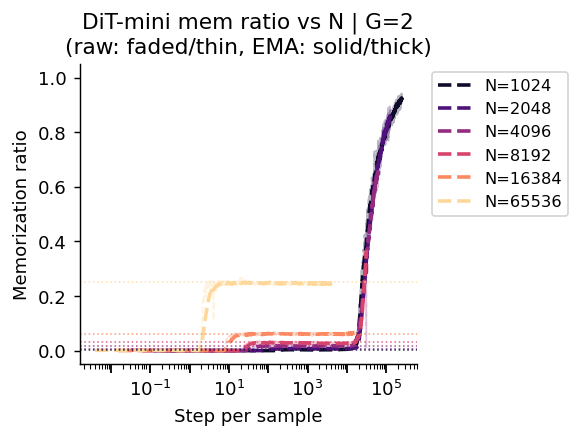

In [186]:
G = 2
batch_size = 256
fig, ax = plt.subplots(1, 1, figsize=(3.35, 3), dpi=130, sharey=True)
for N in [1024,  2048,  4096,  8192, 16384, 65536]:
    expname = f"DiT_mini_parity_N{N}_D36_G{G}_even"
    eval_traj_df = load_eval_dataframe(expname, SAVEROOT)
    for col in ["mem_ratio", ]: #  "nan_ratio_1e1"
        eval_traj_df[f"{col}_ema"] = eval_traj_df[col].ewm(alpha=0.1, adjust=False).mean() # span=ema_span
    eval_traj_df["step_per_sample"] = eval_traj_df["step"] * batch_size / N 
    # --- Original traces: thin, low alpha ---
    # sns.lineplot(data=eval_traj_df, x="step", y="valid_acc",   ax=ax, color=hue_N_palette[N], alpha=0.30, lw=1, zorder=1)#label=f"G={G}",   
    sns.lineplot(data=eval_traj_df, x="step_per_sample", y="mem_ratio",   ax=ax, color=hue_N_palette[N], alpha=0.30, lw=1, linestyle='--', zorder=1)# label="mem_ratio",   
    # sns.lineplot(data=eval_traj_df, x="step", y="nan_ratio_1e1", ax=ax, label="nan_ratio", color="C2", alpha=0.30, lw=1, zorder=1)
    # --- EMA traces: thicker, more opaque ---
    # sns.lineplot(data=eval_traj_df, x="step", y="valid_acc_ema",   ax=ax, label=f"N={N}",   color=hue_N_palette[N], lw=2., zorder=2)
    sns.lineplot(data=eval_traj_df, x="step_per_sample", y="mem_ratio_ema",   ax=ax, label=f"N={N}",   color=hue_N_palette[N], lw=2., linestyle='--', zorder=2)
    # sns.lineplot(data=dfa, x="step", y="nan_ratio_1e1_ema", ax=ax, label="nan_ratio (EMA)", color="C2", lw=2., zorder=2)
for N in [1024,  2048,  4096,  8192, 16384, 65536]:
    plt.axhline(y=N / (2**(G-1))**(36//G), color=hue_N_palette[N], linestyle=':', alpha=0.75, lw=0.9)
# optionally add bitgroup_mem as another trace, following the above style
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=9, title_fontsize=10, frameon=True)
# plt.axhline(y=0.1, color='black', linestyle='-.', alpha=0.3)
# plt.axhline(y=0.9, color='black', linestyle='--', alpha=0.3)
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Step per sample')
ax.set_ylabel('Memorization ratio')
ax.set_title(f'DiT-mini mem ratio vs N | G={G}\n(raw: faded/thin, EMA: solid/thick)')
ax.set_ylim([-0.05,1.05])
beautify_log_xticks(ax)
saveallforms(FIGDIR, f"DiT-mini_mem_ratio_vs_N_sweep_G{G}_step_per_sample", figh=fig)
# plt.tight_layout(); 
plt.show()

## Older unpolished versions

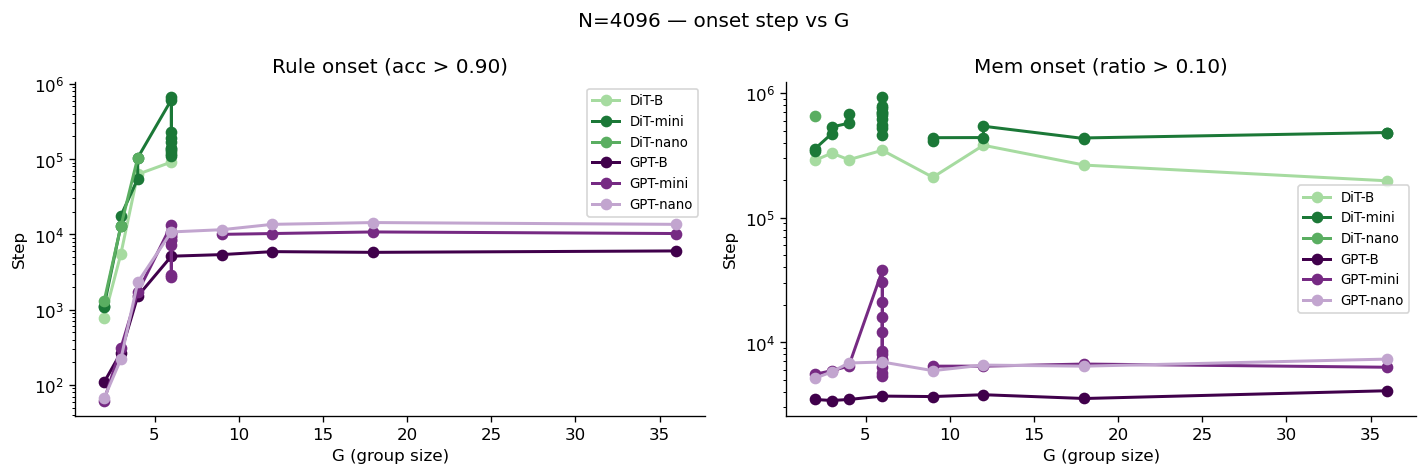

In [ ]:
# ── Rule onset vs G, by arch/size ─────────────────────────────────────────
COLORS = {
    ('DiT', 'mini'): '#1b7837',
    ('DiT', 'B'):    '#a6dba0',
    ('GPT', 'mini'): '#762a83',
    ('GPT', 'nano'): '#c2a5cf',
    ('GPT', 'B'):    '#40004b',
    ('DiT', 'nano'): '#5aae61',
}

sub = df[df['N'] == 4096].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=120)

for (arch, size), grp in sub.groupby(['model_arch', 'model_size']):
    grp = grp.sort_values('G')
    col = COLORS.get((arch, size), 'gray')
    label = f"{arch}-{size}"
    axes[0].plot(grp['G'], grp['rule_onset_acc90'], 'o-', color=col, lw=1.8, label=label)
    axes[1].plot(grp['G'], grp['mem_onset_mem10'],  'o-', color=col, lw=1.8, label=label)

for ax, title in [(axes[0], 'Rule onset (acc > 0.90)'), (axes[1], 'Mem onset (ratio > 0.10)')]:
    ax.set_yscale('log')
    ax.set_xlabel('G (group size)')
    ax.set_ylabel('Step')
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle('N=4096 — onset step vs G', fontsize=12)
plt.tight_layout()
plt.show()

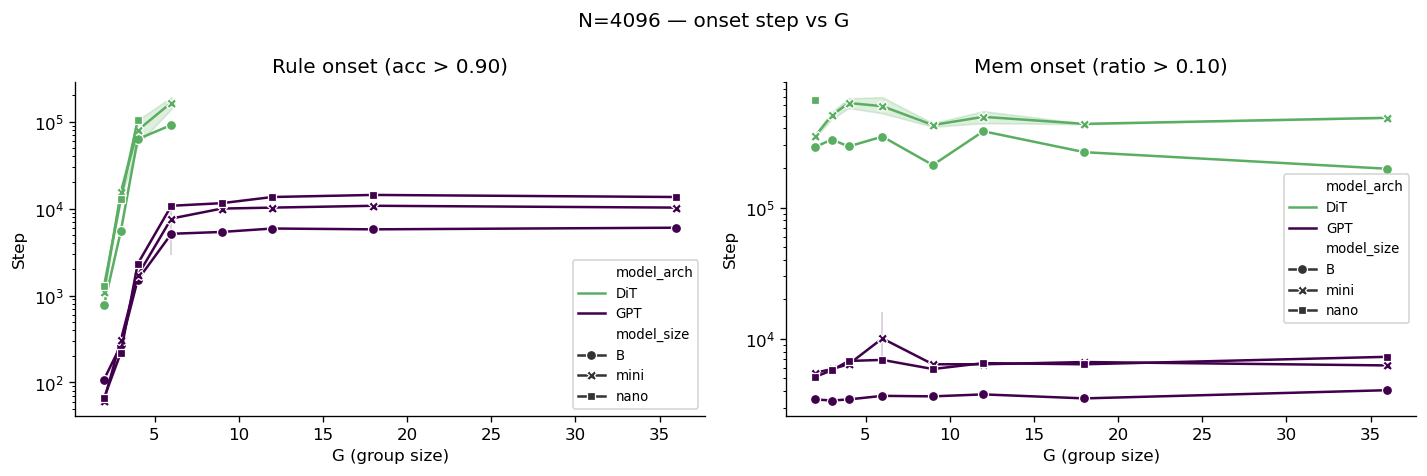

In [ ]:
# ── Rule onset vs G, by arch/size ─────────────────────────────────────────
COLORS = {
    ('DiT', 'nano'): '#5aae61',
    ('DiT', 'mini'): '#1b7837',
    ('DiT', 'B'):    '#a6dba0',
    ('GPT', 'nano'): '#c2a5cf',
    ('GPT', 'mini'): '#762a83',
    ('GPT', 'B'):    '#40004b',
}

sub = df.query("N == 4096 and lr == 0.0001").copy()
sub = pd.concat([sub.query("model_arch == 'DiT' and wd == 0.00"), sub.query("model_arch == 'GPT' and wd == 0.01")], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=120)

import seaborn as sns

for i, (ycol, title) in enumerate([('rule_onset_acc90', 'Rule onset (acc > 0.90)'),
                                   ('mem_onset_mem10',  'Mem onset (ratio > 0.10)')]):
    sns.lineplot(
        data=sub, 
        x='G', y=ycol, 
        hue='model_arch', style='model_size', 
        markers=True, dashes=False, ax=axes[i],
        palette={arch: COLORS.get((arch, size), 'gray') for (arch, size) in COLORS}
    )

for ax, title in [(axes[0], 'Rule onset (acc > 0.90)'), (axes[1], 'Mem onset (ratio > 0.10)')]:
    ax.set_yscale('log')
    ax.set_xlabel('G (group size)')
    ax.set_ylabel('Step')
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle('N=4096 — onset step vs G', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
sub

,exp_name,model_arch,model_size,G,N,D,n_layer,n_embd,n_head,lr,...,mem_onset_mem35,mem_onset_mem50,mem_onset_stat,stat_mem_thresh,innov_acc90_mem10,innov_acc90_mem20,innov_acc90_mem35,innov_acc90_mem50,innov_acc90_stat,model_str
0,DiT_B_parity_N4096_D36_G2_even,DiT,B,2,4096,36,12,768,12,0.0001,...,370336.0,444064.0,293536.0,0.115625,287644.0,317340.0,369564.0,443292.0,292764.0,DiT-B
1,DiT_B_parity_N4096_D36_G3_even,DiT,B,3,4096,36,12,768,12,0.0001,...,409248.0,492192.0,329376.0,0.100244,323864.0,352536.0,403736.0,486680.0,323864.0,DiT-B
2,DiT_B_parity_N4096_D36_G4_even,DiT,B,4,4096,36,12,768,12,0.0001,...,468640.0,629408.0,291488.0,0.100031,228688.0,282960.0,405840.0,566608.0,228688.0,DiT-B
3,DiT_B_parity_N4096_D36_G6_even,DiT,B,6,4096,36,12,768,12,0.0001,...,536224.0,706208.0,346784.0,0.100004,255312.0,331088.0,444752.0,614736.0,255312.0,DiT-B
4,DiT_B_parity_N4096_D36_G9_even,DiT,B,9,4096,36,12,768,12,0.0001,...,327328.0,430752.0,210592.0,0.100001,NaN,NaN,NaN,NaN,NaN,DiT-B
5,DiT_B_parity_N4096_D36_G12_even,DiT,B,12,4096,36,12,768,12,0.0001,...,469664.0,574112.0,380576.0,0.100000,NaN,NaN,NaN,NaN,NaN,DiT-B
6,DiT_B_parity_N4096_D36_G18_even,DiT,B,18,4096,36,12,768,12,0.0001,...,344736.0,412320.0,263840.0,0.100000,NaN,NaN,NaN,NaN,NaN,DiT-B
7,DiT_B_parity_N4096_D36_G36_even,DiT,B,36,4096,36,12,768,12,0.0001,...,303776.0,413344.0,197280.0,0.100000,NaN,NaN,NaN,NaN,NaN,DiT-B
8,DiT_mini_parity_N4096_D36_G2_even,DiT,mini,2,4096,36,6,384,6,0.0001,...,509600.0,677536.0,343712.0,0.115625,338540.0,404076.0,508524.0,676460.0,342636.0,DiT-mini
9,DiT_mini_parity_N4096_D36_G2_even_rep2,DiT,mini,2,4096,36,6,384,6,0.0001,...,528032.0,684704.0,362144.0,0.115625,355916.0,416332.0,526924.0,683596.0,361036.0,DiT-mini


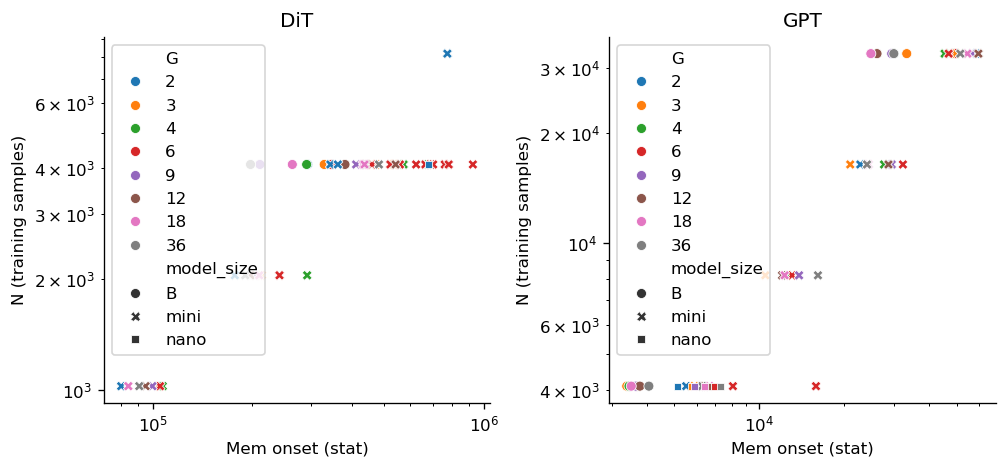

In [31]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(8.5, 4), dpi=120)
plt.sca(axes[0])
sns.scatterplot(data=df.query('model_arch == "DiT" '), 
                x='mem_onset_stat', 
                y='N', hue='G', style="model_size",
                palette="tab10", ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Mem onset (stat)')
axes[0].set_ylabel('N (training samples)')
axes[0].set_title('DiT')
sns.scatterplot(data=df.query('model_arch == "GPT" and lr == 0.0001 and wd == 0.01'), 
                x='mem_onset_stat', 
                y='N', hue='G', style="model_size",
                palette="tab10", ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Mem onset (stat)')
axes[1].set_ylabel('N (training samples)')
axes[1].set_title('GPT')
plt.tight_layout()
fig.show()

### Memorization time kind of invariant to G

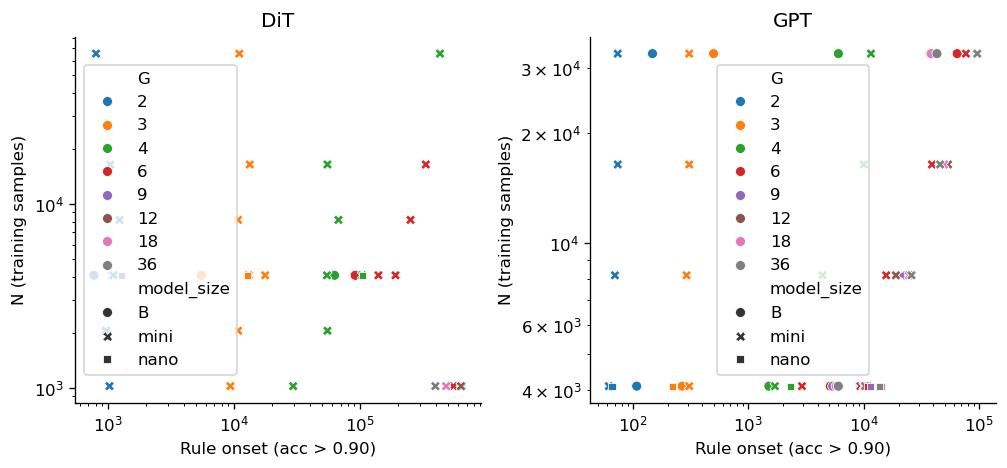

In [32]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(8.5, 4), dpi=120)
plt.sca(axes[0])
sns.scatterplot(data=df.query('model_arch == "DiT" and lr == 0.0001 and wd == 0.00'), 
                x='rule_onset_acc90', 
                y='N', hue='G', style="model_size",
                palette="tab10", ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Rule onset (acc > 0.90)')
axes[0].set_ylabel('N (training samples)')
axes[0].set_title('DiT')
sns.scatterplot(data=df.query('model_arch == "GPT" and lr == 0.0001 and wd == 0.01'), 
                x='rule_onset_acc90', 
                y='N', hue='G', style="model_size",
                palette="tab10", ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Rule onset (acc > 0.90)')
axes[1].set_ylabel('N (training samples)')
axes[1].set_title('GPT')
plt.tight_layout()
fig.show()

### DiT vs GPT on memorization time 

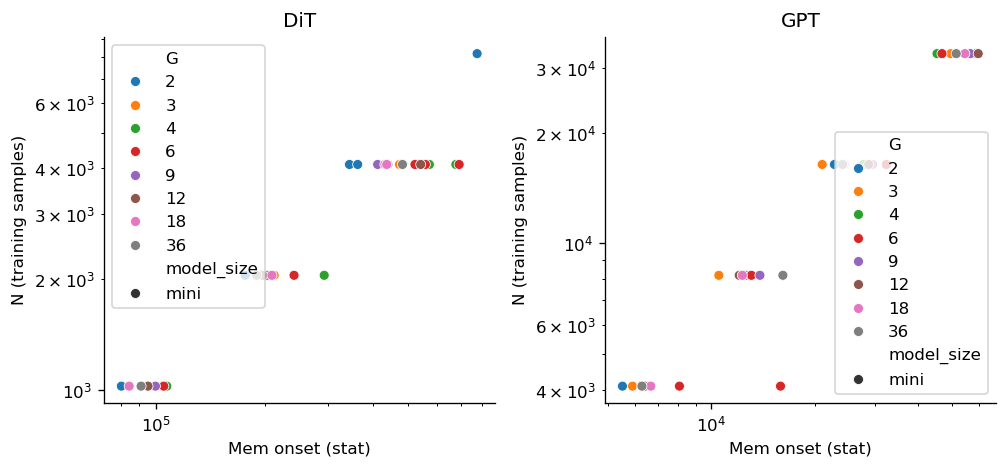

In [33]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(8.5, 4), dpi=120)
plt.sca(axes[0])
sns.scatterplot(data=df.query('model_arch == "DiT" and lr == 0.0001 and wd == 0.00 and model_size == "mini"'), 
                x='mem_onset_stat', 
                y='N', hue='G', style="model_size",
                palette="tab10", ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Mem onset (stat)')
axes[0].set_ylabel('N (training samples)')
axes[0].set_title('DiT')
sns.scatterplot(data=df.query('model_arch == "GPT" and lr == 0.0001 and wd == 0.01 and model_size == "mini"'), 
                x='mem_onset_stat', 
                y='N', hue='G', style="model_size",
                palette="tab10", ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Mem onset (stat)')
axes[1].set_ylabel('N (training samples)')
axes[1].set_title('GPT')
plt.tight_layout()
fig.show()

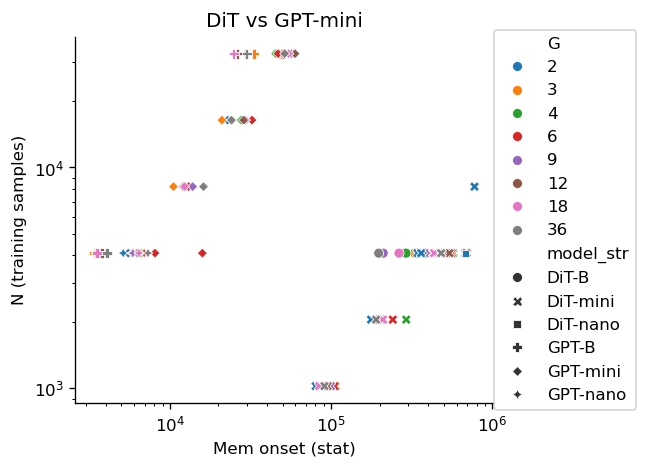

In [53]:
import numpy as np
import seaborn as sns
fig, axes = plt.subplots(1, 1, figsize=(5.5, 4), dpi=120)
plt.sca(axes)
df_cmb = pd.concat([
    df.query('model_arch == "DiT" and lr == 0.0001 and wd == 0.00 '), 
    df.query('model_arch == "GPT" and lr == 0.0001 and wd == 0.01 '), 
    ], ignore_index=True)
scatter = sns.scatterplot(data=df_cmb, 
                x='mem_onset_stat', 
                y='N', hue='G', style="model_str",
                palette="tab10", ax=axes)
axes.set_xscale('log')
axes.set_yscale('log')
axes.set_xlabel('Mem onset (stat)')
axes.set_ylabel('N (training samples)')
axes.set_title('DiT vs GPT-mini')
# Move the legend to outside right
axes.legend(loc='center left', bbox_to_anchor=(1, 0.5), borderaxespad=0.)
plt.tight_layout()
fig.show()

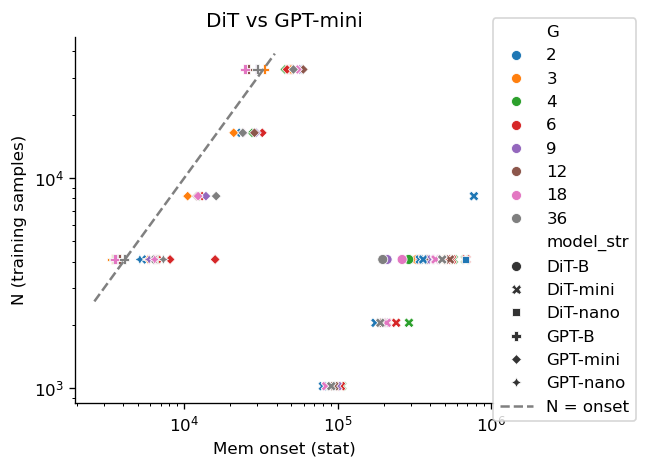

In [ ]:
import numpy as np
import seaborn as sns
fig, axes = plt.subplots(1, 1, figsize=(5.5, 4), dpi=120)
plt.sca(axes)
df_cmb = pd.concat([
    df.query('model_arch == "DiT" and lr == 0.0001 and wd == 0.00 '), 
    df.query('model_arch == "GPT" and lr == 0.0001 and wd == 0.01 '), 
    ], ignore_index=True)
scatter = sns.scatterplot(data=df_cmb, 
                x='mem_onset_stat', 
                y='N', hue='G', style="model_str",
                palette="tab10", ax=axes)
axes.set_xscale('log')
axes.set_yscale('log')
axes.set_xlabel('Mem onset (stat)')
axes.set_ylabel('N (training samples)')
axes.set_title('DiT vs GPT-mini')
# Add a 1-1 line (N = mem_onset_stat)
xmin, xmax = axes.get_xlim()
ymin, ymax = axes.get_ylim()
lmin = max(np.log10(xmin), np.log10(ymin))
lmax = min(np.log10(xmax), np.log10(ymax))
llim = np.linspace(lmin, lmax, 100)
axes.plot(10**llim, 10**llim, color='gray', ls='--', label='N = onset')
# Move the legend to outside right
axes.legend(loc='center left', bbox_to_anchor=(1, 0.5), borderaxespad=0.)
plt.tight_layout()
fig.show()

In [57]:
%load_ext autoreload
%autoreload 2


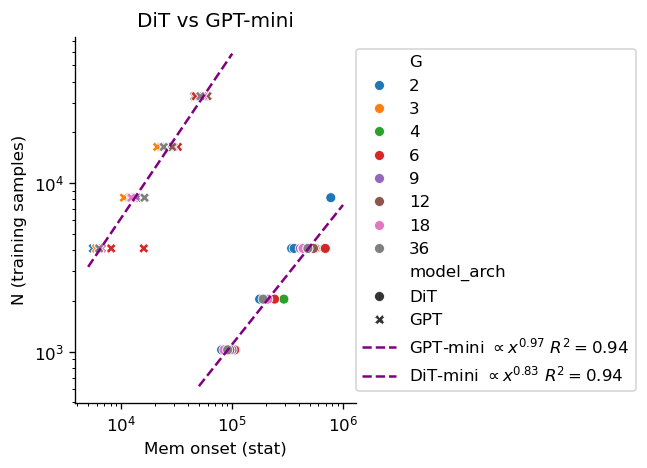

In [65]:
import seaborn as sns
fig, axes = plt.subplots(1, 1, figsize=(5.5, 4), dpi=120)
plt.sca(axes)
df_cmb = pd.concat([
    df.query('model_arch == "DiT" and lr == 0.0001 and wd == 0.00 and model_size == "mini"'), 
    df.query('model_arch == "GPT" and lr == 0.0001 and wd == 0.01 and model_size == "mini"'), 
    ], ignore_index=True)
scatter = sns.scatterplot(data=df_cmb, 
                x='mem_onset_stat', 
                y='N', hue='G', style="model_arch",
                palette="tab10", ax=axes)
axes.set_xscale('log')
axes.set_yscale('log')
axes.set_xlabel('Mem onset (stat)')
axes.set_ylabel('N (training samples)')
axes.set_title('DiT vs GPT-mini')
from core.fit_lib import fit_loglog, plot_loglog_fit
df_part = df.query('model_arch == "GPT" and lr == 0.0001 and wd == 0.01 and model_size == "mini"') 
# fit only
slope, intercept, r2, fn = fit_loglog(df_part['mem_onset_stat'], df_part['N'])
# a = exp(intercept), so: y ≈ exp(intercept) * x^slope
# fit + plot overlay in one call
slope, intercept, r2 = plot_loglog_fit(axes, df_part['mem_onset_stat'], df_part['N'],
    x_min=5e3, x_max=1e5,   # optional: restrict fit range
    label="GPT-mini", show_slope=True, show_r2=True,
    color="purple", ls="--")

df_part = df.query('model_arch == "DiT" and lr == 0.0001 and wd == 0.00 and model_size == "mini"') 
# fit only
slope, intercept, r2, fn = fit_loglog(df_part['mem_onset_stat'], df_part['N'])
# a = exp(intercept), so: y ≈ exp(intercept) * x^slope
# fit + plot overlay in one call
slope, intercept, r2 = plot_loglog_fit(axes, df_part['mem_onset_stat'], df_part['N'],
    x_min=5e4, x_max=1e6,   # optional: restrict fit range
    label="DiT-mini", show_slope=True, show_r2=True,
    color="purple", ls="--")

# Move the legend to outside right
axes.legend(loc='center left', bbox_to_anchor=(1, 0.5), borderaxespad=0.)
plt.tight_layout()
fig.show()

In [55]:
from core.fit_lib import fit_loglog, plot_loglog_fit
df_part = df.query('model_arch == "DiT" and lr == 0.0001 and wd == 0.00 and model_size == "mini"') 
    # df.query('model_arch == "GPT" and lr == 0.0001 and wd == 0.01 and model_size == "mini"'), 
    
# fit only
slope, intercept, r2, fn = fit_loglog(df_part['mem_onset_stat'], df_part['N'])
# a = exp(intercept), so: y ≈ exp(intercept) * x^slope

# fit + plot overlay in one call
slope, intercept, r2 = plot_loglog_fit(ax, df_part['mem_onset_stat'], df_part['N'],
    x_min=1e3, x_max=1e5,   # optional: restrict fit range
    label="DiT-mini", show_slope=True, show_r2=True,
    color="purple", ls="--")
print(f"DiT-mini: slope = {slope:.2f}, intercept = {intercept:.2f}, r2 = {r2:.2f}")

DiT-mini: slope = -0.00, intercept = 6.93, r2 = nan


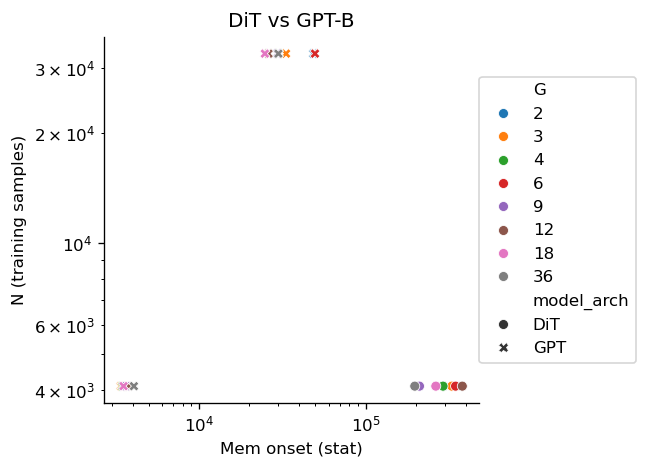

In [49]:
import seaborn as sns
fig, axes = plt.subplots(1, 1, figsize=(5.5, 4), dpi=120)
plt.sca(axes)
df_cmb = pd.concat([
    df.query('model_arch == "DiT" and lr == 0.0001 and wd == 0.00 and model_size == "B"'), 
    df.query('model_arch == "GPT" and lr == 0.0001 and wd == 0.01 and model_size == "B"'), 
    ], ignore_index=True)
scatter = sns.scatterplot(data=df_cmb, 
                x='mem_onset_stat', 
                y='N', hue='G', style="model_arch",
                palette="tab10", ax=axes)
axes.set_xscale('log')
axes.set_yscale('log')
axes.set_xlabel('Mem onset (stat)')
axes.set_ylabel('N (training samples)')
axes.set_title('DiT vs GPT-B')
# Move the legend to outside right
axes.legend(loc='center left', bbox_to_anchor=(1, 0.5), borderaxespad=0.)
plt.tight_layout()
fig.show()

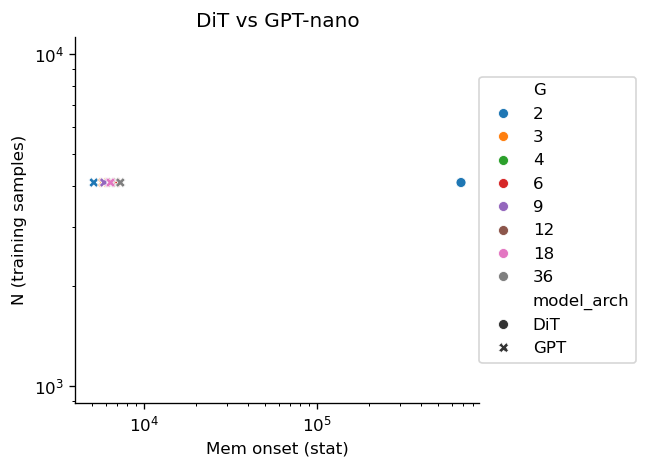

In [48]:
import seaborn as sns
fig, axes = plt.subplots(1, 1, figsize=(5.5, 4), dpi=120)
plt.sca(axes)
df_cmb = pd.concat([
    df.query('model_arch == "DiT" and lr == 0.0001 and wd == 0.00 and model_size == "nano"'), 
    df.query('model_arch == "GPT" and lr == 0.0001 and wd == 0.01 and model_size == "nano"'), 
    ], ignore_index=True)
scatter = sns.scatterplot(data=df_cmb, 
                x='mem_onset_stat', 
                y='N', hue='G', style="model_arch",
                palette="tab10", ax=axes)
axes.set_xscale('log')
axes.set_yscale('log')
axes.set_xlabel('Mem onset (stat)')
axes.set_ylabel('N (training samples)')
axes.set_title('DiT vs GPT-nano')
# Move the legend to outside right
axes.legend(loc='center left', bbox_to_anchor=(1, 0.5), borderaxespad=0.)
plt.tight_layout()
fig.show()

In [ ]:
# ── Innovation window vs G (N=4096, acc90 / mem10) ────────────────────────
fig, ax = plt.subplots(figsize=(7, 4), dpi=120)

for (arch, size), grp in sub.groupby(['model_arch', 'model_size']):
    grp = grp.sort_values('G')
    col = COLORS.get((arch, size), 'gray')
    ax.plot(grp['G'], grp['innov_acc90_mem10'], 'o-', color=col, lw=1.8, label=f"{arch}-{size}")

ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('G (group size)')
ax.set_ylabel('Innovation window (steps)\nmem_onset − rule_onset')
ax.set_title('Innovation window vs G  (N=4096, acc90/mem10)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

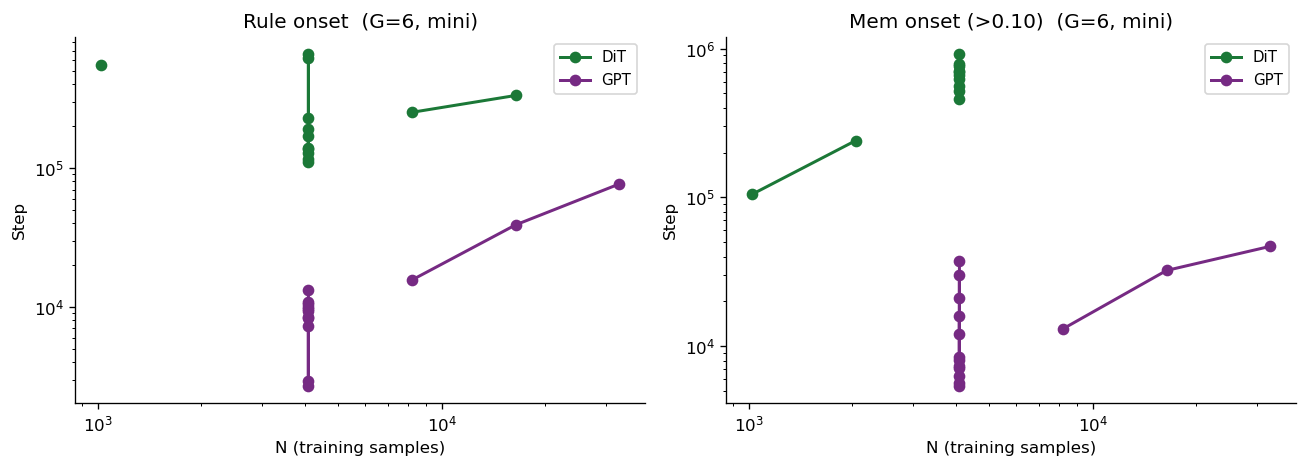

In [6]:
# ── Rule onset vs N for fixed G, DiT-mini vs GPT-mini ─────────────────────
G_FOCUS = 6
sub_g = df[(df['G'] == G_FOCUS) & (df['model_size'] == 'mini')].copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=120)

for arch, grp in sub_g.groupby('model_arch'):
    grp = grp.sort_values('N')
    col = COLORS.get((arch, 'mini'), 'gray')
    axes[0].plot(grp['N'], grp['rule_onset_acc90'], 'o-', color=col, lw=1.8, label=arch)
    axes[1].plot(grp['N'], grp['mem_onset_mem10'],  'o-', color=col, lw=1.8, label=arch)

for ax, title in [(axes[0], 'Rule onset'), (axes[1], 'Mem onset (>0.10)')]:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('N (training samples)')
    ax.set_ylabel('Step')
    ax.set_title(f"{title}  (G={G_FOCUS}, mini)")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# ── Raw table view: filter / inspect ──────────────────────────────────────
cols = ['exp_name', 'model_arch', 'model_size', 'G', 'N',
        'lr', 'wd', 'support_size', 'stat_mem_frac',
        'rule_onset_acc90', 'mem_onset_mem10', 'mem_onset_stat', 'innov_acc90_mem10']
df[cols].query("model_size == 'mini' and N == 4096").sort_values(['model_arch','G'])